# Implementació de models i explicabilitat XAI

En aquest notebook s’entrenen i s’avaluen diferents models supervisats per a la detecció de frau en reclamacions d’assegurances. El punt de partida és el dataset final obtingut després d’un procés previ de neteja, exploració i selecció de variables, en què s’han tractat valors absents, variables redundants, variables d’alta cardinalitat i possibles patrons problemàtics.

L’objectiu principal és comparar el comportament de models interpretables, utilitzats com a baseline, amb models més flexibles però menys transparents. Com a models baseline s’entrenen una regressió logística i un arbre de decisió, mentre que com a models més complexos o black-box s’utilitzen Random Forest, XGBoost, MLP i SVC amb kernel RBF.

Com que el problema se centra en la detecció de frau, l’avaluació dels models no es pot basar únicament en mètriques globals com l’accuracy o el ROC-AUC. En aquest context, la classe positiva correspon als casos fraudulents, i el cost de no detectar un frau pot ser més elevat que el cost de marcar com a sospitós un cas que finalment no ho és. Per aquest motiu, al llarg del notebook es dona una importància especial al recall, a la precision, al F1-score i a l’Average Precision, a més del ROC-AUC.

Finalment, els models black-box amb millor rendiment s’analitzen mitjançant tècniques d’explicabilitat, principalment SHAP i Anchors. Aquest pas és essencial per aportar transparència al procés de decisió dels models, identificar quines variables influeixen més en les prediccions i valorar si les explicacions generades són estables i coherents. D’aquesta manera, el treball no només compara el rendiment predictiu dels models, sinó també la seva capacitat de ser explicats en un escenari sensible com la detecció de frau.

## 0. Importació de llibreries i càrrega del dataset

En aquest primer apartat es carreguen les llibreries necessàries per al preprocessament, l’entrenament i l’avaluació dels models de classificació. També s’importa el dataset final generat en el notebook previ de neteja i selecció de variables.

En aquesta fase ja no es prenen noves decisions de neteja sobre les dades. El notebook parteix del conjunt de dades preparat i se centra en separar la variable objectiu dels predictors, transformar les variables categòriques, entrenar els diferents models i comparar-ne el rendiment.

El dataset conté variables numèriques i categòriques relacionades amb les característiques del client, la pòlissa, el vehicle i el sinistre. La variable objectiu és fraud_binary, codificada de la manera següent:

- 0: reclamació no fraudulenta
- 1: reclamació fraudulenta

Es tracta, per tant, d’un problema de classificació binària. A més, la classe de frau és minoritària, fet que s’haurà de tenir en compte durant l’avaluació dels models, ja que una bona accuracy no garanteix necessàriament una bona capacitat per detectar casos fraudulents.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Preprocessament i partició
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models baseline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Mètriques
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# Importar el dataset net

from google.colab import files
uploaded = files.upload()

df_model = pd.read_csv("insurance_claims_clean.csv")

display(df_model.head())
df_model.info()


Saving insurance_claims_clean.csv to insurance_claims_clean.csv


,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,auto_make,auto_year,fraud_binary,policy_age_days,incident_month,incident_dayofweek,incident_is_weekend,policy_bind_year,is_premium,vehicle_type
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,...,Saab,2004,1,100,1,6,1,2014,0,Sports
1,228,42,IN,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,...,Mercedes,2007,1,3130,1,2,0,2006,1,Sedan
2,134,29,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,...,Dodge,2007,0,5282,2,6,1,2000,0,Pickup
3,256,41,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,...,Chevrolet,2014,1,8996,1,5,1,1990,0,SUV
4,228,44,IL,500/1000,1000,1583.91,6000000,MALE,Associate,sales,...,Accura,2009,0,256,2,1,0,2014,0,Sports


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_state                 1000 non-null   object 
 3   policy_csl                   1000 non-null   object 
 4   policy_deductable            1000 non-null   int64  
 5   policy_annual_premium        1000 non-null   float64
 6   umbrella_limit               1000 non-null   int64  
 7   insured_sex                  1000 non-null   object 
 8   insured_education_level      1000 non-null   object 
 9   insured_occupation           1000 non-null   object 
 10  insured_relationship         1000 non-null   object 
 11  capital-gains                1000 non-null   int64  
 12  capital-loss                 1000 non-null   int64  
 13  incident_type      

## 1. Separació de variable objectiu i predictors

En aquest apartat se separa la variable objectiu fraud_binary de la resta de variables del dataset. La variable objectiu indica si una reclamació és fraudulenta o no, mentre que la resta de columnes s’utilitzen com a predictors del model.

També s’identifiquen les variables categòriques i numèriques. Aquesta distinció és necessària perquè les variables categòriques hauran de ser transformades posteriorment a format numèric mitjançant one-hot encoding, mentre que les variables numèriques ja poden ser utilitzades directament pels models, o bé escalades en aquells algoritmes que ho requereixin.

In [3]:
# Separar variable objectiu i predictors
y = df_model["fraud_binary"]
X = df_model.drop(columns=["fraud_binary"])

# Identificar tipus de variables
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

print("\nDistribució de la variable objectiu:")
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

print("\nVariables categòriques:")
print(categorical_cols)

print("\nVariables numèriques:")
print(numerical_cols)

print("\nNombre de variables categòriques:", len(categorical_cols))
print("Nombre de variables numèriques:", len(numerical_cols))

Shape de X: (1000, 37)
Shape de y: (1000,)

Distribució de la variable objectiu:
fraud_binary
0    753
1    247
Name: count, dtype: int64
fraud_binary
0    75.3
1    24.7
Name: proportion, dtype: float64

Variables categòriques:
['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'vehicle_type']

Variables numèriques:
['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', 'policy_age_days', 'incident_month', 'incident_dayofweek', 'incident_is_weekend', 'policy_bind_year', 'is_premium']

Nombre de variables categòriques: 16
No

La distribució de la variable objectiu mostra que aproximadament una quarta part de les observacions corresponen a casos de frau. Aquest desbalanceig és rellevant, ja que en problemes de detecció de frau és habitual que la classe positiva sigui menys freqüent, però també més crítica des del punt de vista de la presa de decisions.

El dataset queda així preparat per a la fase de modelatge, amb la variable objectiu separada i els predictors classificats segons la seva naturalesa. Aquesta estructura facilita la construcció del pipeline de preprocessament i entrenament dels diferents classificadors.

## 2. Transformar variables categòriques i fer train/test split

En aquesta fase es preparen les dades per a l’entrenament dels models. Com que el dataset conté variables categòriques, s’aplica one-hot encoding per convertir-les en variables numèriques. Aquesta transformació permet que els diferents algoritmes de classificació puguin utilitzar la informació categòrica sense imposar un ordre artificial entre les categories.

Després de l’encoding, totes les variables queden en format numèric i compatibles amb els models que s’entrenaran posteriorment. A continuació, el conjunt de dades es divideix en train i test, reservant un 30% de les observacions per a l’avaluació final.

La divisió es fa de manera estratificada per mantenir la mateixa proporció de casos fraudulents i no fraudulents tant en el conjunt d’entrenament com en el conjunt de test. Aquesta decisió és especialment important perquè la classe positiva és minoritària. Si la partició no mantingués aquesta proporció, l’avaluació podria quedar distorsionada i no reflectir correctament la capacitat real del model per detectar frau.

#### One-hot encoding i split

In [4]:
# One-hot encoding de variables categòriques
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convertir totes les columnes a float per assegurar compatibilitat amb tots els models
X_encoded = X_encoded.astype(float)

# Divisió train/test amb estratificació
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Dimensions X_train:", X_train.shape)
print("Dimensions X_test:", X_test.shape)

print("\nProporció de frau en y_train:")
print(y_train.value_counts(normalize=True))

print("\nProporció de frau en y_test:")
print(y_test.value_counts(normalize=True))

Dimensions X_train: (700, 95)
Dimensions X_test: (300, 95)

Proporció de frau en y_train:
fraud_binary
0    0.752857
1    0.247143
Name: proportion, dtype: float64

Proporció de frau en y_test:
fraud_binary
0    0.753333
1    0.246667
Name: proportion, dtype: float64


## 3. Criteri d’avaluació dels models

Com que l’objectiu del problema és detectar frau en reclamacions d’assegurances, no és suficient avaluar els models únicament amb mètriques generals com l’accuracy. En un dataset desbalancejat, un model podria obtenir una accuracy aparentment elevada simplement classificant la majoria de casos com a no frau, però això no seria útil per a l’objectiu del treball.

Per aquest motiu, l’avaluació se centra especialment en el comportament dels models sobre la classe positiva, és a dir, els casos de frau. El recall és una mètrica clau perquè indica quina proporció dels fraus reals és capaç de detectar el model. En aquest context, un fals negatiu representa un frau no detectat, que pot tenir un cost econòmic i operatiu important per a l’asseguradora.

La precision també és rellevant, ja que indica quina proporció dels casos classificats com a frau són realment fraudulents. Tot i així, en aquest problema es considera preferible assumir un cert nombre de falsos positius abans que deixar passar fraus sense detectar. Per això, el F1-score s’utilitza com a mesura d’equilibri entre precision i recall, especialment útil per comparar models quan es vol controlar tant la detecció de frau com el volum d’alertes generades.

El ROC-AUC es manté com a mètrica global de capacitat discriminativa independent del threshold, mentre que l’Average Precision s’utilitza com a mètrica complementària especialment adequada en problemes amb classes desbalancejades. Finalment, quan és necessari, s’ajusta el threshold de classificació per millorar el rendiment sobre la classe de frau, prioritzant un equilibri adequat entre recall, precision i F1-score.

## 4. Entrenar models baseline

En aquesta secció s’entrenen els models baseline, que serveixen com a punt de referència per comparar posteriorment el rendiment dels models més complexos. Els models baseline tenen un paper important perquè permeten establir una primera mesura de rendiment amb algoritmes més simples i interpretables.

En aquest treball, els models baseline no s’optimitzen mitjançant una cerca exhaustiva d’hiperparàmetres, ja que el seu objectiu no és obtenir el màxim rendiment possible, sinó proporcionar una referència clara, estable i fàcil d’interpretar. Aquesta decisió permet comparar posteriorment si els models black-box aporten una millora real respecte a models més senzills.

### 4.1. Baseline lineal: Regressió logística

En aquest apartat s’entrena una regressió logística com a model baseline lineal per a la detecció de frau en reclamacions d’assegurances. La regressió logística és un model especialment útil com a punt de partida perquè és senzilla, interpretable i permet analitzar directament la relació entre les variables explicatives i la probabilitat estimada de frau.

Com que el dataset presenta desbalanceig de classes, s’utilitza class_weight="balanced" per donar més pes a la classe minoritària, que en aquest cas correspon als casos de frau. Aquesta decisió és coherent amb l’objectiu del problema, ja que no detectar un frau pot tenir un cost més elevat que classificar erròniament com a sospitosa una reclamació no fraudulenta.

A més, s’aplica StandardScaler a les variables numèriques, ja que la regressió logística és sensible a l’escala de les variables. Les variables categòriques ja han estat transformades prèviament mitjançant one-hot encoding, de manera que totes les variables es troben en format numèric.

La regressió logística s’utilitza en aquest treball com a baseline interpretable i no com a model final optimitzat. Per aquest motiu, no s’aplica una cerca exhaustiva d’hiperparàmetres. L’objectiu és disposar d’una referència lineal sòlida per comparar posteriorment amb models més flexibles, com Random Forest, XGBoost, MLP i SVC amb kernel RBF.

In [5]:
# Logistic Regression baseline

X_train_log = X_train.copy()
X_test_log = X_test.copy()

scaler_logreg = StandardScaler()
X_train_log[numerical_cols] = scaler_logreg.fit_transform(X_train_log[numerical_cols])
X_test_log[numerical_cols] = scaler_logreg.transform(X_test_log[numerical_cols])

logreg_baseline = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

logreg_baseline.fit(X_train_log, y_train)

y_pred_proba_log = logreg_baseline.predict_proba(X_test_log)[:, 1]
y_pred_log = (y_pred_proba_log >= 0.5).astype(int)

roc_auc_log_base = roc_auc_score(y_test, y_pred_proba_log)

# Alias per compatibilitat amb comparacions posteriors
y_pred_proba_bal = y_pred_proba_log
y_pred_class_bal = y_pred_log
roc_auc_bal = roc_auc_log_base

print("ROC-AUC Logistic Regression baseline:", roc_auc_log_base)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

ROC-AUC Logistic Regression baseline: 0.7504783544606554

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83       226
           1       0.51      0.65      0.57        74

    accuracy                           0.76       300
   macro avg       0.69      0.72      0.70       300
weighted avg       0.78      0.76      0.77       300

Confusion Matrix:
[[180  46]
 [ 26  48]]


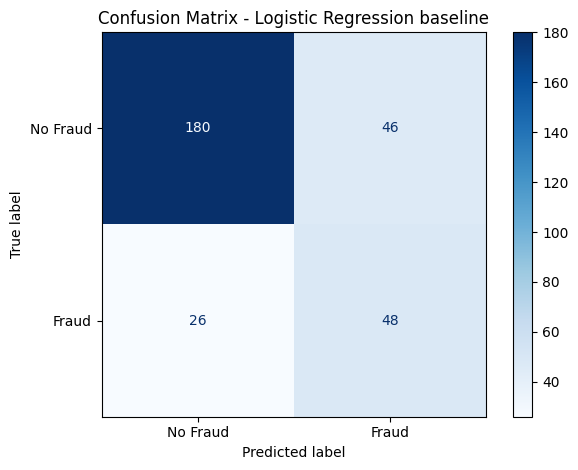

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriu de confusió visual - Logistic Regression baseline
cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["No Fraud", "Fraud"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression baseline")
plt.tight_layout()
plt.show()

La regressió logística baseline obté un ROC-AUC aproximat de 0.750, fet que indica una capacitat raonable per discriminar entre reclamacions fraudulentes i no fraudulentes. Aquest resultat mostra que el dataset conté senyal predictiu útil i que una part dels patrons associats al frau poden ser capturats mitjançant una relació lineal entre les variables.

Pel que fa a la classe positiva, és a dir, els casos de frau, el model obté una precision de 0.51, un recall de 0.65 i un F1-score de 0.57. El recall és especialment rellevant en aquest context, ja que indica que el model detecta aproximadament el 65% dels fraus reals. Tot i això, encara deixa sense detectar 26 casos fraudulents del conjunt de test, que corresponen als falsos negatius.

La matriu de confusió mostra que el model classifica correctament 48 dels 74 casos de frau, mentre que 26 casos fraudulents són classificats com a no frau. També genera 46 falsos positius, és a dir, reclamacions no fraudulentes que el model marca com a possibles fraus. En aquest problema, aquest comportament pot ser acceptable fins a cert punt, ja que és preferible revisar alguns casos addicionals abans que deixar passar fraus sense detectar.

La matriu de confusió mostra que el model classifica correctament 48 dels 74 casos de frau, mentre que 26 casos fraudulents són classificats com a no frau. També genera 46 falsos positius, és a dir, reclamacions no fraudulentes que el model marca com a possibles fraus. En aquest problema, aquest comportament pot ser acceptable fins a cert punt, ja que és preferible revisar alguns casos addicionals abans que deixar passar fraus sense detectar.



**ROC-curve**

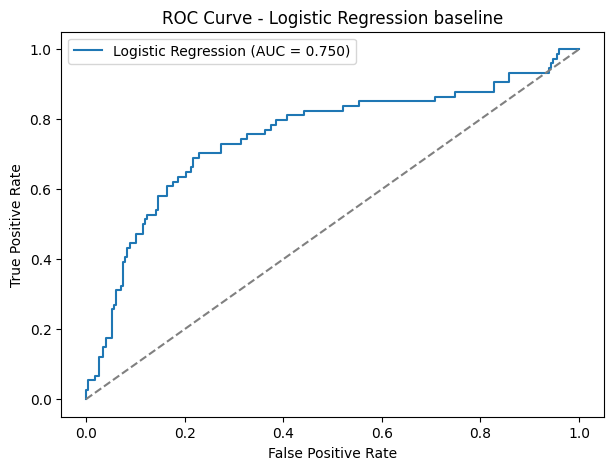

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_pred_proba_log)
roc_auc_log_curve = auc(fpr_log, tpr_log)

plt.figure(figsize=(7, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log_curve:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression baseline")
plt.legend()
plt.show()

La corba ROC de la regressió logística baseline se situa per sobre de la diagonal aleatòria, indicant que el model té capacitat discriminativa. El valor de ROC-AUC, proper a 0.75, és adequat per a un model lineal i interpretable.

Tot i això, en un problema de detecció de frau, el ROC-AUC no s’ha d’interpretar de manera aïllada. Com que la classe positiva és minoritària, també és necessari analitzar mètriques específiques de la classe de frau, com el recall, la precision, el F1-score i l’Average Precision. Aquestes mètriques permeten valorar millor la utilitat pràctica del model en un escenari on els falsos negatius tenen un cost especialment rellevant.

**Interpretació de coeficients de la regressió logística final**

Una de les principals fortaleses de la regressió logística és la seva interpretabilitat. A diferència dels models black-box, aquest model permet analitzar directament els coeficients estimats per cada variable. Els coeficients positius indiquen una associació amb una probabilitat més alta de frau, mentre que els coeficients negatius indiquen una associació amb una probabilitat més baixa.

Per facilitar la interpretació, les variables s’ordenen segons el valor absolut del coeficient. D’aquesta manera es poden identificar les variables amb més pes en les prediccions del model.

In [8]:
# Interpretació de coeficients de la regressió logística final
coefficients = pd.DataFrame({
    "Feature": X_train_log.columns,
    "Beta": logreg_baseline.coef_[0]
})

coefficients["abs_beta"] = coefficients["Beta"].abs()
coefficients_sorted = coefficients.sort_values(by="abs_beta", ascending=False)

coefficients_sorted.head(20)

,Feature,Beta,abs_beta
56,incident_severity_Minor Damage,-2.708213,2.708213
58,incident_severity_Trivial Damage,-2.412501,2.412501
57,incident_severity_Total Loss,-2.092091,2.092091
79,auto_make_Audi,1.103162,1.103162
80,auto_make_BMW,1.036741,1.036741
44,insured_occupation_transport-moving,1.031859,1.031859
68,incident_state_WV,-0.921274,0.921274
36,insured_occupation_handlers-cleaners,-0.777324,0.777324
86,auto_make_Mercedes,0.760434,0.760434
29,insured_education_level_MD,0.613449,0.613449


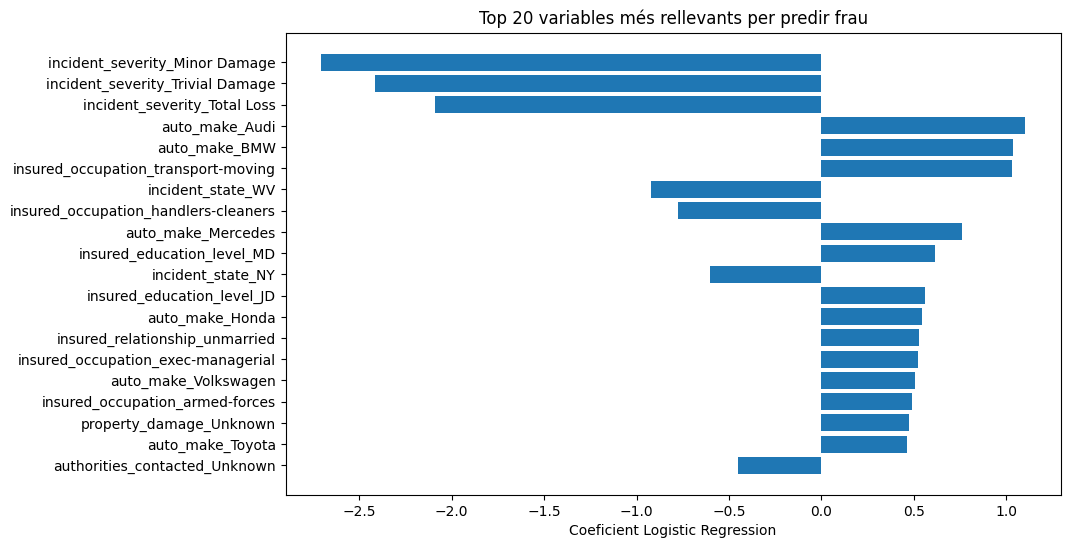

In [9]:
# Gràfic de les 20 variables més rellevants
top20 = coefficients_sorted.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["Feature"], top20["Beta"])
plt.xlabel("Coeficient Logistic Regression")
plt.title("Top 20 variables més rellevants per predir frau")
plt.gca().invert_yaxis()
plt.show()

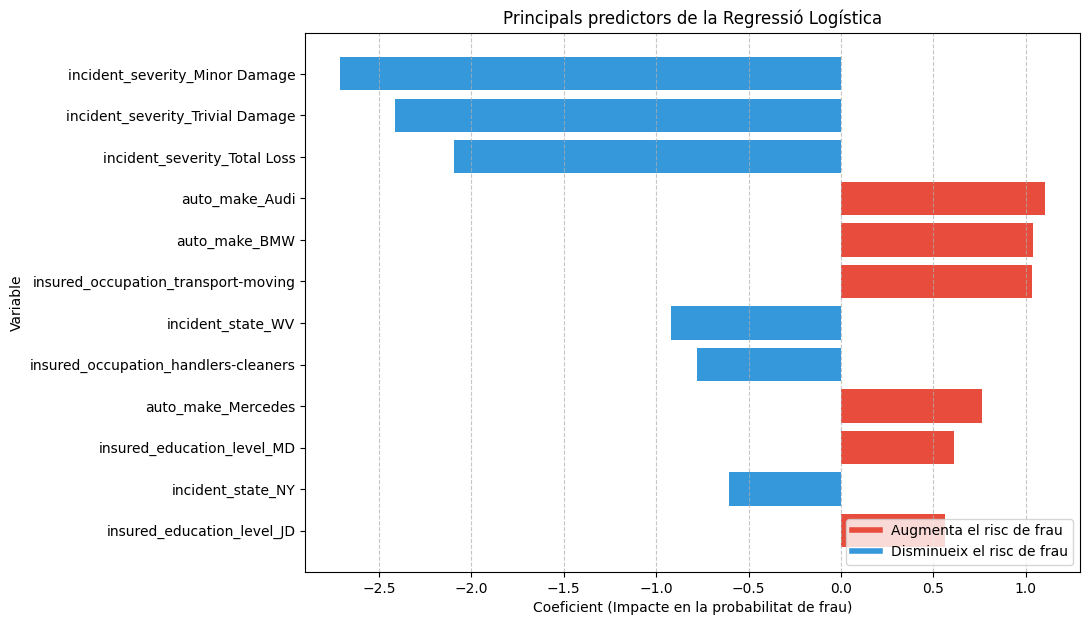

In [10]:
# Seleccionem les 10 o 12 primeres per a una millor visualització
top_n = coefficients_sorted.head(12).copy()

# Afegim una columna de color per distingir impacte positiu/negatiu
top_n['Color'] = ['#e74c3c' if x > 0 else '#3498db' for x in top_n['Beta']]

plt.figure(figsize=(10, 7))
bars = plt.barh(top_n["Feature"], top_n["Beta"], color=top_n['Color'])

plt.xlabel("Coeficient (Impacte en la probabilitat de frau)")
plt.ylabel("Variable")
plt.title("Principals predictors de la Regressió Logística")
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Invertim l'eix perquè la més important surti a dalt
plt.gca().invert_yaxis()

# Afegim una llegenda manual o text explicatiu si cal
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='#e74c3c', lw=4, label='Augmenta el risc de frau'),
                  Line2D([0], [0], color='#3498db', lw=4, label='Disminueix el risc de frau')]
plt.legend(handles=legend_elements, loc='lower right')

Els resultats mostren que les variables amb més influència estan relacionades principalment amb la severitat de l’incident. Les categories incident_severity_Minor Damage, incident_severity_Total Loss i incident_severity_Trivial Damage presenten coeficients negatius importants respecte a la categoria de referència, que correspon a Major Damage. Això indica que, en comparació amb incidents de major severitat, aquestes categories s’associen amb una probabilitat estimada de frau més baixa.

També apareixen variables relacionades amb el perfil de l’assegurat, com determinades ocupacions, i amb característiques del vehicle, com algunes marques. Tot i això, aquests efectes són menys dominants que els associats a la severitat de l’incident. En conjunt, la regressió logística permet obtenir una primera lectura clara dels patrons generals presents en les dades.

**P-values**

Com a complement interpretatiu, s’ajusta també un model Logit mitjançant statsmodels, que permet obtenir coeficients, errors estàndard i p-values. Aquesta anàlisi ajuda a identificar quines variables presenten una relació estadísticament significativa amb la probabilitat de frau.

In [11]:
# P-values amb statsmodels

import statsmodels.api as sm
import pandas as pd

# Statsmodels necessita dades numèriques
X_train_sm = X_train.astype(float).copy()
X_train_sm = sm.add_constant(X_train_sm)

y_train_sm = y_train.astype(float)

# Ajustar model Logit
logit_model = sm.Logit(y_train_sm, X_train_sm)
result = logit_model.fit(maxiter=1000)

# Resum complet del model
print(result.summary())

# Crear taula amb coeficients i p-values
pvalues_df = pd.DataFrame({
    "Feature": result.params.index,
    "coef": result.params.values,
    "p_value": result.pvalues.values
})

# Ordenar per p-value
pvalues_df = pvalues_df.sort_values("p_value")

print("\nTop variables amb menor p-value:")
print(pvalues_df.head(20))

# Variables estadísticament significatives (excloent la constant)
significant_vars = pvalues_df[
    (pvalues_df["Feature"] != "const") &
    (pvalues_df["p_value"] < 0.05)
]

print("\nVariables significatives (p < 0.05):")
print(significant_vars.head(20))

Optimization terminated successfully.
         Current function value: 0.370433
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:           fraud_binary   No. Observations:                  700
Model:                          Logit   Df Residuals:                      605
Method:                           MLE   Df Model:                           94
Date:                Tue, 26 May 2026   Pseudo R-squ.:                  0.3375
Time:                        17:22:07   Log-Likelihood:                -259.30
converged:                       True   LL-Null:                       -391.42
Covariance Type:            nonrobust   LLR p-value:                 4.251e-18
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     19.5076  

Les variables amb menor p-value són principalment categories de incident_severity, així com algunes variables relacionades amb la marca del vehicle, l’estat de l’incident, umbrella_limit i l’ocupació de l’assegurat. Aquest resultat reforça la importància de la severitat de l’incident com una de les variables més rellevants per al model.

Tot i això, aquests resultats s’han d’interpretar amb cautela. El model de statsmodels no incorpora exactament la mateixa configuració que el model baseline de sklearn, ja que no aplica class_weight="balanced" ni regularització. A més, la presència de moltes variables dummy pot generar col·linealitat i estimacions menys estables. Per aquest motiu, els p-values s’utilitzen únicament com a suport exploratori i no com a criteri principal de selecció de variables.

**Gràfic de distribució de probabilitats**

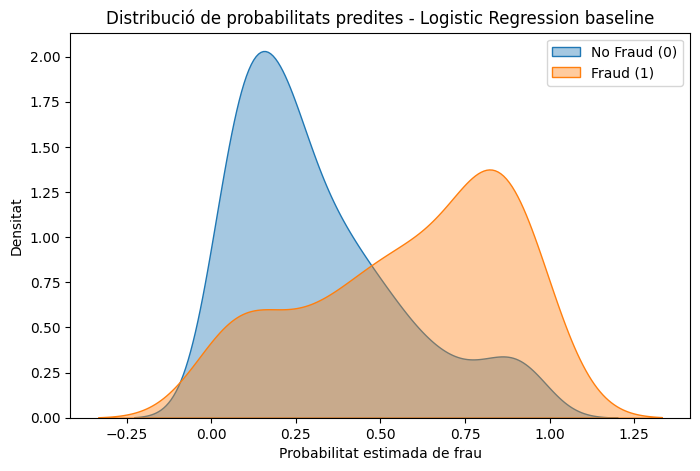

In [12]:
results_log_df = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred_proba": y_pred_proba_log
})

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=results_log_df[results_log_df["y_test"] == 0],
    x="y_pred_proba",
    label="No Fraud (0)",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    data=results_log_df[results_log_df["y_test"] == 1],
    x="y_pred_proba",
    label="Fraud (1)",
    fill=True,
    alpha=0.4
)

plt.title("Distribució de probabilitats predites - Logistic Regression baseline")
plt.xlabel("Probabilitat estimada de frau")
plt.ylabel("Densitat")
plt.legend()
plt.show()

La distribució de probabilitats predites mostra una certa separació entre els casos fraudulents i no fraudulents, però també una zona de solapament important. Això indica que el model és capaç d’identificar part del patró associat al frau, però no separa perfectament les dues classes.

Aquest comportament és coherent amb els resultats obtinguts: la regressió logística ofereix una capacitat predictiva raonable, però manté les limitacions pròpies d’un model lineal. En particular, pot tenir dificultats per capturar relacions no lineals i interaccions complexes entre variables, aspectes que seran explorats posteriorment amb models black-box.

**Conclusió Regressió Logística**

En conjunt, la regressió logística proporciona un baseline lineal, interpretable i útil per al problema de detecció de frau. El model obté un ROC-AUC aproximat de 0.75 i un recall de 0.65 per a la classe de frau, fet que mostra una capacitat moderada per detectar casos fraudulents.

Tot i que genera falsos positius, aquest comportament és assumible dins del context del problema, ja que és preferible revisar algunes reclamacions addicionals abans que deixar fraus sense detectar. No obstant això, el model també presenta falsos negatius, que representen fraus no identificats, i aquest és un aspecte crític en l’avaluació.

La regressió logística no s’optimitza en aquest treball perquè s’utilitza com a model baseline. La seva funció és establir una referència interpretable abans d’avaluar models més flexibles i menys transparents, que posteriorment requeriran tècniques XAI per explicar les seves prediccions.

### 4.2. Baseline no lineal: Decision Tree

En aquest apartat s’entrena un Decision Tree com a segon model baseline. A diferència de la regressió logística, que assumeix una relació lineal entre els predictors i la probabilitat de frau, l’arbre de decisió pot capturar relacions no lineals i interaccions entre variables mitjançant una estructura jeràrquica de regles.

Aquest model es considera un baseline no lineal interpretable. La seva utilitat principal és proporcionar una referència senzilla però més flexible que la regressió logística, mantenint una estructura que pot ser visualitzada i explicada de manera relativament directa.

En aquest treball, el Decision Tree no s’optimitza mitjançant una cerca exhaustiva d’hiperparàmetres, ja que s’utilitza com a model baseline. Es fixa una profunditat màxima de max_depth=5 per limitar la complexitat de l’arbre, reduir el risc de sobreajustament i mantenir la interpretabilitat del model. També s’utilitza class_weight="balanced" per compensar el desbalanceig entre les classes, donant més pes als casos de frau durant l’entrenament.

L’objectiu és analitzar si un model basat en regles jeràrquiques pot oferir una alternativa interpretable al baseline lineal i establir una comparació inicial abans d’entrenar models black-box més flexibles.

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Definició del model
dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

# Entrenament
dt.fit(X_train, y_train)

# Predicció de probabilitats
y_pred_proba_dt = dt.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
print("ROC-AUC Decision Tree:", roc_auc_dt)

# Predicció final amb threshold 0.5
y_pred_dt_class = (y_pred_proba_dt >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_class))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_class))

ROC-AUC Decision Tree: 0.700998564936618

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.82       226
           1       0.49      0.66      0.57        74

    accuracy                           0.75       300
   macro avg       0.69      0.72      0.70       300
weighted avg       0.78      0.75      0.76       300

Confusion Matrix:
[[176  50]
 [ 25  49]]


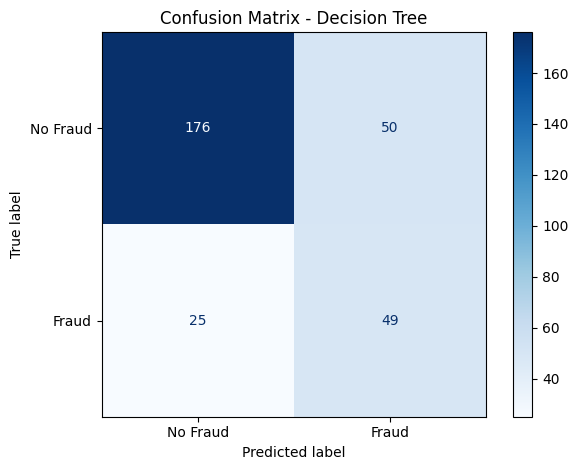

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriu de confusió visual - Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt_class)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Fraud", "Fraud"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

El Decision Tree obté un ROC-AUC aproximat de 0.701, fet que indica una capacitat discriminativa moderada. Aquest valor és inferior al de la regressió logística baseline, però el model manté un comportament rellevant sobre la classe positiva, que és la més important en aquest problema.

Pel que fa als casos de frau, el model obté una precision de 0.49, un recall de 0.66 i un F1-score de 0.57. El recall indica que el Decision Tree identifica 49 dels 74 casos fraudulents del conjunt de test. Això és positiu des del punt de vista de detecció de frau, ja que el model aconsegueix detectar una proporció considerable dels fraus reals.

La matriu de confusió mostra que el model deixa sense detectar 25 casos fraudulents, que corresponen als falsos negatius. També genera 50 falsos positius, és a dir, reclamacions no fraudulentes classificades com a possibles fraus. En aquest context, els falsos positius impliquen revisions addicionals, però els falsos negatius són més crítics, ja que representen fraus que no serien detectats pel sistema.

Per tant, el Decision Tree és útil com a baseline interpretable no lineal. Tot i això, el seu rendiment global és limitat i mostra una precision baixa per a la classe de frau, fet que indica que una part important de les alertes generades no corresponen realment a casos fraudulents.

Per facilitar la interpretació del model, es visualitzen els primers nivells de l’arbre de decisió. Aquesta representació permet identificar quines variables intervenen en les primeres particions i com el model construeix regles per separar casos de frau i no frau.



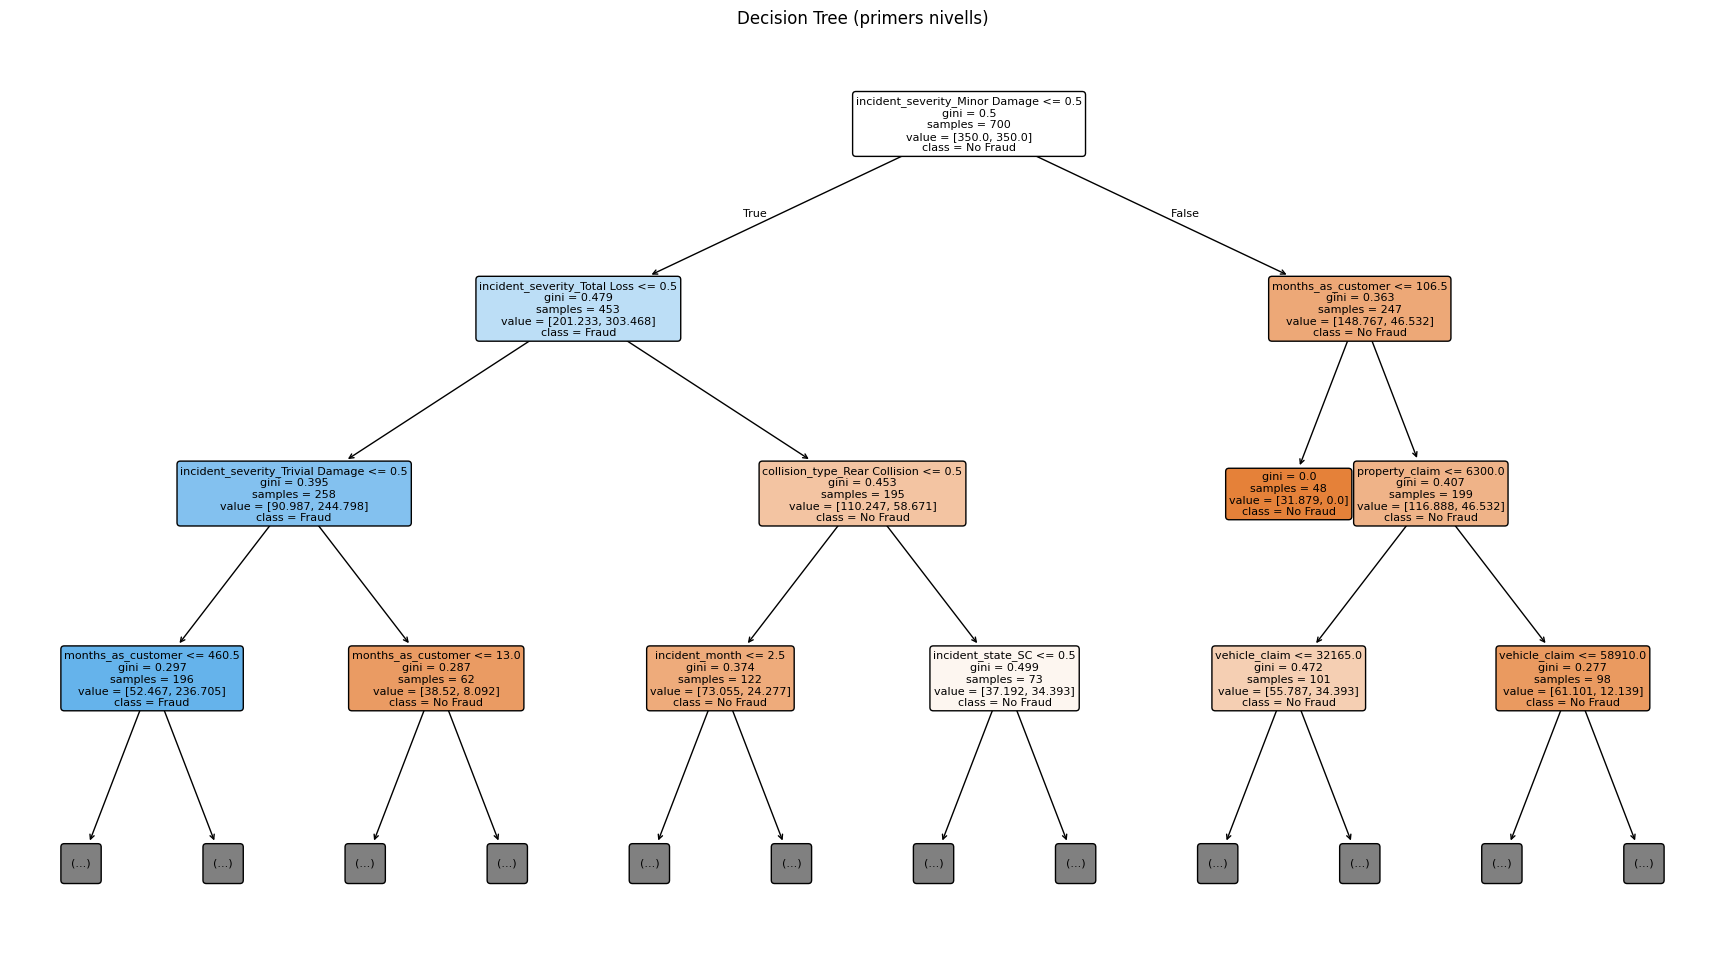

In [15]:
# Visualització de l'arbre
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=["No Fraud", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Decision Tree (primers nivells)")
plt.show()

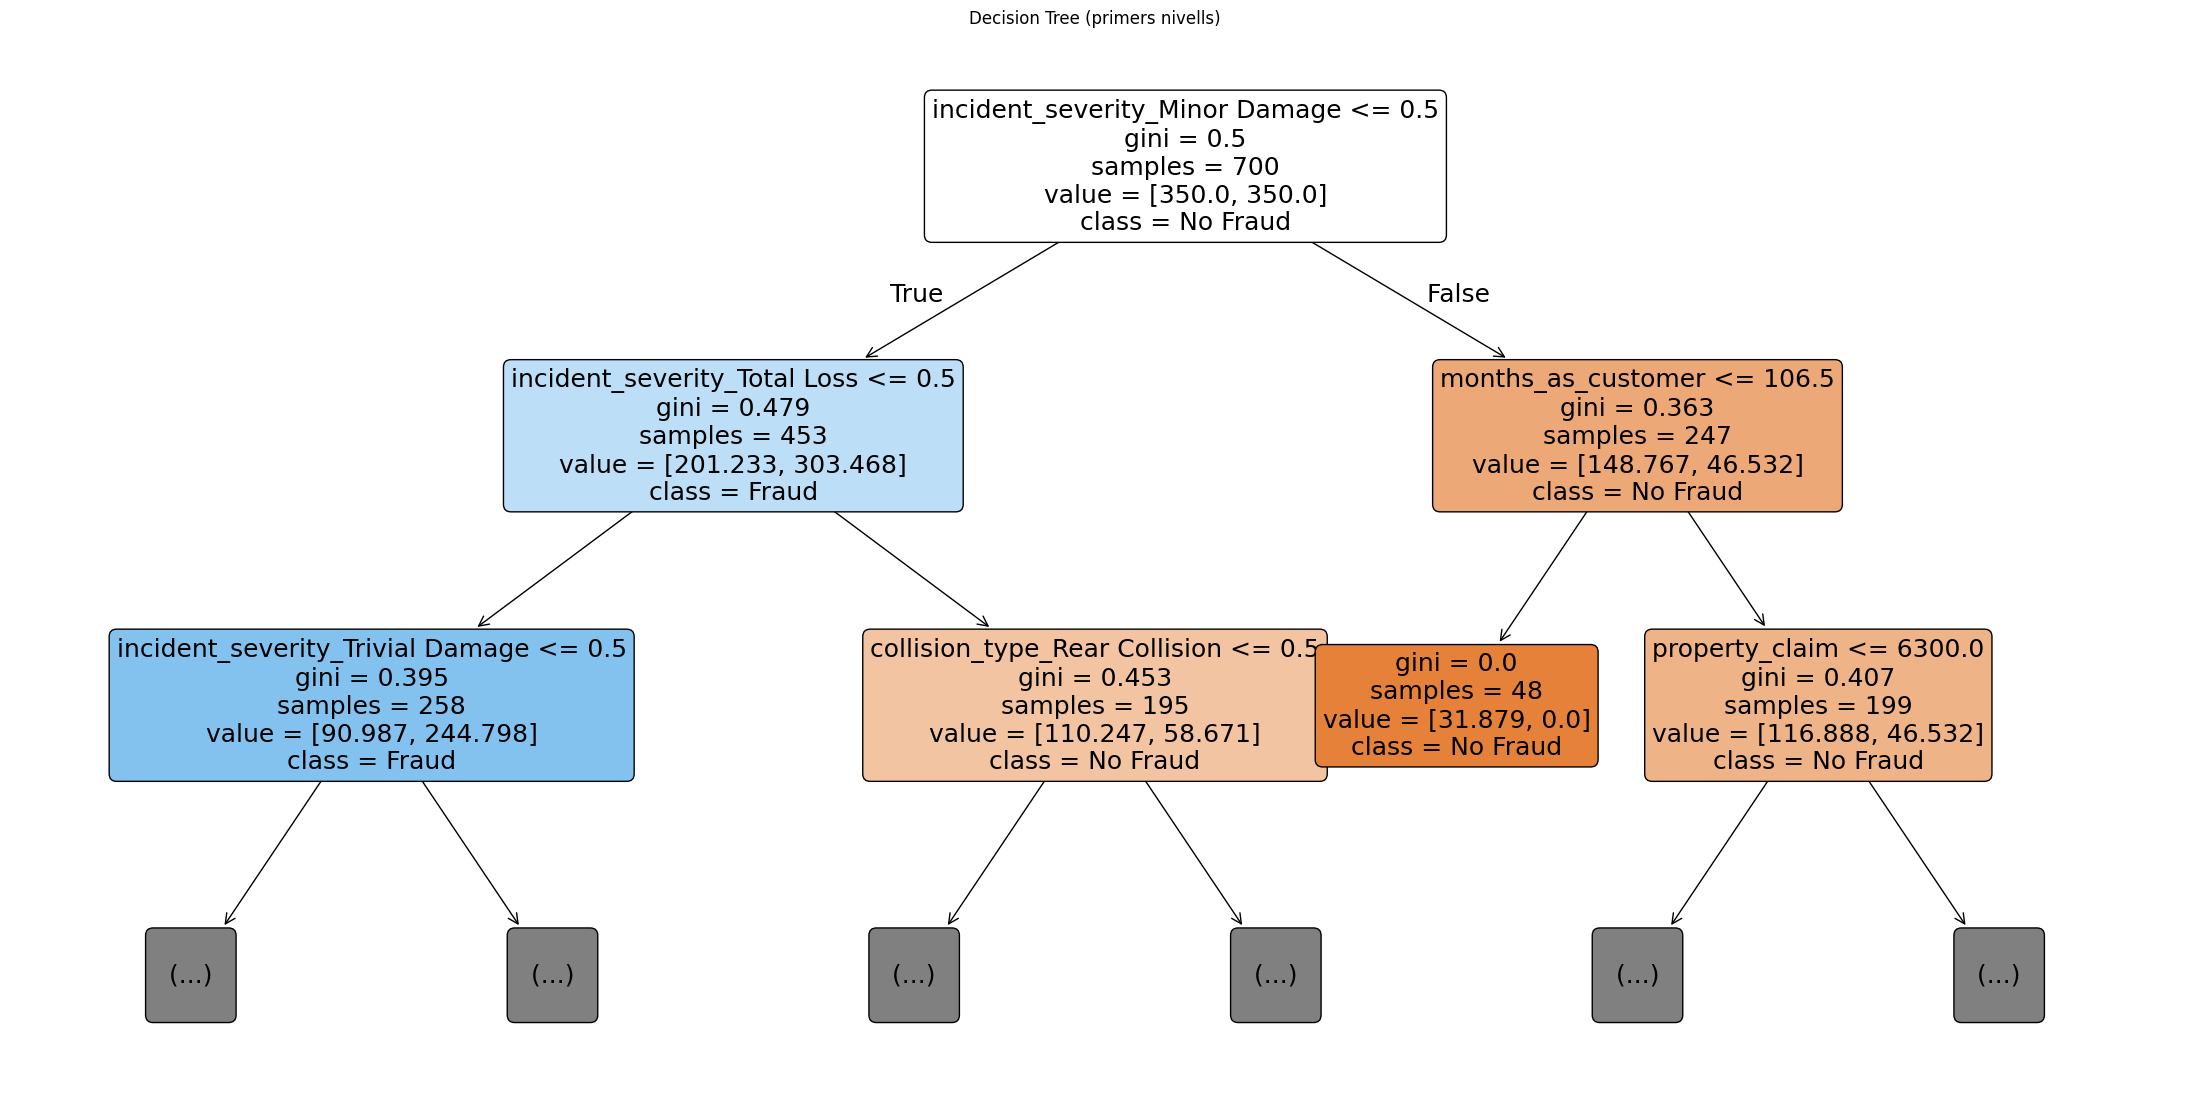

In [16]:
plt.figure(figsize=(28, 14))

plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=["No Fraud", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=18,
    max_depth=2
)

plt.title("Decision Tree (primers nivells)")
plt.show()

El Decision Tree construeix una estructura jeràrquica de decisions basada en particions successives de les variables del dataset. Aquesta estructura permet interpretar quines regles utilitza el model per separar les reclamacions fraudulentes de les no fraudulentes.

Per facilitar-ne la lectura, es visualitzen només els primers nivells de l’arbre. Aquesta representació permet identificar les variables que intervenen en les primeres particions, que solen ser les més rellevants per al model.

La visualització mostra que les primeres particions es basen sobretot en variables relacionades amb la severitat de l’incident, especialment incident_severity_Minor Damage, incident_severity_Trivial Damage i incident_severity_Total Loss. Aquest resultat és coherent amb l’anàlisi feta amb la regressió logística i reforça la idea que la severitat del sinistre és una de les principals fonts de senyal predictiu del dataset.

En nivells posteriors també apareixen variables relacionades amb els imports de la reclamació, l’antiguitat com a client, característiques del sinistre i informació de la pòlissa. Això indica que l’arbre construeix regles combinant característiques del sinistre, del client i de la pòlissa. Tot i ser interpretable, aquesta estructura pot ser sensible a petites variacions del conjunt d’entrenament.

**Variables amb més importància**

In [17]:
feature_importance_dt = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt.feature_importances_
})

feature_importance_dt = (
    feature_importance_dt
    .sort_values(by="Importance", ascending=False)
    .round(4)
)

feature_importance_dt.head(20)

,Feature,Importance
56,incident_severity_Minor Damage,0.2101
58,incident_severity_Trivial Damage,0.1890
57,incident_severity_Total Loss,0.1854
13,vehicle_claim,0.0918
0,months_as_customer,0.0727
9,bodily_injuries,0.0333
66,incident_state_SC,0.0296
3,policy_annual_premium,0.0270
16,incident_month,0.0269
4,umbrella_limit,0.0257


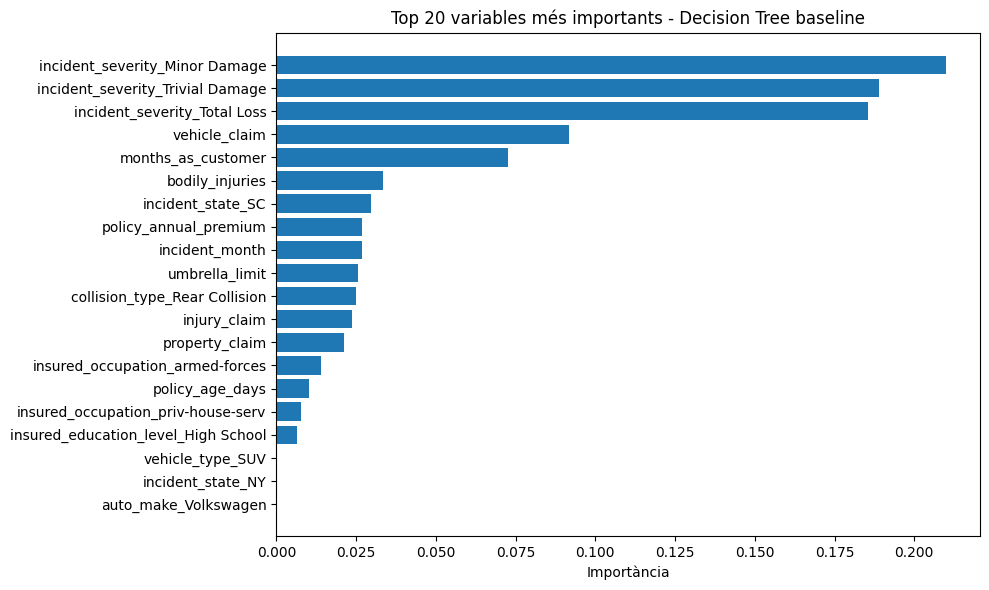

In [18]:
# Gràfic de les 20 variables més importants del Decision Tree
top20_dt = feature_importance_dt.head(20).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top20_dt["Feature"], top20_dt["Importance"])
plt.xlabel("Importància")
plt.title("Top 20 variables més importants - Decision Tree baseline")
plt.tight_layout()
plt.show()

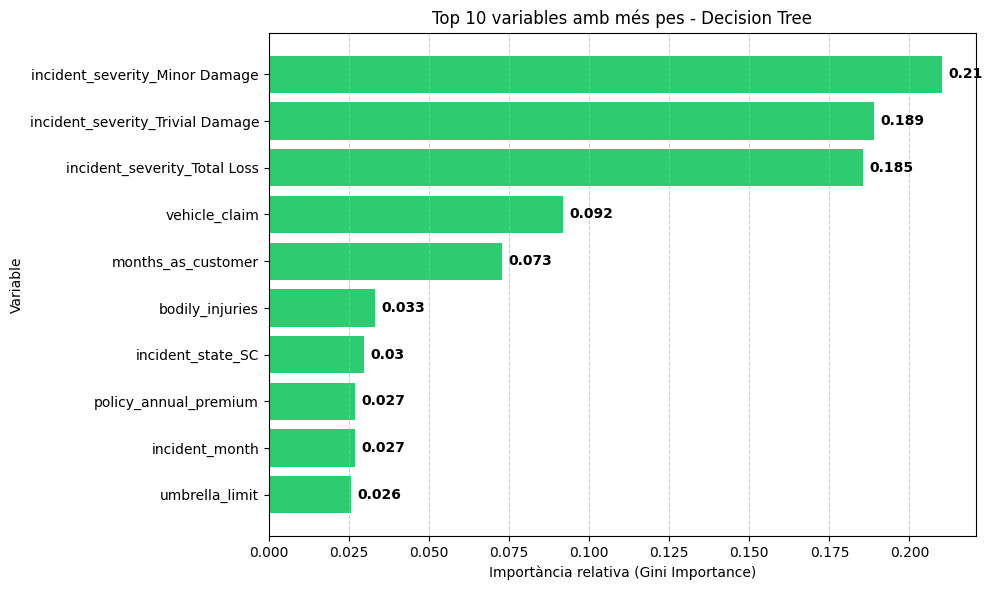

In [19]:
# Agafem el Top 10 per evitar barres amb importància quasi zero
top10_dt = feature_importance_dt.head(10).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top10_dt["Feature"], top10_dt["Importance"], color='#2ecc71')

plt.xlabel("Importància relativa (Gini Importance)")
plt.ylabel("Variable")
plt.title("Top 10 variables amb més pes - Decision Tree")
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Afegim els valors al final de les barres per fer-ho més llegible
for i, v in enumerate(top10_dt["Importance"]):
   plt.text(v + 0.002, i, str(round(v, 3)), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretació de la importància de variables**

La importància de variables del Decision Tree confirma que el model es recolza principalment en la severitat de l’incident. Les tres categories derivades de incident_severity concentren una part molt elevada de la importància total del model. Això indica que el primer criteri de separació entre frau i no frau està molt lligat a la gravetat declarada del sinistre.

Després de la severitat, apareixen variables relacionades amb l’import de la reclamació, com vehicle_claim, injury_claim i property_claim, així com variables del perfil temporal i contractual, com months_as_customer, policy_age_days i policy_annual_premium. També apareixen variables contextuals de l’incident, com bodily_injuries, incident_month o collision_type_Rear Collision.

En conjunt, el Decision Tree ofereix una interpretació clara basada en regles, però concentra molt la seva decisió en poques variables. Aquesta dependència pot limitar la seva capacitat de generalització i explica per què, tot i ser interpretable, no presenta el millor rendiment global.

**ROC Curve**

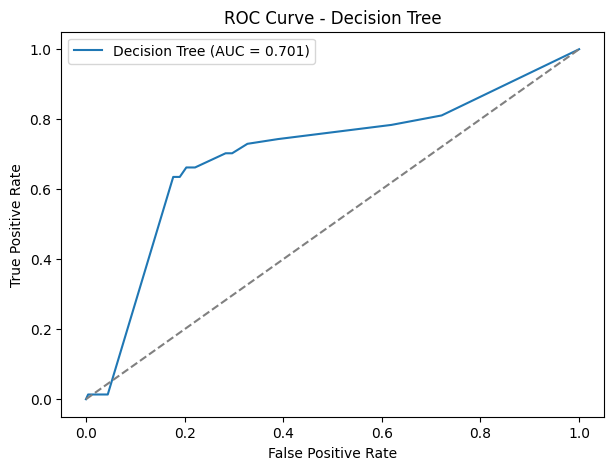

In [20]:
from sklearn.metrics import roc_curve, auc

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt_curve = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(7,5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt_curve:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

La corba ROC del Decision Tree se situa per sobre de la diagonal aleatòria, fet que indica que el model té certa capacitat per discriminar entre casos fraudulents i no fraudulents. No obstant això, la separació respecte a la diagonal és moderada, coherent amb el ROC-AUC obtingut.

Aquest resultat mostra que el Decision Tree és capaç de detectar una part important dels fraus, però no ordena les observacions positives i negatives amb tanta solidesa com altres models. Per aquest motiu, el ROC-AUC s’ha d’interpretar juntament amb les mètriques de la classe positiva, especialment el recall i la precision.

### 4.3. Resum dels models baseline

A continuació es comparen els dos models baseline entrenats: la regressió logística i el Decision Tree. Tots dos models són interpretables, però representen enfocaments diferents. La regressió logística actua com a baseline lineal, mentre que el Decision Tree actua com a baseline no lineal basat en regles.

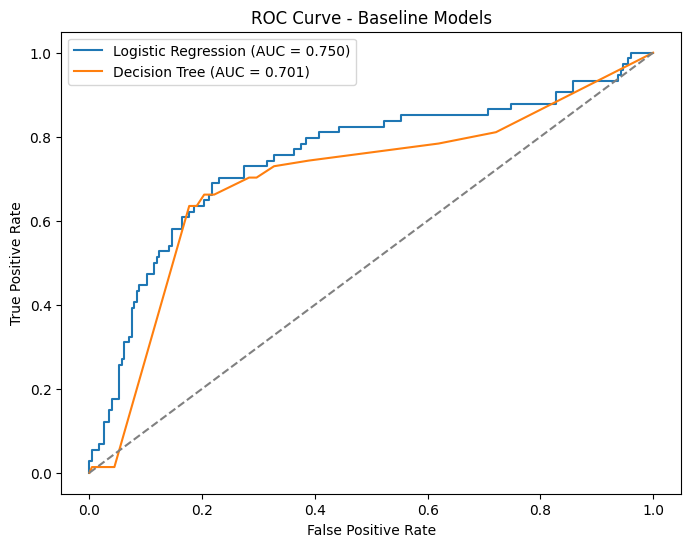

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression baseline
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
roc_auc_log = auc(fpr_log, tpr_log)

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt_curve = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt_curve:.3f})")
plt.plot([0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Models")
plt.legend()
plt.show()

La comparació de les corbes ROC mostra que la regressió logística presenta una capacitat discriminativa global superior, amb un ROC-AUC aproximat de 0.750, davant del 0.701 obtingut pel Decision Tree. Això indica que, en aquest dataset, el model lineal ordena millor les observacions segons la probabilitat estimada de frau.

Tot i això, si s’analitzen les mètriques de la classe positiva, el Decision Tree presenta un recall lleugerament superior al de la regressió logística. El Decision Tree detecta 49 dels 74 fraus del conjunt de test, mentre que la regressió logística en detecta 48. Ara bé, aquest increment és molt petit i va acompanyat d’una precision inferior, ja que el Decision Tree genera més falsos positius.

Aquests resultats estableixen el punt de referència per als models black-box. Els models més complexos no només hauran de superar o igualar els baselines en ROC-AUC, sinó també oferir un comportament adequat en les mètriques més rellevants per a la detecció de frau: recall, precision i F1-score de la classe positiva. A més, com que aquests models seran menys interpretables, posteriorment serà necessari aplicar tècniques XAI per analitzar i justificar les seves prediccions.

# 5. Entrenament de models més complexos: Black box models

En la secció anterior s’han analitzat dos models baseline interpretables: la regressió logística com a model lineal i el Decision Tree com a baseline no lineal. Aquests models han permès establir un punt de referència inicial tant en termes de rendiment predictiu com d’interpretabilitat.

En aquesta nova fase s’entrenen models més complexos, habitualment considerats black-box, capaços de capturar relacions no lineals, interaccions entre variables i patrons més difícils de representar amb models simples. Aquests models poden oferir un millor rendiment en problemes de classificació tabular com la detecció de frau en assegurances, però ho fan a costa d’una menor transparència en el procés de decisió.

Els models analitzats en aquesta fase són:

- Random Forest
- XGBoost
- MLP
- SVC amb kernel RBF

Com que l’objectiu del treball és la detecció de frau, aquests models no s’avaluaran únicament a partir del ROC-AUC. També es donarà una importància especial a l’Average Precision, la precision, el recall i el F1-score de la classe positiva. En aquest context, detectar correctament els fraus és prioritari, ja que els falsos negatius poden tenir un cost més elevat que els falsos positius.

Posteriorment, els models black-box amb millor rendiment seran analitzats mitjançant tècniques d’explicabilitat com SHAP i Anchors, amb l’objectiu d’aportar transparència a les prediccions i estudiar l’estabilitat de les explicacions generades.

## 5.1. Model Random Forest

El Random Forest és un model d’ensemble basat en la combinació de múltiples arbres de decisió. Cada arbre s’entrena sobre una mostra aleatòria de les dades i utilitza subconjunts aleatoris de variables en les particions. Aquesta estratègia permet reduir la variància pròpia d’un únic arbre de decisió i millorar la capacitat de generalització.

En el context de la detecció de frau, el Random Forest és especialment útil perquè pot capturar relacions no lineals i interaccions entre variables sense requerir una transformació complexa de les dades. A diferència del Decision Tree baseline, que consisteix en un únic arbre interpretable, el Random Forest combina molts arbres, fet que en millora l’estabilitat però en redueix la interpretabilitat directa.

Per aquest motiu, el Random Forest es considera un model black-box en aquest treball. Tot i que permet obtenir una mesura global d’importància de variables, aquesta informació no explica per si sola com es construeix cada predicció individual. Per això, més endavant serà necessari aplicar tècniques XAI més específiques, com SHAP i Anchors.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
import pandas as pd
import matplotlib.pyplot as plt

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
avg_precision_rf = average_precision_score(y_test, y_pred_proba_rf)

print("ROC-AUC Random Forest:", round(roc_auc_rf, 3))
print("Average Precision Random Forest:", round(avg_precision_rf, 3))

y_pred_rf_05 = (y_pred_proba_rf >= 0.5).astype(int)

print("\nClassification Report threshold 0.5:")
print(classification_report(y_test, y_pred_rf_05))

print("Confusion Matrix threshold 0.5:")
print(confusion_matrix(y_test, y_pred_rf_05))

ROC-AUC Random Forest: 0.772
Average Precision Random Forest: 0.509

Classification Report threshold 0.5:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85       226
           1       0.40      0.05      0.10        74

    accuracy                           0.75       300
   macro avg       0.58      0.51      0.47       300
weighted avg       0.67      0.75      0.67       300

Confusion Matrix threshold 0.5:
[[220   6]
 [ 70   4]]


**Funció de mètriques**

In [23]:
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return acc, prec, rec, f1

In [24]:
# Mètriques threshold 0.5

acc_rf, prec_rf, rec_rf, f1_rf = get_metrics(y_test, y_pred_rf_05)

rf_metrics_05 = pd.DataFrame([{
    "Model": "Random Forest",
    "Threshold": 0.5,
    "ROC-AUC": roc_auc_rf,
    "Average Precision": avg_precision_rf,
    "Accuracy": acc_rf,
    "Precision": prec_rf,
    "Recall": rec_rf,
    "F1-score": f1_rf
}]).round(3)

rf_metrics_05

,Model,Threshold,ROC-AUC,Average Precision,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.5,0.772,0.509,0.747,0.4,0.054,0.095


In [25]:
print("Mètriques Random Forest threshold 0.5")
print("ROC-AUC:", round(roc_auc_rf, 3))
print("Average Precision:", round(avg_precision_rf, 3))
print("Accuracy:", round(acc_rf, 3))
print("Precision:", round(prec_rf, 3))
print("Recall:", round(rec_rf, 3))
print("F1-score:", round(f1_rf, 3))

Mètriques Random Forest threshold 0.5
ROC-AUC: 0.772
Average Precision: 0.509
Accuracy: 0.747
Precision: 0.4
Recall: 0.054
F1-score: 0.095


En una primera avaluació s’utilitza el threshold estàndard de 0.5 per convertir les probabilitats estimades en classes. Amb aquest llindar, el Random Forest obté un ROC-AUC de 0.772 i una Average Precision de 0.509. Aquests valors indiquen que el model té una capacitat raonable per ordenar les observacions segons el risc estimat de frau.

No obstant això, quan s’analitza la classificació final amb threshold 0.5, el comportament del model no és adequat per a l’objectiu del problema. El recall de la classe positiva és només de 0.054, fet que significa que el model detecta únicament 4 dels 74 casos fraudulents del conjunt de test. La matriu de confusió mostra 70 falsos negatius, és a dir, fraus reals classificats com a no frau.

Aquest resultat és especialment important perquè demostra que un bon ROC-AUC no garanteix necessàriament una bona detecció de frau quan s’utilitza el threshold per defecte. El model ordena relativament bé els casos segons risc, però és massa conservador a l’hora de classificar una reclamació com a fraudulenta.

Per aquest motiu, és necessari analitzar l’efecte de diferents thresholds sobre les mètriques de la classe positiva.

**ROC CURVE**

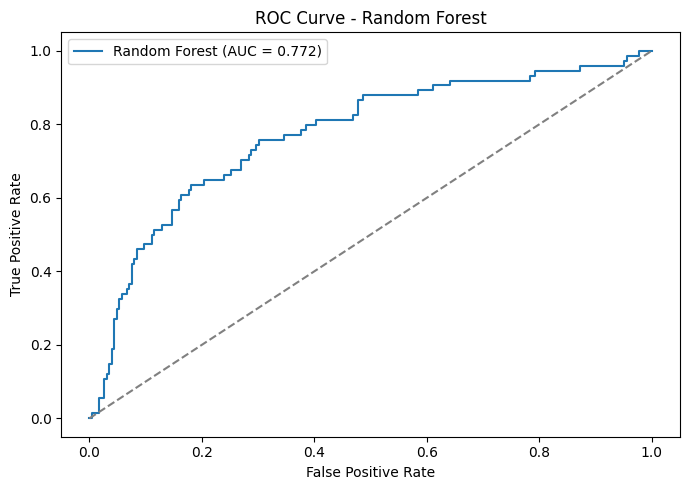

In [26]:
from sklearn.metrics import roc_curve, auc

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf_curve = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf_curve:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

La corba ROC del Random Forest se situa clarament per sobre de la diagonal aleatòria, fet que confirma que el model té capacitat discriminativa. El ROC-AUC de 0.772 és superior al dels models baseline, cosa que indica que el model és capaç de capturar patrons més complexos presents en les dades.

Tot i això, en un problema desbalancejat com la detecció de frau, aquesta mètrica s’ha d’interpretar amb cautela. La corba ROC avalua la capacitat global d’ordenació del model, però no mostra directament si el threshold escollit és adequat per detectar la classe minoritària. Per això, es complementa l’anàlisi amb Average Precision, recall, precision i F1-score.

**Threshold tuning**

Atès que el Random Forest presenta un bon ROC-AUC però un recall molt baix amb el threshold estàndard de 0.5, s’analitza l’efecte de diferents llindars de classificació. L’objectiu és trobar un threshold més adequat per a la detecció de frau, prioritzant un millor equilibri entre recall i precision.

En aquest problema, reduir el threshold pot ser una decisió adequada, ja que permet classificar com a sospitoses més reclamacions i augmentar la detecció de fraus. Això pot generar més falsos positius, però en el context de frau aquest cost pot ser assumible si permet reduir els falsos negatius.

In [27]:
threshold_results_rf = []

for threshold in np.arange(0.10, 0.71, 0.01):
    y_pred_t = (y_pred_proba_rf >= threshold).astype(int)

    threshold_results_rf.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t)
    })

threshold_results_rf = pd.DataFrame(threshold_results_rf)

threshold_results_rf_sorted = (
    threshold_results_rf
    .sort_values(["f1", "recall", "precision"], ascending=[False, False, False])
    .round(3)
)

threshold_results_rf_sorted.head(10)

,threshold,accuracy,precision,recall,f1
23,0.33,0.773,0.534,0.635,0.580
24,0.34,0.780,0.550,0.595,0.571
22,0.32,0.750,0.495,0.649,0.561
18,0.28,0.710,0.446,0.730,0.554
21,0.31,0.737,0.476,0.662,0.554
19,0.29,0.717,0.452,0.703,0.550
20,0.30,0.730,0.467,0.662,0.547
26,0.36,0.793,0.597,0.500,0.544
17,0.27,0.677,0.416,0.770,0.540
25,0.35,0.777,0.549,0.527,0.538


In [28]:
best_threshold_rf = (
    threshold_results_rf
    .sort_values(["f1", "recall", "precision"], ascending=[False, False, False])
    .iloc[0]["threshold"]
)

print("Millor threshold Random Forest:", best_threshold_rf)

y_pred_rf_final = (y_pred_proba_rf >= best_threshold_rf).astype(int)

print("\nClassification Report Random Forest final:")
print(classification_report(y_test, y_pred_rf_final))

print("Confusion Matrix Random Forest final:")
print(confusion_matrix(y_test, y_pred_rf_final))

Millor threshold Random Forest: 0.33

Classification Report Random Forest final:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       226
           1       0.53      0.64      0.58        74

    accuracy                           0.77       300
   macro avg       0.70      0.73      0.71       300
weighted avg       0.79      0.77      0.78       300

Confusion Matrix Random Forest final:
[[185  41]
 [ 27  47]]


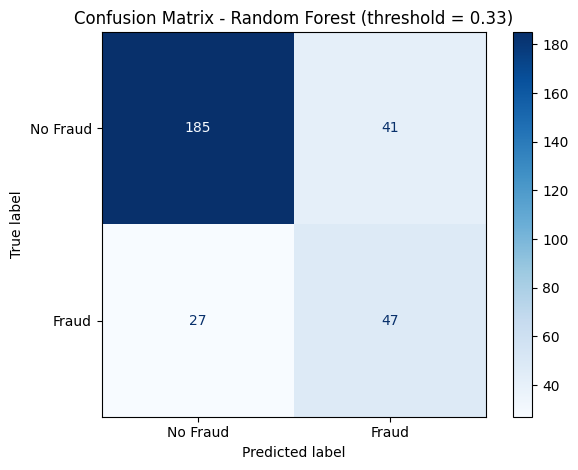

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriu de confusió visual - Random Forest (amb threshold òptim)
cm_rf = confusion_matrix(y_test, y_pred_rf_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Fraud", "Fraud"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(f"Confusion Matrix - Random Forest (threshold = {best_threshold_rf:.2f})")
plt.tight_layout()
plt.show()

Per facilitar la interpretació visual, es limiten a intervals on el model encara genera un nombre rellevant de prediccions positives, evitant comportaments degenerats en thresholds extrems.

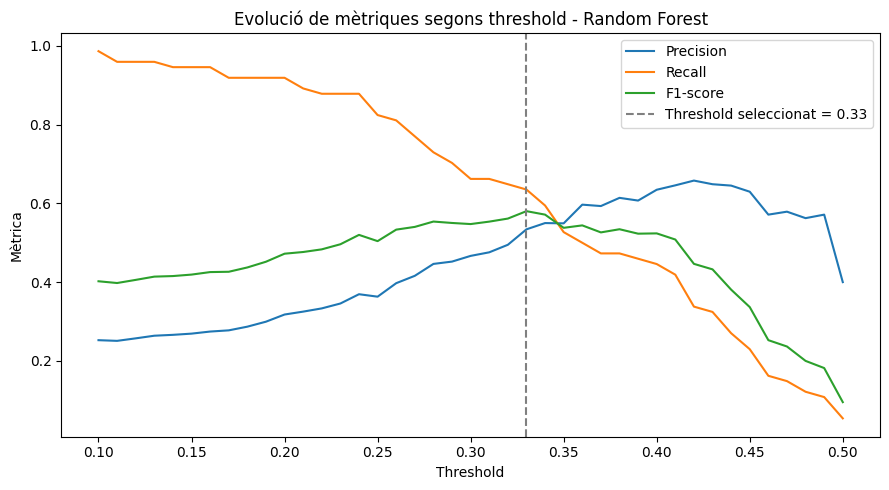

In [30]:
plt.figure(figsize=(9, 5))

mask = threshold_results_rf["recall"] > 0.05

plt.plot(
    threshold_results_rf.loc[mask, "threshold"],
    threshold_results_rf.loc[mask, "precision"],
    label="Precision"
)

plt.plot(
    threshold_results_rf.loc[mask, "threshold"],
    threshold_results_rf.loc[mask, "recall"],
    label="Recall"
)

plt.plot(
    threshold_results_rf.loc[mask, "threshold"],
    threshold_results_rf.loc[mask, "f1"],
    label="F1-score"
)

plt.axvline(
    best_threshold_rf,
    color="gray",
    linestyle="--",
    label=f"Threshold seleccionat = {best_threshold_rf:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Mètrica")
plt.title("Evolució de mètriques segons threshold - Random Forest")

plt.legend()
plt.tight_layout()
plt.show()

Els resultats mostren que el millor threshold segons el F1-score és 0.33. Amb aquest llindar, el model obté una accuracy de 0.773, una precision de 0.534, un recall de 0.635 i un F1-score de 0.580 per a la classe de frau. La matriu de confusió mostra que el model detecta 47 dels 74 casos fraudulents, mentre que deixa 27 fraus sense detectar.

Aquest canvi representa una millora molt important respecte al threshold 0.5, on només es detectaven 4 fraus. Per tant, el Random Forest mostra que les probabilitats estimades contenen informació útil, però que cal ajustar el threshold per adaptar el model a l’objectiu específic de detecció de frau.

In [31]:
acc_rf_final = accuracy_score(y_test, y_pred_rf_final)
prec_rf_final = precision_score(y_test, y_pred_rf_final, zero_division=0)
rec_rf_final = recall_score(y_test, y_pred_rf_final)
f1_rf_final = f1_score(y_test, y_pred_rf_final)
roc_auc_rf_final = roc_auc_score(y_test, y_pred_proba_rf)
avg_precision_rf_final = average_precision_score(y_test, y_pred_proba_rf)

rf_summary = pd.DataFrame([{
    "Model": "Random Forest",
    "Threshold": best_threshold_rf,
    "ROC-AUC": roc_auc_rf_final,
    "Average Precision": avg_precision_rf_final,
    "Accuracy": acc_rf_final,
    "Precision": prec_rf_final,
    "Recall": rec_rf_final,
    "F1-score": f1_rf_final
}]).round(3)

rf_summary

,Model,Threshold,ROC-AUC,Average Precision,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.33,0.772,0.509,0.773,0.534,0.635,0.58


L’ajust del threshold transforma clarament el comportament del Random Forest. Amb el llindar estàndard, el model és massa conservador i gairebé no detecta fraus. En canvi, amb un threshold de 0.33, el model aconsegueix un equilibri més adequat entre precision i recall.

Aquest resultat reforça una de les idees centrals del treball: en problemes de detecció de frau, no és suficient comparar models només amb ROC-AUC o accuracy. És necessari analitzar el comportament del model sobre la classe positiva i ajustar la decisió final segons el cost dels errors. En aquest cas, reduir els falsos negatius és prioritari, encara que això impliqui acceptar un cert increment dels falsos positius.

**Importància de variables**

Un cop ajustat el comportament del model mitjançant el threshold, s’analitza la importància de variables del Random Forest. Aquesta mesura permet identificar quines característiques contribueixen més a les decisions del conjunt d’arbres.


In [32]:
feature_importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance_rf = (
    feature_importance_rf
    .sort_values(by="Importance", ascending=False)
    .round(4)
)

feature_importance_rf.head(20)

,Feature,Importance
56,incident_severity_Minor Damage,0.0667
13,vehicle_claim,0.0590
12,property_claim,0.0549
11,injury_claim,0.0465
3,policy_annual_premium,0.0406
0,months_as_customer,0.0405
57,incident_severity_Total Loss,0.0386
15,policy_age_days,0.0373
7,incident_hour_of_the_day,0.0321
1,age,0.0320


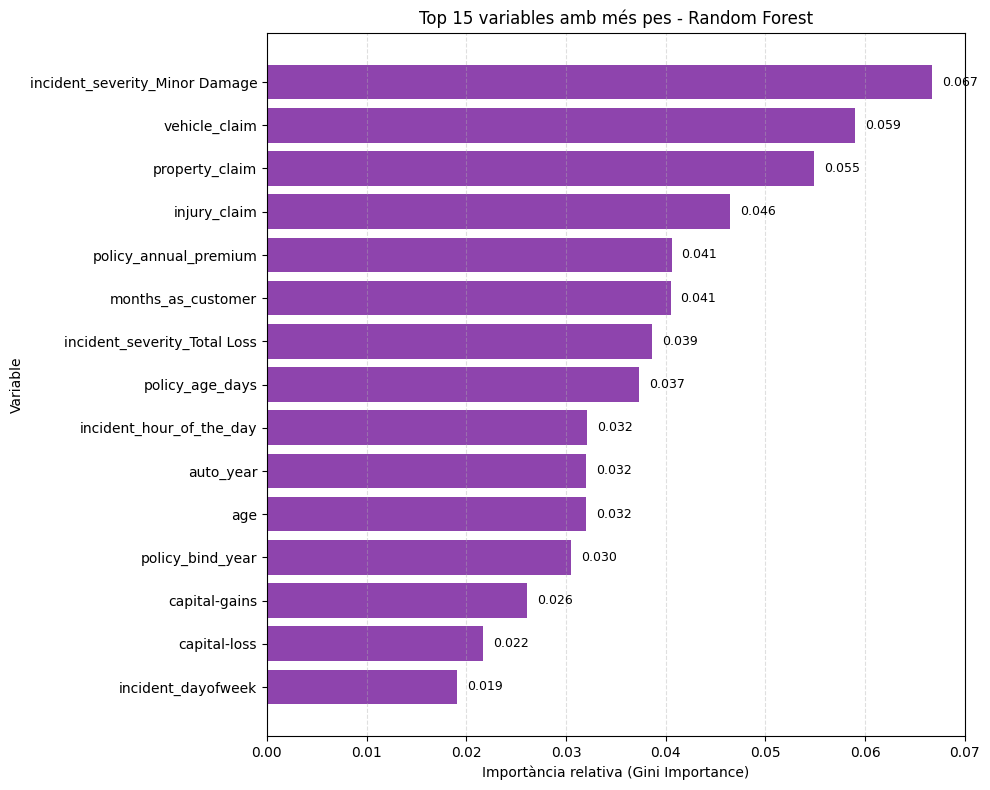

In [33]:
# Agafem el Top 15 per mostrar la varietat del Random Forest
top15_rf = feature_importance_rf.head(15).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top15_rf["Feature"], top15_rf["Importance"], color='#8e44ad')

plt.xlabel("Importància relativa (Gini Importance)")
plt.ylabel("Variable")
plt.title("Top 15 variables amb més pes - Random Forest")
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Afegim els valors al final per precisió
for i, v in enumerate(top15_rf["Importance"]):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

Els resultats mostren que el model utilitza principalment informació relacionada amb la severitat de l’incident i els imports de la reclamació. Destaquen variables com incident_severity_Minor Damage, vehicle_claim, property_claim i injury_claim, fet que indica que el model aprofita tant la naturalesa del sinistre com la dimensió econòmica de la reclamació.

També apareixen variables temporals i de perfil, com months_as_customer, policy_age_days, incident_hour_of_the_day, age i auto_year. Això suggereix que el Random Forest no depèn d’una única variable, sinó que combina informació econòmica, temporal, contractual i contextual per estimar el risc de frau.

Tot i això, la importància de variables del Random Forest s’ha d’interpretar com una aproximació global. Aquesta mesura no mostra l’efecte concret de cada variable sobre una predicció individual ni indica si una variable augmenta o redueix la probabilitat de frau. Per aquest motiu, en apartats posteriors s’utilitzaran tècniques XAI com SHAP i Anchors per obtenir explicacions més detallades.

**Conclusió Random Forest**

El Random Forest obté el millor ROC-AUC fins aquest punt del notebook, amb un valor aproximat de 0.772. Això indica que el model té una bona capacitat per ordenar els casos segons el risc estimat de frau. No obstant això, l’avaluació amb threshold 0.5 mostra que aquesta capacitat no es tradueix automàticament en una bona detecció de la classe positiva.

Després d’ajustar el threshold a 0.33, el model millora de manera clara el seu comportament en detecció de frau, amb un recall de 0.635 i un F1-score de 0.580. Aquesta configuració permet detectar molts més fraus que el threshold estàndard, tot i assumir un increment dels falsos positius.

En conjunt, el Random Forest mostra un rendiment superior als baseline en termes de ROC-AUC i ofereix un comportament més equilibrat després de l’ajust del threshold. Tot i això, com que és un model d’ensemble menys transparent que els models baseline, serà necessari aplicar tècniques d’explicabilitat per entendre millor les seves prediccions.

## 5.2. XGBoost

XGBoost és un model d’ensemble basat en arbres de decisió construïts de manera seqüencial mitjançant gradient boosting. A diferència del Random Forest, que combina arbres entrenats de forma més independent, XGBoost entrena cada arbre intentant corregir els errors dels arbres anteriors. Aquesta estratègia permet capturar patrons complexos, relacions no lineals i interaccions entre variables.

En aquest treball, XGBoost es considera un model black-box, ja que la predicció final depèn de la combinació de múltiples arbres i no és directament interpretable com en el cas d’un arbre de decisió individual. Tot i això, el model ofereix mesures globals d’importància de variables, que poden servir com a primera aproximació abans d’aplicar tècniques XAI més robustes.

Com que XGBoost disposa de diversos hiperparàmetres que controlen la complexitat, la regularització, el ritme d’aprenentatge i el mostreig de variables i observacions, s’utilitza RandomizedSearchCV per optimitzar-ne la configuració. Aquesta estratègia permet explorar un espai ampli de combinacions sense el cost computacional d’un Grid Search exhaustiu.

Atès que el dataset presenta desbalanceig de classes, s’incorpora scale_pos_weight per donar més pes a la classe minoritària, corresponent als casos de frau. L’optimització es fa amb validació creuada estratificada i utilitzant Average Precision com a mètrica principal, ja que és especialment adequada en problemes on la classe positiva és minoritària.

In [34]:
# 5.2 XGBoost

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from scipy.stats import randint, uniform
import numpy as np
import pandas as pd

# Pes de la classe positiva per compensar el desbalanceig
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

# Model base
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

# Espai d'hiperparàmetres
param_dist_xgb = {
    "n_estimators": randint(100, 900),
    "max_depth": randint(2, 6),
    "learning_rate": uniform(0.01, 0.10),
    "subsample": uniform(0.70, 0.30),
    "colsample_bytree": uniform(0.70, 0.30),
    "min_child_weight": randint(3, 15),
    "gamma": uniform(0, 8),
    "reg_alpha": uniform(0, 4),
    "reg_lambda": uniform(1, 8)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cerca orientada a PR-AUC, adequada per classe positiva desbalancejada
random_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=150,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=123
)

random_xgb.fit(X_train, y_train)

best_xgb = random_xgb.best_estimator_

print("Millors paràmetres XGBoost:")
print(random_xgb.best_params_)

print("\nMillor CV Average Precision:")
print(random_xgb.best_score_)

scale_pos_weight: 3.046242774566474
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Millors paràmetres XGBoost:
{'colsample_bytree': 0.9595932825267459, 'gamma': 6.818226460155217, 'learning_rate': 0.10076020915893373, 'max_depth': 2, 'min_child_weight': 13, 'n_estimators': 191, 'reg_alpha': 0.542693188500289, 'reg_lambda': 5.509316743193542, 'subsample': 0.918123985150999}

Millor CV Average Precision:
0.5263717114614164


**Optimització del model**

La cerca aleatòria s’ha realitzat amb validació creuada estratificada de 5 particions. Aquesta estratègia manté la proporció de casos fraudulents i no fraudulents en cada partició, fet especialment important en un problema desbalancejat.

La mètrica utilitzada per seleccionar la millor configuració ha estat l’Average Precision, ja que resumeix el comportament del model en la corba precision-recall i dona més informació sobre la classe positiva que mètriques globals com l’accuracy.

El valor de scale_pos_weight s’ha calculat a partir de la proporció entre casos no fraudulents i fraudulents del conjunt d’entrenament. Això permet penalitzar més els errors sobre la classe de frau i orientar el model cap a una millor detecció de la classe minoritària.

La millor configuració obtinguda presenta una profunditat baixa dels arbres (max_depth=2) i valors de regularització relativament elevats. Això suggereix que el model final evita arbres excessivament complexos i intenta controlar el sobreajustament, fet adequat tenint en compte que el dataset només conté 1.000 observacions.

**Avaluació del model**

In [35]:
# Predicció de probabilitats
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
avg_precision_xgb = average_precision_score(y_test, y_pred_proba_xgb)

print("ROC-AUC XGBoost optimitzat:", roc_auc_xgb)
print("Average Precision XGBoost optimitzat:", avg_precision_xgb)

# Predicció amb threshold 0.5
y_pred_xgb_05 = (y_pred_proba_xgb >= 0.5).astype(int)

print("\nClassification Report threshold 0.5:")
print(classification_report(y_test, y_pred_xgb_05))

print("Confusion Matrix threshold 0.5:")
print(confusion_matrix(y_test, y_pred_xgb_05))

ROC-AUC XGBoost optimitzat: 0.7579825400621861
Average Precision XGBoost optimitzat: 0.5349216214674528

Classification Report threshold 0.5:
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       226
           1       0.61      0.68      0.64        74

    accuracy                           0.81       300
   macro avg       0.75      0.77      0.76       300
weighted avg       0.82      0.81      0.82       300

Confusion Matrix threshold 0.5:
[[194  32]
 [ 24  50]]


**Mètriques resum**

In [36]:
acc_xgb = accuracy_score(y_test, y_pred_xgb_05)
prec_xgb = precision_score(y_test, y_pred_xgb_05, zero_division=0)
rec_xgb = recall_score(y_test, y_pred_xgb_05)
f1_xgb = f1_score(y_test, y_pred_xgb_05)

print("Mètriques XGBoost threshold 0.5")
print("Accuracy:", acc_xgb)
print("Precision:", prec_xgb)
print("Recall:", rec_xgb)
print("F1-score:", f1_xgb)
print("ROC-AUC:", roc_auc_xgb)
print("Average Precision:", avg_precision_xgb)

Mètriques XGBoost threshold 0.5
Accuracy: 0.8133333333333334
Precision: 0.6097560975609756
Recall: 0.6756756756756757
F1-score: 0.6410256410256411
ROC-AUC: 0.7579825400621861
Average Precision: 0.5349216214674528


El model XGBoost optimitzat obté un ROC-AUC aproximat de 0.758 i una Average Precision de 0.535. Aquests resultats indiquen una capacitat discriminativa raonable i un comportament adequat en un context de classe positiva minoritària.

Amb el threshold estàndard de 0.5, el model aconsegueix una accuracy de 0.813, una precision de 0.610, un recall de 0.676 i un F1-score de 0.641 per a la classe de frau. Aquests valors mostren un bon equilibri entre la capacitat de detectar fraus i el control dels falsos positius.

La matriu de confusió mostra que XGBoost detecta 50 dels 74 casos fraudulents del conjunt de test, mentre que deixa sense detectar 24 fraus. També genera 32 falsos positius. En el context d’aquest treball, aquest comportament és rellevant perquè redueix el nombre de falsos negatius mantenint una precision superior a la dels models baseline.

Aquest resultat és especialment important perquè confirma que l’avaluació dels models de detecció de frau no s’ha de basar només en el ROC-AUC. Tot i que el ROC-AUC és útil per mesurar la capacitat global de discriminació, mètriques com recall, precision i F1-score permeten valorar millor la utilitat real del model en la detecció de la classe positiva.

**Threshold tuning**

Després d’avaluar el model amb el threshold estàndard de 0.5, s’analitza l’efecte de diferents thresholds sobre les mètriques de classificació. L’objectiu és comprovar si un altre llindar podria millorar l’equilibri entre precision i recall per a la classe de frau.

In [37]:
threshold_results_xgb = []

for threshold in np.arange(0.10, 0.71, 0.01):
    y_pred_t = (y_pred_proba_xgb >= threshold).astype(int)

    threshold_results_xgb.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t)
    })

threshold_results_xgb = pd.DataFrame(threshold_results_xgb)

threshold_results_xgb.sort_values(
    ["f1", "recall", "precision"],
    ascending=[False, False, False]
).head(10)

,threshold,accuracy,precision,recall,f1
40,0.50,0.813333,0.609756,0.675676,0.641026
41,0.51,0.813333,0.609756,0.675676,0.641026
49,0.59,0.820000,0.631579,0.648649,0.640000
50,0.60,0.820000,0.631579,0.648649,0.640000
39,0.49,0.806667,0.595238,0.675676,0.632911
45,0.55,0.813333,0.615385,0.648649,0.631579
46,0.56,0.813333,0.615385,0.648649,0.631579
47,0.57,0.813333,0.615385,0.648649,0.631579
48,0.58,0.813333,0.615385,0.648649,0.631579
51,0.61,0.816667,0.626667,0.635135,0.630872


In [38]:
# Seleccionar automàticament el millor threshold segons F1-score
best_threshold_xgb = (
    threshold_results_xgb
    .sort_values(["f1", "recall", "precision"], ascending=[False, False, False])
    .iloc[0]["threshold"]
)

print("Millor threshold XGBoost:", best_threshold_xgb)

y_pred_xgb_final = (y_pred_proba_xgb >= best_threshold_xgb).astype(int)

print("\nClassification Report XGBoost final:")
print(classification_report(y_test, y_pred_xgb_final))

print("Confusion Matrix XGBoost final:")
print(confusion_matrix(y_test, y_pred_xgb_final))

Millor threshold XGBoost: 0.5

Classification Report XGBoost final:
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       226
           1       0.61      0.68      0.64        74

    accuracy                           0.81       300
   macro avg       0.75      0.77      0.76       300
weighted avg       0.82      0.81      0.82       300

Confusion Matrix XGBoost final:
[[194  32]
 [ 24  50]]


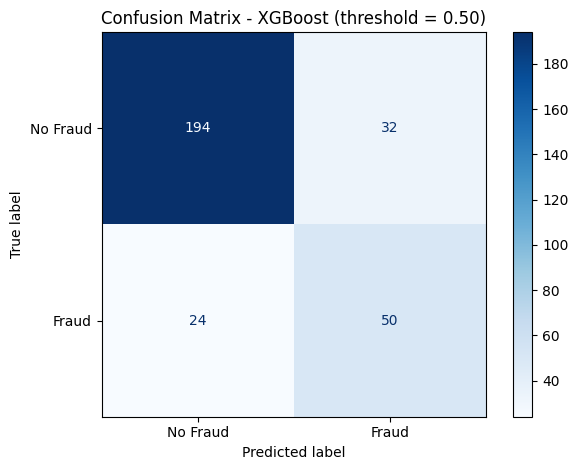

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriu de confusió visual - XGBoost (amb threshold òptim)
cm_xgb = confusion_matrix(y_test, y_pred_xgb_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Fraud", "Fraud"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(f"Confusion Matrix - XGBoost (threshold = {best_threshold_xgb:.2f})")
plt.tight_layout()
plt.show()

In [40]:
acc_xgb_final = accuracy_score(y_test, y_pred_xgb_final)
prec_xgb_final = precision_score(y_test, y_pred_xgb_final, zero_division=0)
rec_xgb_final = recall_score(y_test, y_pred_xgb_final)
f1_xgb_final = f1_score(y_test, y_pred_xgb_final)
roc_auc_xgb_final = roc_auc_score(y_test, y_pred_proba_xgb)
avg_precision_xgb_final = average_precision_score(y_test, y_pred_proba_xgb)

print("Mètriques XGBoost final")
print("Threshold:", best_threshold_xgb)
print("Accuracy:", acc_xgb_final)
print("Precision:", prec_xgb_final)
print("Recall:", rec_xgb_final)
print("F1-score:", f1_xgb_final)
print("ROC-AUC:", roc_auc_xgb_final)
print("Average Precision:", avg_precision_xgb_final)

Mètriques XGBoost final
Threshold: 0.5
Accuracy: 0.8133333333333334
Precision: 0.6097560975609756
Recall: 0.6756756756756757
F1-score: 0.6410256410256411
ROC-AUC: 0.7579825400621861
Average Precision: 0.5349216214674528


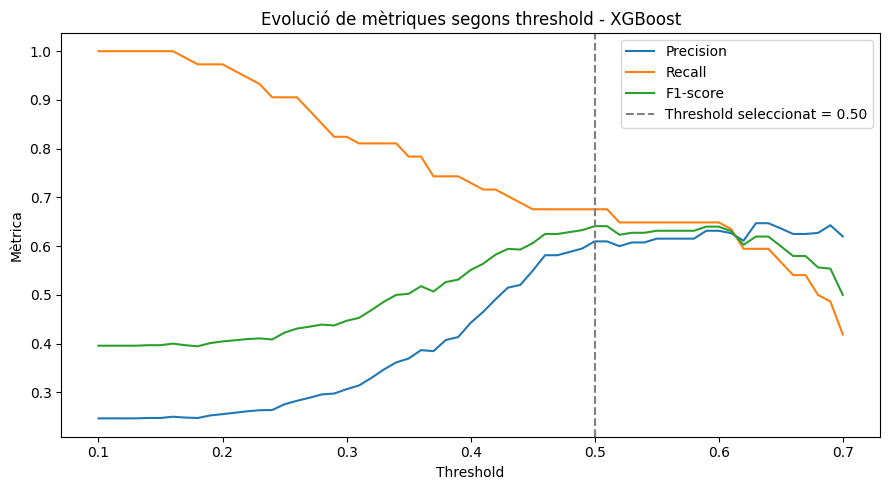

In [41]:
# Mètriques segons threshold
plt.figure(figsize=(9, 5))
plt.plot(threshold_results_xgb["threshold"], threshold_results_xgb["precision"], label="Precision")
plt.plot(threshold_results_xgb["threshold"], threshold_results_xgb["recall"], label="Recall")
plt.plot(threshold_results_xgb["threshold"], threshold_results_xgb["f1"], label="F1-score")

plt.axvline(best_threshold_xgb, color="gray", linestyle="--",
            label=f"Threshold seleccionat = {best_threshold_xgb:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Mètrica")
plt.title("Evolució de mètriques segons threshold - XGBoost")
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
#resum
xgb_summary = pd.DataFrame([{
    "Model": "XGBoost optimitzat",
    "Threshold": best_threshold_xgb,
    "ROC-AUC": roc_auc_xgb_final,
    "Average Precision": avg_precision_xgb_final,
    "Accuracy": acc_xgb_final,
    "Precision": prec_xgb_final,
    "Recall": rec_xgb_final,
    "F1-score": f1_xgb_final
}])

xgb_summary

,Model,Threshold,ROC-AUC,Average Precision,Accuracy,Precision,Recall,F1-score
0,XGBoost optimitzat,0.5,0.757983,0.534922,0.813333,0.609756,0.675676,0.641026


En aquest cas, el threshold tuning confirma que el llindar de 0.5 és el millor segons F1-score. Això indica que, a diferència del Random Forest, XGBoost ja proporciona una classificació equilibrada amb el threshold estàndard.

Amb aquest llindar, el model manté un recall de 0.676 i una precision de 0.610, fet que significa que detecta una proporció important dels fraus sense generar un volum excessiu de falsos positius. Per tant, no és necessari modificar el threshold final del model.

Cal tenir en compte que, metodològicament, la selecció del threshold s’hauria de fer idealment sobre un conjunt de validació o mitjançant validació creuada, i no directament sobre el conjunt de test. En aquest cas, però, l’anàlisi serveix com a comprovació complementària, ja que el threshold final coincideix amb el valor estàndard de 0.5.

**Importància de variables**

Per entendre millor el comportament del model, s’analitza la importància de les variables utilitzades per XGBoost. Aquesta anàlisi permet identificar quines característiques tenen més pes en la construcció de les prediccions i comparar-les amb les observades en els models anteriors.

In [43]:
# Importància de variables XGBoost

feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb.head(20)

,Feature,Importance
13,vehicle_claim,0.101731
56,incident_severity_Minor Damage,0.100446
57,incident_severity_Total Loss,0.094622
20,is_premium,0.043426
58,incident_severity_Trivial Damage,0.040725
12,property_claim,0.039534
7,incident_hour_of_the_day,0.038610
68,incident_state_WV,0.037733
54,collision_type_Rear Collision,0.036648
17,incident_dayofweek,0.033978


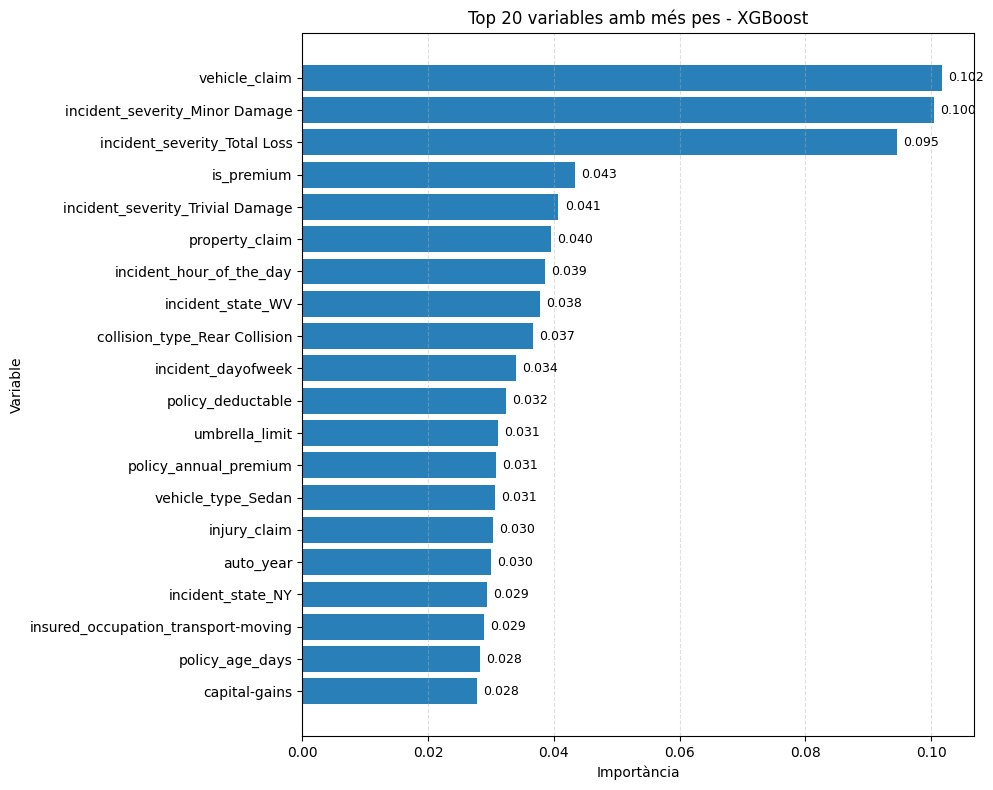

In [44]:
# Top 20 variables més importants - XGBoost

top20_xgb = feature_importance_xgb.head(20).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top20_xgb["Feature"], top20_xgb["Importance"], color='#2980b9')

plt.xlabel("Importància")
plt.ylabel("Variable")
plt.title("Top 20 variables amb més pes - XGBoost")

plt.grid(axis='x', linestyle='--', alpha=0.4)

# Afegim els valors al final de cada barra
for i, v in enumerate(top20_xgb["Importance"]):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

La importància de variables mostra que XGBoost utilitza principalment informació relacionada amb l’import de la reclamació i la severitat de l’incident. La variable vehicle_claim apareix com una de les més rellevants, juntament amb diverses categories de incident_severity, fet que indica que el model combina informació econòmica i descriptiva del sinistre.

També apareixen variables relacionades amb la pòlissa i el vehicle, com is_premium, policy_deductable, umbrella_limit, policy_annual_premium, auto_year i vehicle_type_Sedan. A més, el model incorpora informació temporal i contextual, com incident_hour_of_the_day, incident_dayofweek, policy_age_days i alguns estats de l’incident.

Aquesta interpretació és coherent amb el domini del problema, ja que el risc de frau pot estar relacionat tant amb la gravetat declarada del sinistre com amb els imports reclamats i determinades característiques contractuals. Tot i això, la importància interna de XGBoost és només una aproximació global i no explica l’efecte concret de cada variable sobre prediccions individuals. Per aquest motiu, posteriorment s’aplicaran tècniques com SHAP i Anchors.

**Conclusió del model**

XGBoost ofereix un dels resultats més equilibrats entre els models analitzats fins aquest punt. El model obté una accuracy superior al 81%, un recall de frau aproximat de 0.676, una precision de 0.610 i un F1-score de 0.641. Això indica que és capaç de detectar una proporció important dels casos fraudulents sense generar un volum excessiu de falsos positius.

Tot i que el ROC-AUC és similar al d’altres models, XGBoost destaca especialment en les mètriques de classificació final, que són més rellevants per al problema de detecció de frau. En comparació amb els baseline, presenta un millor equilibri entre recall i precision de la classe positiva.

Per aquest motiu, XGBoost és un bon candidat per a l’anàlisi posterior amb tècniques XAI. Com que és un model black-box, serà necessari aplicar SHAP i Anchors per explicar quines variables influeixen en les prediccions i valorar si aquestes explicacions són coherents i estables.

## 5.3. Xarxa neuronal (MLP)

En aquest apartat s’entrena una xarxa neuronal multicapa, o Multi-Layer Perceptron, com a model black-box per a la detecció de frau. Les xarxes neuronals permeten modelar relacions no lineals complexes entre variables i poden capturar interaccions difícils de representar amb models lineals o arbres simples.

En aquest treball, el MLP s’utilitza per avaluar si un model neuronal pot millorar la detecció de frau respecte als models baseline i als models d’ensemble basats en arbres. Tot i la seva flexibilitat, les xarxes neuronals no sempre són el millor enfocament per a datasets tabulars petits, especialment quan hi ha moltes variables generades mitjançant one-hot encoding. Per aquest motiu, el seu rendiment s’ha d’analitzar amb cura i comparar-lo amb la resta de models entrenats.

El MLP es considera un model black-box perquè la seva predicció depèn de múltiples capes, pesos i activacions internes que no són directament interpretables. A diferència de la regressió logística, no proporciona coeficients fàcilment interpretables, i a diferència dels models basats en arbres, no ofereix una importància de variables directa. Per això, la seva interpretació es reservarà per a tècniques XAI posteriors.

In [45]:
# 5.3 MLP optimitzat amb PyTorch

import random
import json
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from torch.utils.data import TensorDataset, DataLoader


**Preparació de l’entorn i reproductibilitat**

Abans d’entrenar la xarxa neuronal, es carreguen les llibreries necessàries i es fixa una llavor aleatòria per afavorir la reproductibilitat dels resultats. Aquesta decisió és important perquè l’entrenament d’una xarxa neuronal incorpora diversos elements aleatoris, com la inicialització dels pesos i l’ordre dels mini-batches.

També es comprova si hi ha una GPU disponible. En aquest cas, l’entrenament es realitza sobre CPU.


In [46]:
# Reproductibilitat
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


**Separació train/validation**

Per seleccionar els hiperparàmetres del MLP, el conjunt d’entrenament original es divideix internament en un subconjunt d’entrenament i un subconjunt de validació. Aquesta divisió permet comparar diferents configuracions del model sense utilitzar el conjunt de test durant la fase de selecció.

La partició es fa de manera estratificada per mantenir la proporció original de casos fraudulents i no fraudulents. Això és especialment important perquè la classe de frau és minoritària i una divisió no estratificada podria generar una validació poc representativa.

In [47]:
# Split train/validation a partir del train original

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("X_tr:", X_tr.shape)
print("X_val:", X_val.shape)

X_tr: (560, 95)
X_val: (140, 95)


**Escalat de dades**

Les xarxes neuronals són especialment sensibles a l’escala de les variables. Per aquest motiu, abans d’entrenar el MLP s’aplica `StandardScaler` a les variables del conjunt d’entrenament intern.

L’escalador s’ajusta únicament amb `X_tr` i després s’aplica a `X_val` i `X_test`. D’aquesta manera s’evita introduir informació del conjunt de validació o del conjunt de test durant l’ajust de l’escalat.

Finalment, les dades escalades es transformen a tensors de PyTorch, que és el format necessari per entrenar la xarxa neuronal.

In [48]:
# Escalat de dades

scaler_search_mlp = StandardScaler()

X_tr_scaled = scaler_search_mlp.fit_transform(X_tr)
X_val_scaled = scaler_search_mlp.transform(X_val)
X_test_scaled_search = scaler_search_mlp.transform(X_test)

X_tr_tensor = torch.tensor(X_tr_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor_search = torch.tensor(X_test_scaled_search, dtype=torch.float32)

y_tr_tensor = torch.tensor(y_tr.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

**Definició de l’arquitectura del MLP**

La xarxa neuronal utilitzada és un MLP amb capes ocultes totalment connectades. L’arquitectura es defineix de manera flexible, de manera que es poden provar diferents dimensions de capes durant la cerca d’hiperparàmetres.

Cada capa oculta està formada per una transformació lineal, seguida de Batch Normalization, una activació `LeakyReLU` i una capa de dropout. La Batch Normalization ajuda a estabilitzar l’entrenament, mentre que `LeakyReLU` introdueix no linealitat i redueix el risc de neurones inactives. El dropout s’utilitza com a tècnica de regularització per reduir el sobreajustament.

La capa final té una única neurona de sortida, que representa el logit associat a la probabilitat de frau. No s’aplica una sigmoid dins del model perquè posteriorment s’utilitza `BCEWithLogitsLoss`, que incorpora internament aquesta transformació de manera més estable numèricament.



In [49]:
# Arquitectura del MLP

class FraudMLP(nn.Module):
    def __init__(self, input_size, hidden_dims=(128, 64), dropout=0.3):
        super().__init__()

        layers = []
        prev_dim = input_size

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.LeakyReLU(negative_slope=0.1))
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

**DataLoader per entrenament en mini-batches**

Per entrenar el model s’utilitzen mini-batches mitjançant `DataLoader`. Aquesta estratègia permet actualitzar els pesos del model per blocs d’observacions en lloc d’utilitzar tot el conjunt d’entrenament a cada pas.

L’entrenament per mini-batches és habitual en xarxes neuronals, ja que millora l’eficiència del procés d’optimització i introdueix una certa variabilitat que pot ajudar a la generalització del model.


In [50]:
# DataLoader

def make_loader(X_tensor, y_tensor, batch_size, shuffle=False):
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

**Funció d’entrenament amb regularització i early stopping**

Es defineix una funció d’entrenament que permet entrenar el MLP amb diferents combinacions d’hiperparàmetres. Aquesta funció crea el model, defineix la funció de pèrdua, configura l’optimitzador i avalua el rendiment sobre el conjunt de validació.

Com que el dataset presenta desbalanceig de classes, la funció de pèrdua utilitza `BCEWithLogitsLoss` amb el paràmetre `pos_weight`. Aquest pes dona més importància als errors comesos sobre la classe positiva, que correspon als casos de frau. Aquesta decisió és coherent amb l’objectiu del treball, ja que no detectar un frau pot tenir un cost més elevat que marcar erròniament una reclamació com a sospitosa.

També s’utilitza `AdamW` com a optimitzador, incorporant `weight_decay` com a regularització. A més, s’aplica un scheduler que redueix el learning rate quan el ROC-AUC de validació deixa de millorar. Finalment, s’incorpora early stopping per aturar l’entrenament si el model no millora durant diverses èpoques consecutives, reduint així el risc de sobreajustament.


In [51]:
# Funció d'entrenament amb early stopping i scheduler

def train_mlp_model(
    params,
    X_tr_tensor,
    y_tr_tensor,
    X_val_tensor,
    y_val_tensor,
    y_val,
    input_size,
    device="cpu"
):
    model = FraudMLP(
        input_size=input_size,
        hidden_dims=params["hidden_dims"],
        dropout=params["dropout"]
    ).to(device)

    num_pos = y_tr_tensor.sum().item()
    num_neg = len(y_tr_tensor) - num_pos
    base_pos_weight = num_neg / num_pos
    pos_weight_value = base_pos_weight * params["pos_weight_factor"]

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
    )

    optimizer = optim.AdamW(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"]
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5
    )

    train_loader = make_loader(
        X_tr_tensor,
        y_tr_tensor,
        params["batch_size"],
        shuffle=True
    )

    best_val_auc = -np.inf
    best_state = None
    best_epoch = 0
    patience = 20
    patience_counter = 0

    for epoch in range(params["epochs"]):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_tensor.to(device))
            val_probs = torch.sigmoid(val_logits).cpu().numpy().flatten()

        val_auc = roc_auc_score(y_val, val_probs)
        scheduler.step(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    model.load_state_dict(best_state)

    return {
        "model": model,
        "best_val_auc": best_val_auc,
        "best_epoch": best_epoch,
        "params": params
    }

**Cerca d’hiperparàmetres**

Per seleccionar la configuració més adequada del MLP, es defineix una graella d’hiperparàmetres. Aquesta graella inclou diferents arquitectures de capes ocultes, valors de dropout, learning rate, weight decay i factors de ponderació per a la classe positiva.

L’objectiu és trobar una configuració que ofereixi una bona capacitat discriminativa en validació, però sense augmentar excessivament la complexitat del model. Aquest punt és important perquè el dataset és relativament petit i una xarxa massa complexa podria sobreajustar-se fàcilment.



In [52]:
# Grid refinat al voltant de configuracions robustes
param_grid_mlp = {
    "hidden_dims": [(128, 64), (64, 32)],
    "dropout": [0.25, 0.30, 0.35],
    "lr": [0.0003, 0.0005, 0.0007],
    "weight_decay": [5e-4, 1e-3],
    "batch_size": [32],
    "pos_weight_factor": [1.1, 1.2],
    "epochs": [180]
}

grid = list(ParameterGrid(param_grid_mlp))
print("Nombre de combinacions:", len(grid))

Nombre de combinacions: 72


**Entrenament i selecció del millor model**

A continuació s’entrenen totes les combinacions definides a la graella d’hiperparàmetres. Per cada configuració, el model s’entrena sobre el subconjunt `X_tr` i s’avalua sobre `X_val`.

La mètrica utilitzada per seleccionar la millor configuració és el ROC-AUC en validació. Aquesta mètrica permet valorar la capacitat del model per ordenar les observacions segons el risc estimat de frau, independentment del threshold final de classificació.


In [53]:
# Entrenament i selecció del millor model

results_mlp_grid = []
input_size = X_tr_tensor.shape[1]

for i, params in enumerate(grid, 1):
    print(f"\nCombinació {i}/{len(grid)}: {params}")

    result = train_mlp_model(
        params=params,
        X_tr_tensor=X_tr_tensor,
        y_tr_tensor=y_tr_tensor,
        X_val_tensor=X_val_tensor,
        y_val_tensor=y_val_tensor,
        y_val=y_val,
        input_size=input_size,
        device=device
    )

    print("Best val ROC-AUC:", result["best_val_auc"])
    print("Best epoch:", result["best_epoch"])

    results_mlp_grid.append(result)

best_result_mlp = max(results_mlp_grid, key=lambda x: x["best_val_auc"])

print("\nMillors hiperparàmetres MLP:")
print(best_result_mlp["params"])
print("Millor ROC-AUC validació:", best_result_mlp["best_val_auc"])
print("Millor epoch:", best_result_mlp["best_epoch"])


Combinació 1/72: {'batch_size': 32, 'dropout': 0.25, 'epochs': 180, 'hidden_dims': (128, 64), 'lr': 0.0003, 'pos_weight_factor': 1.1, 'weight_decay': 0.0005}
Best val ROC-AUC: 0.73578231292517
Best epoch: 41

Combinació 2/72: {'batch_size': 32, 'dropout': 0.25, 'epochs': 180, 'hidden_dims': (128, 64), 'lr': 0.0003, 'pos_weight_factor': 1.1, 'weight_decay': 0.001}
Best val ROC-AUC: 0.7061224489795919
Best epoch: 34

Combinació 3/72: {'batch_size': 32, 'dropout': 0.25, 'epochs': 180, 'hidden_dims': (128, 64), 'lr': 0.0003, 'pos_weight_factor': 1.2, 'weight_decay': 0.0005}
Best val ROC-AUC: 0.7191836734693877
Best epoch: 37

Combinació 4/72: {'batch_size': 32, 'dropout': 0.25, 'epochs': 180, 'hidden_dims': (128, 64), 'lr': 0.0003, 'pos_weight_factor': 1.2, 'weight_decay': 0.001}
Best val ROC-AUC: 0.7262585034013606
Best epoch: 46

Combinació 5/72: {'batch_size': 32, 'dropout': 0.25, 'epochs': 180, 'hidden_dims': (128, 64), 'lr': 0.0005, 'pos_weight_factor': 1.1, 'weight_decay': 0.0005}
B

La millor configuració seleccionada és una arquitectura amb dues capes ocultes de 128 i 64 neurones, dropout de 0.30, learning rate de 0.0005, weight decay de 0.001 i factor de pes positiu de 1.1. El millor ROC-AUC de validació és aproximadament 0.769 i s’assoleix a l’època 30.

Aquest resultat indica que el model aprèn senyal predictiu, però també mostra que l’entrenament òptim s’assoleix relativament aviat. Això reforça la necessitat d’utilitzar early stopping per evitar sobreajustament.

**Resum dels millors hiperparàmetres**

Per facilitar la lectura dels resultats, es resumeixen els hiperparàmetres seleccionats en una taula. Aquesta taula permet identificar clarament quina configuració s’utilitzarà per reentrenar el model final sobre tot el conjunt d’entrenament.


In [54]:
best_mlp_info = pd.DataFrame([{
    "hidden_dims": best_result_mlp["params"]["hidden_dims"],
    "dropout": best_result_mlp["params"]["dropout"],
    "lr": best_result_mlp["params"]["lr"],
    "weight_decay": best_result_mlp["params"]["weight_decay"],
    "batch_size": best_result_mlp["params"]["batch_size"],
    "pos_weight_factor": best_result_mlp["params"]["pos_weight_factor"],
    "best_epoch": best_result_mlp["best_epoch"],
    "best_val_roc_auc": best_result_mlp["best_val_auc"]
}])

best_mlp_info.round(4)

,hidden_dims,dropout,lr,weight_decay,batch_size,pos_weight_factor,best_epoch,best_val_roc_auc
0,"(128, 64)",0.3,0.0005,0.001,32,1.1,30,0.769


La cerca d’hiperparàmetres selecciona una arquitectura de mida moderada, amb dues capes ocultes i regularització mitjançant dropout i weight decay. El millor resultat de validació s’assoleix abans d’arribar al nombre màxim d’èpoques, fet que confirma la utilitat de l’early stopping per evitar sobreajustament.

Aquest comportament és esperable en un dataset tabular relativament petit, on una xarxa massa gran o entrenada durant massa temps pot ajustar-se excessivament al conjunt d’entrenament.

**Reentrenament del model final**

Un cop seleccionada la millor configuració, el MLP es reentrena utilitzant tot el conjunt d’entrenament original. En aquesta fase s’aprofiten totes les dades disponibles per entrenar el model final abans d’avaluar-lo sobre el conjunt de test.

S’ajusta un nou `StandardScaler` sobre `X_train` complet i s’aplica la mateixa transformació a `X_test`. Després, les dades es converteixen novament a tensors de PyTorch.

El model final s’entrena amb els hiperparàmetres seleccionats i durant el nombre d’èpoques corresponent al millor resultat de validació. Aquesta estratègia permet utilitzar la informació obtinguda durant la cerca d’hiperparàmetres sense allargar innecessàriament l’entrenament.


In [55]:
# Reentrenar el model final sobre tot X_train

scaler_mlp = StandardScaler()

X_train_scaled = scaler_mlp.fit_transform(X_train)
X_test_scaled = scaler_mlp.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

best_params_mlp = best_result_mlp["params"]
best_epoch_mlp = best_result_mlp["best_epoch"]

mlp_model = FraudMLP(
    input_size=X_train_tensor.shape[1],
    hidden_dims=best_params_mlp["hidden_dims"],
    dropout=best_params_mlp["dropout"]
).to(device)

num_pos = y_train.sum()
num_neg = len(y_train) - num_pos
base_pos_weight = num_neg / num_pos
final_pos_weight = torch.tensor(
    [base_pos_weight * best_params_mlp["pos_weight_factor"]],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=final_pos_weight)

optimizer = optim.AdamW(
    mlp_model.parameters(),
    lr=best_params_mlp["lr"],
    weight_decay=best_params_mlp["weight_decay"]
)

train_loader_full = make_loader(
    X_train_tensor,
    y_train_tensor,
    best_params_mlp["batch_size"],
    shuffle=True
)

loss_history = []

for epoch in range(best_epoch_mlp):
    mlp_model.train()
    epoch_losses = []

    for xb, yb in train_loader_full:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = mlp_model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    loss_history.append(np.mean(epoch_losses))

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {np.mean(epoch_losses):.4f}")

Epoch 0, Loss: 1.1069
Epoch 10, Loss: 0.7170
Epoch 20, Loss: 0.5092


**Evolució de la loss d’entrenament**

Per comprovar el comportament del procés d’entrenament, es representa l’evolució de la funció de pèrdua al llarg de les èpoques.

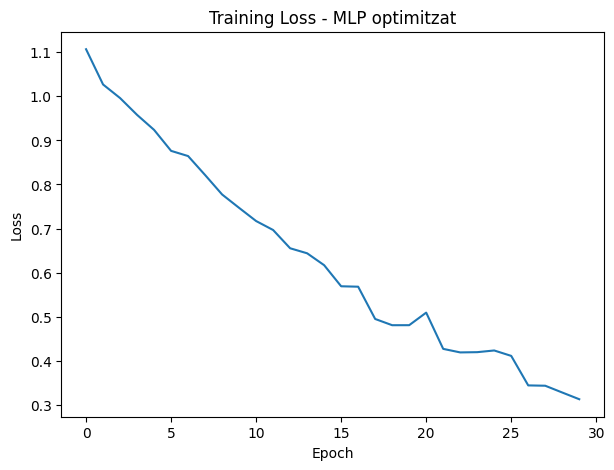

In [56]:
# Training loss

plt.figure(figsize=(7, 5))
plt.plot(loss_history)
plt.title("Training Loss - MLP optimitzat")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

La corba de pèrdua d’entrenament mostra una disminució progressiva de la loss, fet que indica que el model aprèn durant les èpoques d’entrenament. Tot i això, una reducció de la loss en entrenament no garanteix necessàriament una bona generalització, per això l’avaluació final es realitza sobre el conjunt de test.

**Avaluació del model amb threshold 0.5**

Un cop entrenat el model final, s’avalua sobre el conjunt de test. Primer s’obtenen les probabilitats estimades de frau aplicant la funció sigmoid als logits de sortida del model.

Com a primera aproximació, s’utilitza el threshold estàndard de 0.5 per convertir les probabilitats en classes. Aquest resultat servirà com a punt de comparació abans d’ajustar el threshold segons les mètriques de la classe de frau.

In [57]:
# Avaluació del model final

mlp_model.eval()

with torch.no_grad():
    logits = mlp_model(X_test_tensor.to(device))
    probs = torch.sigmoid(logits)
    y_pred_mlp = probs.cpu().numpy().flatten()

roc_auc_mlp = roc_auc_score(y_test, y_pred_mlp)
avg_precision_mlp = average_precision_score(y_test, y_pred_mlp)

print("ROC-AUC MLP:", roc_auc_mlp)
print("Average Precision MLP:", avg_precision_mlp)

y_pred_class_mlp_05 = (y_pred_mlp >= 0.5).astype(int)

print("\nClassification Report threshold 0.5:")
print(classification_report(y_test, y_pred_class_mlp_05))

print("Confusion Matrix threshold 0.5:")
print(confusion_matrix(y_test, y_pred_class_mlp_05))

ROC-AUC MLP: 0.7350514231045204
Average Precision MLP: 0.47589555400583955

Classification Report threshold 0.5:
              precision    recall  f1-score   support

           0       0.87      0.77      0.81       226
           1       0.47      0.64      0.54        74

    accuracy                           0.74       300
   macro avg       0.67      0.70      0.68       300
weighted avg       0.77      0.74      0.75       300

Confusion Matrix threshold 0.5:
[[174  52]
 [ 27  47]]


Amb el threshold estàndard de 0.5, el MLP obté un ROC-AUC aproximat de 0.735 i una Average Precision d’aproximadament 0.476. Aquests valors indiquen que el model té una capacitat discriminativa moderada, però inferior a la de models com Random Forest o XGBoost.

Pel que fa a la classe de frau, el model obté una precision de 0.475, un recall de 0.635 i un F1-score de 0.543. La matriu de confusió mostra que detecta 47 dels 74 casos fraudulents, però genera 52 falsos positius i deixa 27 fraus sense detectar.

Aquest comportament indica que el model és capaç de detectar una part rellevant dels fraus, però ho fa amb una precision baixa. En altres paraules, genera un nombre considerable d’alertes falses.

**Mètriques resum amb threshold 0.5**

A continuació es resumeixen les principals mètriques obtingudes pel MLP amb el threshold estàndard de 0.5. Aquest resum permet comparar posteriorment el comportament inicial del model amb el resultat obtingut després de l’ajust del threshold.

In [58]:
# Mètriques resum threshold 0.5

acc_mlp = accuracy_score(y_test, y_pred_class_mlp_05)
prec_mlp = precision_score(y_test, y_pred_class_mlp_05, zero_division=0)
rec_mlp = recall_score(y_test, y_pred_class_mlp_05)
f1_mlp = f1_score(y_test, y_pred_class_mlp_05)

print("Mètriques MLP threshold 0.5")
print("Accuracy:", acc_mlp)
print("Precision:", prec_mlp)
print("Recall:", rec_mlp)
print("F1-score:", f1_mlp)
print("ROC-AUC:", roc_auc_mlp)
print("Average Precision:", avg_precision_mlp)

Mètriques MLP threshold 0.5
Accuracy: 0.7366666666666667
Precision: 0.47474747474747475
Recall: 0.6351351351351351
F1-score: 0.5433526011560693
ROC-AUC: 0.7350514231045204
Average Precision: 0.47589555400583955


Amb el threshold estàndard de 0.5, el MLP obté un ROC-AUC d’aproximadament 0.735. El model detecta una part rellevant dels casos de frau, però presenta una precision moderada, cosa que indica un nombre apreciable de falsos positius.

Aquest resultat mostra que la xarxa neuronal aprèn cert senyal predictiu, però el seu rendiment encara és inferior al dels models més competitius del treball.

**ROC Curve**

La corba ROC permet visualitzar la capacitat discriminativa global del model independentment del threshold utilitzat. Aquesta gràfica mostra la relació entre la taxa de falsos positius i la taxa de vertaders positius per a diferents punts de tall.


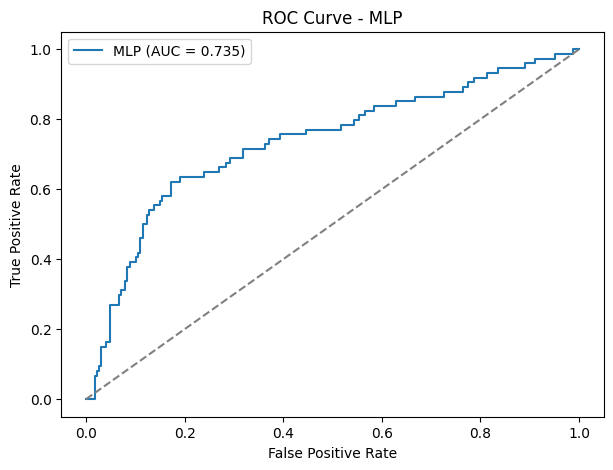

In [59]:
# ROC Curve

fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test, y_pred_mlp)
roc_auc_mlp_curve = auc(fpr_mlp, tpr_mlp)

plt.figure(figsize=(7, 5))
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC = {roc_auc_mlp_curve:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend()
plt.show()

La corba ROC del MLP se situa per sobre de la diagonal aleatòria, fet que indica que el model té capacitat per diferenciar entre casos fraudulents i no fraudulents. Tot i això, el ROC-AUC és inferior al d’altres models black-box analitzats, cosa que suggereix que el MLP no és el model que millor ordena les observacions segons el risc de frau.

**Ajust del threshold**

Després de l’avaluació inicial amb threshold 0.5, s’analitza l’efecte de diferents llindars sobre les mètriques de classificació. Aquesta anàlisi és especialment important en detecció de frau, ja que el threshold determina l’equilibri entre detectar més fraus i generar més falsos positius.

En aquest cas, es busca el threshold que maximitza el F1-score de la classe positiva, mantenint un equilibri entre precision i recall. Tot i això, cal tenir present que en un entorn real el threshold també podria ajustar-se segons el cost econòmic associat als falsos positius i falsos negatius.


In [60]:
# Threshold tuning automàtic

results_threshold_mlp = []

for t in np.arange(0.10, 0.91, 0.01):
    y_pred_t = (y_pred_mlp >= t).astype(int)

    results_threshold_mlp.append({
        "threshold": round(t, 2),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t)
    })

results_threshold_mlp = pd.DataFrame(results_threshold_mlp)

results_threshold_mlp.sort_values(
    ["f1", "recall", "precision"],
    ascending=[False, False, False]
).head(10)

,threshold,accuracy,precision,recall,f1
50,0.60,0.776667,0.541176,0.621622,0.578616
48,0.58,0.760000,0.510870,0.635135,0.566265
56,0.66,0.780000,0.551282,0.581081,0.565789
49,0.59,0.763333,0.516854,0.621622,0.564417
47,0.57,0.756667,0.505376,0.635135,0.562874
58,0.68,0.780000,0.552632,0.567568,0.560000
59,0.69,0.780000,0.552632,0.567568,0.560000
63,0.73,0.790000,0.579710,0.540541,0.559441
64,0.74,0.790000,0.579710,0.540541,0.559441
65,0.75,0.790000,0.579710,0.540541,0.559441


L’ajust del threshold mostra que el millor F1-score s’obté amb un threshold de 0.60, superior al llindar estàndard de 0.5. Això indica que el model assigna probabilitats relativament elevades a alguns casos no fraudulents, i que un threshold més exigent ajuda a reduir els falsos positius.

Amb aquest ajust, el model millora l’accuracy i el F1-score respecte al threshold 0.5, tot i que continua sense superar els models black-box més competitius.

**Model final amb threshold seleccionat**


Un cop identificat el millor threshold segons el F1-score, s’aplica aquest llindar per obtenir les prediccions finals del MLP. Aquest serà el resultat utilitzat en la comparació final entre models.



In [61]:
# Model final amb el millor threshold segons F1, recall i precision

best_threshold_mlp = (
    results_threshold_mlp
    .sort_values(["f1", "recall", "precision"], ascending=[False, False, False])
    .iloc[0]["threshold"]
)

print("Millor threshold MLP:", best_threshold_mlp)

y_pred_mlp_final = (y_pred_mlp >= best_threshold_mlp).astype(int)

print("\nClassification Report MLP final:")
print(classification_report(y_test, y_pred_mlp_final))

print("Confusion Matrix MLP final:")
print(confusion_matrix(y_test, y_pred_mlp_final))

Millor threshold MLP: 0.6

Classification Report MLP final:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       226
           1       0.54      0.62      0.58        74

    accuracy                           0.78       300
   macro avg       0.71      0.72      0.71       300
weighted avg       0.79      0.78      0.78       300

Confusion Matrix MLP final:
[[187  39]
 [ 28  46]]


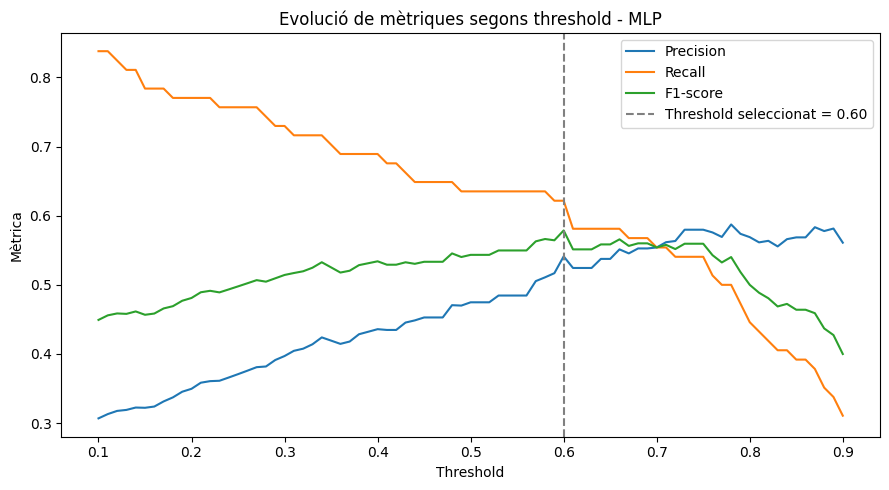

In [62]:
plt.figure(figsize=(9, 5))
plt.plot(results_threshold_mlp["threshold"], results_threshold_mlp["precision"], label="Precision")
plt.plot(results_threshold_mlp["threshold"], results_threshold_mlp["recall"], label="Recall")
plt.plot(results_threshold_mlp["threshold"], results_threshold_mlp["f1"], label="F1-score")

plt.axvline(best_threshold_mlp, color="gray", linestyle="--",
            label=f"Threshold seleccionat = {best_threshold_mlp:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Mètrica")
plt.title("Evolució de mètriques segons threshold - MLP")
plt.legend()
plt.tight_layout()
plt.show()

**Mètriques finals del MLP**

A continuació es calculen les mètriques finals del MLP utilitzant el threshold seleccionat. Aquestes mètriques seran les que s’incorporaran a la taula comparativa final de models.



In [63]:
# Mètriques finals MLP

acc_mlp_final = accuracy_score(y_test, y_pred_mlp_final)
prec_mlp_final = precision_score(y_test, y_pred_mlp_final, zero_division=0)
rec_mlp_final = recall_score(y_test, y_pred_mlp_final)
f1_mlp_final = f1_score(y_test, y_pred_mlp_final)
roc_auc_mlp_final = roc_auc_score(y_test, y_pred_mlp)
avg_precision_mlp_final = average_precision_score(y_test, y_pred_mlp)

print("Mètriques MLP final")
print("Threshold:", best_threshold_mlp)
print("Accuracy:", acc_mlp_final)
print("Precision:", prec_mlp_final)
print("Recall:", rec_mlp_final)
print("F1-score:", f1_mlp_final)
print("ROC-AUC:", roc_auc_mlp_final)
print("Average Precision:", avg_precision_mlp_final)

Mètriques MLP final
Threshold: 0.6
Accuracy: 0.7766666666666666
Precision: 0.5411764705882353
Recall: 0.6216216216216216
F1-score: 0.5786163522012578
ROC-AUC: 0.7350514231045204
Average Precision: 0.47589555400583955


**Taula resum del MLP**

La taula següent resumeix el rendiment final del MLP optimitzat, incloent el threshold seleccionat, les mètriques globals i les mètriques específiques de classificació.


In [64]:
# Taula resum MLP

mlp_summary = pd.DataFrame([{
    "Model": "MLP optimitzat",
    "Threshold": best_threshold_mlp,
    "ROC-AUC": roc_auc_mlp_final,
    "Average Precision": avg_precision_mlp_final,
    "Accuracy": acc_mlp_final,
    "Precision": prec_mlp_final,
    "Recall": rec_mlp_final,
    "F1-score": f1_mlp_final
}])

mlp_summary

,Model,Threshold,ROC-AUC,Average Precision,Accuracy,Precision,Recall,F1-score
0,MLP optimitzat,0.6,0.735051,0.475896,0.776667,0.541176,0.621622,0.578616


El MLP optimitzat aconsegueix un rendiment moderat. Després de l’ajust del threshold, obté una accuracy d’aproximadament 0.777, un recall de frau de 0.622 i un F1-score de 0.579. Aquest resultat millora respecte al threshold estàndard, però queda per sota de models com XGBoost o SVC.

Això suggereix que, tot i la seva flexibilitat, el MLP no és el model més adequat per a aquest dataset concret. El conjunt de dades és relativament petit i tabular, amb moltes variables derivades de one-hot encoding, un context en què les xarxes neuronals no sempre superen models basats en arbres o kernels.

Tot i això, el MLP es manté com a model black-box rellevant dins de la comparació, ja que permet analitzar com un model neuronal aprèn patrons no lineals i com es comporta respecte a altres enfocaments més habituals per dades tabulars.

A diferència dels models basats en arbres o de la regressió logística, el MLP no proporciona una importància de variables directa i fàcilment interpretable. Per aquest motiu, la seva interpretació es reservarà per a les tècniques XAI aplicades posteriorment.

**Guardat del model**

Finalment, es guarden el model entrenat, l’escalador utilitzat i les metadades principals del MLP. Aquest pas permet reutilitzar posteriorment el model sense haver de tornar-lo a entrenar.

Les metadades inclouen el threshold final, l’arquitectura seleccionada, els hiperparàmetres principals i les mètriques finals. Aquesta informació és útil per documentar el model i per aplicar posteriorment tècniques d’explicabilitat.


In [65]:
# Guardar model, escalador i metadades

torch.save(mlp_model.state_dict(), "mlp_model.pth")

joblib.dump(scaler_mlp, "mlp_scaler.pkl")

metadata_mlp = {
    "threshold": float(best_threshold_mlp),
    "input_dim": int(X_train_scaled.shape[1]),
    "feature_names": list(X_train.columns),
    "hidden_dims": list(best_params_mlp["hidden_dims"]),
    "dropout": float(best_params_mlp["dropout"]),
    "lr": float(best_params_mlp["lr"]),
    "weight_decay": float(best_params_mlp["weight_decay"]),
    "batch_size": int(best_params_mlp["batch_size"]),
    "pos_weight_factor": float(best_params_mlp["pos_weight_factor"]),
    "best_epoch": int(best_epoch_mlp),
    "roc_auc": float(roc_auc_mlp_final),
    "average_precision": float(avg_precision_mlp_final),
    "accuracy": float(acc_mlp_final),
    "precision": float(prec_mlp_final),
    "recall": float(rec_mlp_final),
    "f1_score": float(f1_mlp_final)
}

with open("mlp_metadata.json", "w") as f:
    json.dump(metadata_mlp, f, indent=4)

print("Model MLP guardat correctament.")

Model MLP guardat correctament.


**Conclusió del model MLP**

El MLP optimitzat aconsegueix un rendiment moderat en la detecció de frau. Després de l’ajust del threshold, obté un ROC-AUC de 0.735, una Average Precision de 0.476, un recall de 0.622 i un F1-score de 0.579.

Aquest resultat mostra que la xarxa neuronal és capaç d’aprendre patrons no lineals presents en les dades, però no supera els models més adequats per a dades tabulars, com XGBoost o SVC. Una possible explicació és que el dataset és relativament petit i conté moltes variables binàries derivades del one-hot encoding, un context en què les xarxes neuronals poden tenir dificultats per generalitzar millor que models basats en arbres o kernels.

Tot i no ser el model amb millor rendiment, el MLP és rellevant dins de la comparació perquè representa un enfocament neuronal black-box. La seva manca d’interpretabilitat directa reforça la necessitat d’aplicar tècniques XAI en fases posteriors per entendre quines variables influeixen en les prediccions.


## 5.4. SVC amb kernel gaussià

En aquest apartat s’entrena un Support Vector Classifier amb kernel gaussià, també anomenat kernel RBF. Aquest model permet construir fronteres de decisió no lineals projectant les dades en un espai de major dimensionalitat de manera implícita mitjançant el kernel.

L’SVC amb kernel RBF és especialment útil quan la relació entre les variables i la classe objectiu no és lineal. En el context de la detecció de frau, això pot ser rellevant perquè els patrons fraudulents poden dependre de combinacions complexes de variables relacionades amb el sinistre, la pòlissa, el client i els imports reclamats.

Tot i la seva capacitat predictiva, l’SVC amb kernel RBF es considera un model black-box, ja que la seva frontera de decisió no és fàcilment interpretable de manera directa. A diferència de la regressió logística, no proporciona coeficients directament interpretables, i a diferència dels models basats en arbres, no ofereix una importància de variables immediata. Per aquest motiu, si el seu rendiment és competitiu, serà un bon candidat per aplicar tècniques d’explicabilitat com SHAP i Anchors.

In [66]:
# 5.4 SVC amb kernel gaussià optimitzat

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from scipy.stats import loguniform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Definició del pipeline**

L’SVC és un model sensible a l’escala de les variables, ja que la seva frontera de decisió depèn de distàncies entre observacions. Per aquest motiu, es construeix un `Pipeline` que aplica primer `StandardScaler` i després entrena el model SVC.

L’ús del pipeline és important perquè garanteix que l’escalat es faci correctament dins de cada partició de la validació creuada, evitant fugues d’informació entre train i validació.

El model s’entrena amb kernel RBF, `class_weight="balanced"` i `probability=True`. El pes balancejat compensa el desbalanceig entre classes, donant més importància als casos de frau. L’opció `probability=True` permet obtenir probabilitats estimades de frau, necessàries per calcular mètriques com ROC-AUC, Average Precision i per ajustar posteriorment el threshold de classificació.

In [67]:
svc_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

**Espai d’hiperparàmetres**

L’SVC amb kernel RBF depèn principalment de dos hiperparàmetres: `C` i `gamma`.

El paràmetre `C` controla el compromís entre maximitzar el marge i penalitzar els errors de classificació. Valors més alts de `C` permeten fronteres de decisió més ajustades a les dades, mentre que valors més baixos afavoreixen una frontera més regularitzada.

El paràmetre `gamma` controla la influència de cada observació en el kernel RBF. Valors alts de `gamma` poden generar fronteres molt locals i complexes, mentre que valors baixos produeixen fronteres més suaus i generals.

Com que aquests paràmetres poden variar en diferents ordres de magnitud, s’exploren mitjançant distribucions logarítmiques.


In [68]:
param_dist_svc = {
    "model__C": loguniform(0.1, 300),
    "model__gamma": loguniform(1e-4, 1e-1)
}

**Optimització amb RandomizedSearchCV**

Per seleccionar la millor configuració de l’SVC, s’utilitza `RandomizedSearchCV` amb validació creuada estratificada de 5 particions. L’estratificació garanteix que cada fold mantingui una proporció similar de casos fraudulents i no fraudulents, fet especialment important perquè la classe de frau és minoritària.

La cerca s’orienta a maximitzar l’Average Precision, una mètrica especialment adequada en problemes desbalancejats. Aquesta mètrica resumeix el comportament de la corba precision-recall i dona més informació sobre la capacitat del model per identificar correctament la classe positiva.

En total s’avaluen 120 combinacions aleatòries d’hiperparàmetres, cosa que permet explorar un espai ampli de configuracions sense el cost computacional d’una cerca exhaustiva.


In [69]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_svc = RandomizedSearchCV(
    estimator=svc_pipe,
    param_distributions=param_dist_svc,
    n_iter=120,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_svc.fit(X_train, y_train)

best_svc = random_svc.best_estimator_

print("Millors paràmetres SVC:")
print(random_svc.best_params_)

print("\nMillor CV Average Precision SVC:")
print(random_svc.best_score_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Millors paràmetres SVC:
{'model__C': 17.512333632170865, 'model__gamma': 0.000333502648356996}

Millor CV Average Precision SVC:
0.5038947836445089


La millor configuració seleccionada utilitza un valor de `C` aproximadament igual a 17.51 i un valor de `gamma` aproximadament igual a 0.00033. Aquest resultat indica que el model selecciona una penalització relativament elevada dels errors, però amb un valor de `gamma` baix, que produeix una frontera de decisió més suau.

El millor Average Precision obtingut en validació creuada és aproximadament 0.504. Aquest valor serveix com a referència interna de la cerca d’hiperparàmetres. Posteriorment, el model seleccionat s’avalua sobre el conjunt de test per obtenir una estimació final del rendiment.

**Avaluació amb threshold 0.5**

Un cop seleccionat el millor model, s’obtenen les probabilitats estimades de frau sobre el conjunt de test. Aquestes probabilitats permeten calcular mètriques independents del threshold, com el ROC-AUC i l’Average Precision.

Com a primera avaluació, s’utilitza el threshold estàndard de 0.5 per convertir les probabilitats en classes. Aquest resultat permet veure el comportament inicial del model abans d’ajustar el punt de tall segons les necessitats del problema de detecció de frau.


In [70]:
# Predicció de probabilitats
y_pred_proba_svc = best_svc.predict_proba(X_test)[:, 1]

roc_auc_svc = roc_auc_score(y_test, y_pred_proba_svc)
avg_precision_svc = average_precision_score(y_test, y_pred_proba_svc)

print("ROC-AUC SVC:", roc_auc_svc)
print("Average Precision SVC:", avg_precision_svc)

# Predicció amb threshold 0.5
y_pred_svc_05 = (y_pred_proba_svc >= 0.5).astype(int)

print("\nClassification Report threshold 0.5:")
print(classification_report(y_test, y_pred_svc_05))

print("Confusion Matrix threshold 0.5:")
print(confusion_matrix(y_test, y_pred_svc_05))

ROC-AUC SVC: 0.7656661085864624
Average Precision SVC: 0.5817828061093724

Classification Report threshold 0.5:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87       226
           1       0.64      0.34      0.44        74

    accuracy                           0.79       300
   macro avg       0.73      0.64      0.66       300
weighted avg       0.77      0.79      0.77       300

Confusion Matrix threshold 0.5:
[[212  14]
 [ 49  25]]


Amb el threshold estàndard de 0.5, l’SVC obté un ROC-AUC aproximat de 0.766 i una Average Precision aproximada de 0.582. Aquests valors són competitius respecte a la resta de models i indiquen que el model ordena força bé les observacions segons el risc estimat de frau.

Tot i això, el comportament de classificació amb threshold 0.5 no és adequat per a l’objectiu del problema. El recall de la classe de frau és només de 0.338, cosa que significa que el model detecta 25 dels 74 casos fraudulents i deixa sense detectar 49 fraus.

La precision és de 0.641, fet que indica que quan el model prediu frau, sovint encerta. No obstant això, és massa conservador i classifica molts casos fraudulents com a no frau. En un problema de detecció de frau, aquest comportament és problemàtic perquè els falsos negatius tenen un cost especialment rellevant.

**Mètriques resum amb threshold 0.5**


A continuació es calculen les mètriques principals del model utilitzant el threshold estàndard de 0.5. Aquest resum permet comparar el comportament inicial de l’SVC amb el resultat obtingut després de l’ajust del threshold.


In [71]:
acc_svc = accuracy_score(y_test, y_pred_svc_05)
prec_svc = precision_score(y_test, y_pred_svc_05, zero_division=0)
rec_svc = recall_score(y_test, y_pred_svc_05)
f1_svc = f1_score(y_test, y_pred_svc_05)

print("Mètriques SVC threshold 0.5")
print("Accuracy:", acc_svc)
print("Precision:", prec_svc)
print("Recall:", rec_svc)
print("F1-score:", f1_svc)
print("ROC-AUC:", roc_auc_svc)
print("Average Precision:", avg_precision_svc)

Mètriques SVC threshold 0.5
Accuracy: 0.79
Precision: 0.6410256410256411
Recall: 0.33783783783783783
F1-score: 0.4424778761061947
ROC-AUC: 0.7656661085864624
Average Precision: 0.5817828061093724


**Taula resum amb threshold 0.5**

La taula següent resumeix el rendiment inicial de l’SVC amb threshold 0.5. Tot i que les mètriques globals són bones, el recall de la classe positiva mostra que el llindar estàndard no és l’opció més adequada per a aquest problema.

In [72]:
svc_metrics_05 = pd.DataFrame([{
    "Threshold": 0.5,
    "ROC-AUC": roc_auc_svc,
    "Average Precision": avg_precision_svc,
    "Accuracy": acc_svc,
    "Precision": prec_svc,
    "Recall": rec_svc,
    "F1-score": f1_svc
}]).round(3)

svc_metrics_05

,Threshold,ROC-AUC,Average Precision,Accuracy,Precision,Recall,F1-score
0,0.5,0.766,0.582,0.79,0.641,0.338,0.442


Amb el threshold estàndard de 0.5, l’SVC presenta una accuracy de 0.790 i una precision de 0.641, però el recall de frau és baix. Aquest resultat mostra que el model és capaç d’identificar correctament una part dels casos que marca com a frau, però no és prou sensible per detectar una proporció elevada dels fraus reals.

Aquest comportament reforça la idea que, en detecció de frau, no és suficient avaluar només mètriques globals o utilitzar el threshold per defecte. Cal adaptar el punt de tall per reduir els falsos negatius i millorar la utilitat pràctica del model.

**ROC curve**

La corba ROC permet visualitzar la capacitat discriminativa global del model per a diferents thresholds. Aquesta gràfica mostra la relació entre la taxa de falsos positius i la taxa de vertaders positius.


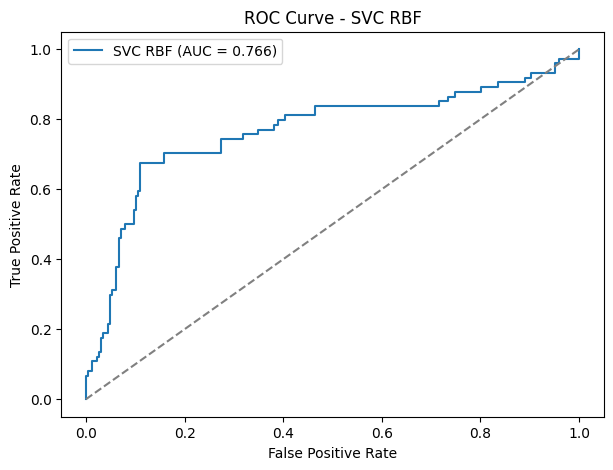

In [73]:
fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_pred_proba_svc)
roc_auc_svc_curve = auc(fpr_svc, tpr_svc)

plt.figure(figsize=(7, 5))
plt.plot(fpr_svc, tpr_svc, label=f"SVC RBF (AUC = {roc_auc_svc_curve:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVC RBF")
plt.legend()
plt.show()

La corba ROC de l’SVC se situa clarament per sobre de la diagonal aleatòria, fet que indica una bona capacitat per distingir entre reclamacions fraudulentes i no fraudulentes. El valor de ROC-AUC, aproximadament 0.766, confirma que el model té una capacitat discriminativa competitiva.

Tot i això, la corba ROC no indica quin threshold és més adequat per al problema. En aquest cas, el threshold estàndard de 0.5 genera un recall massa baix per a la classe de frau, per la qual cosa és necessari analitzar altres punts de tall.

**Ajust del threshold automàtic**

Després d’avaluar el model amb threshold 0.5, s’analitza l’efecte de diferents thresholds sobre les mètriques de classificació. Aquesta anàlisi és especialment important perquè l’SVC presenta bones mètriques globals, però un recall insuficient amb el llindar estàndard.

L’objectiu és trobar un threshold que millori l’equilibri entre precision i recall per a la classe de frau. En aquest treball, el criteri utilitzat és maximitzar el F1-score, ja que aquesta mètrica resumeix el compromís entre detectar fraus i controlar el nombre de falsos positius.

Cal tenir en compte que, metodològicament, la selecció del threshold s’hauria de fer idealment sobre un conjunt de validació o mitjançant validació creuada. En aquest notebook, l’anàlisi sobre el conjunt de test s’utilitza com a aproximació empírica per estudiar el comportament del model.




In [74]:
# Threshold tuning automàtic per SVC

threshold_results_svc = []

for threshold in np.arange(0.10, 0.91, 0.01):
    y_pred_t = (y_pred_proba_svc >= threshold).astype(int)

    threshold_results_svc.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t)
    })

threshold_results_svc = pd.DataFrame(threshold_results_svc)

threshold_results_svc_sorted = (
    threshold_results_svc
    .sort_values(["f1", "recall", "precision"], ascending=[False, False, False])
    .round(3)
)

threshold_results_svc_sorted.head(10)

,threshold,accuracy,precision,recall,f1
24,0.34,0.830,0.649,0.676,0.662
25,0.35,0.830,0.649,0.676,0.662
26,0.36,0.833,0.662,0.662,0.662
23,0.33,0.827,0.641,0.676,0.658
22,0.32,0.823,0.633,0.676,0.654
21,0.31,0.820,0.625,0.676,0.649
20,0.30,0.817,0.617,0.676,0.645
17,0.27,0.813,0.610,0.676,0.641
18,0.28,0.813,0.610,0.676,0.641
19,0.29,0.813,0.610,0.676,0.641


L’anàlisi de thresholds mostra que el rendiment de l’SVC millora clarament quan es redueix el llindar respecte al valor estàndard de 0.5. El millor F1-score s’obté amb un threshold aproximat de 0.34.

Amb aquest llindar, el model augmenta substancialment el recall de la classe de frau mantenint una precision competitiva. Això significa que el model detecta molts més fraus sense generar un volum excessiu de falsos positius.

Aquest ajust és especialment rellevant en detecció de frau, ja que el cost de no detectar una reclamació fraudulenta pot ser més elevat que el cost de revisar una reclamació no fraudulenta marcada com a sospitosa.

**Model final amb threshold seleccionat**

Un cop analitzats els diferents thresholds, se selecciona el llindar que maximitza el F1-score de la classe positiva. Aquest threshold s’utilitza per obtenir les prediccions finals de l’SVC.

En aquest cas, el threshold seleccionat és 0.34, inferior al valor estàndard de 0.5. Aquesta reducció fa que el model sigui menys conservador i classifiqui més observacions com a possibles fraus.



In [75]:
# Selecció del millor threshold segons F1-score, recall i precision

best_threshold_svc = (
    threshold_results_svc
    .sort_values(["f1", "recall", "precision"], ascending=[False, False, False])
    .iloc[0]["threshold"]
)

print("Millor threshold SVC:", best_threshold_svc)

y_pred_svc_final = (y_pred_proba_svc >= best_threshold_svc).astype(int)

print("\nClassification Report SVC final:")
print(classification_report(y_test, y_pred_svc_final))

print("Confusion Matrix SVC final:")
print(confusion_matrix(y_test, y_pred_svc_final))

Millor threshold SVC: 0.34

Classification Report SVC final:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       226
           1       0.65      0.68      0.66        74

    accuracy                           0.83       300
   macro avg       0.77      0.78      0.77       300
weighted avg       0.83      0.83      0.83       300

Confusion Matrix SVC final:
[[199  27]
 [ 24  50]]


Amb el threshold final de 0.34, l’SVC millora clarament el seu comportament en la detecció de frau. El model detecta 50 dels 74 casos fraudulents del conjunt de test i deixa sense detectar 24 fraus. Al mateix temps, genera 27 falsos positius.

Aquest resultat representa un equilibri molt més adequat que el threshold 0.5. El recall augmenta de 0.338 a 0.676, mentre que la precision es manté en un valor competitiu de 0.649. Això indica que el model aconsegueix detectar molts més fraus sense perdre excessiva precisió.

En el context d’aquest treball, aquest comportament és especialment interessant perquè redueix els falsos negatius, que són els errors més crítics en detecció de frau.

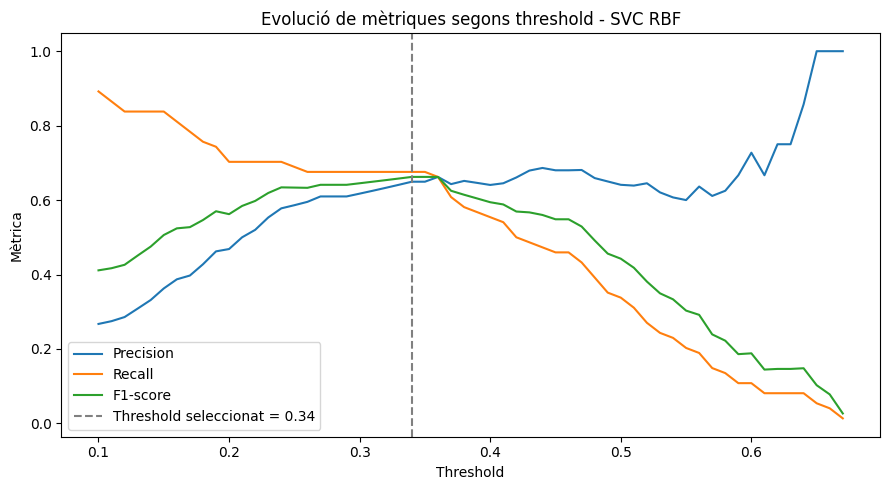

In [76]:
plt.figure(figsize=(9, 5))

mask = threshold_results_svc["precision"] > 0.05
plt.plot(
    threshold_results_svc.loc[mask, "threshold"],
    threshold_results_svc.loc[mask, "precision"],
    label="Precision"
)

plt.plot(
    threshold_results_svc.loc[mask, "threshold"],
    threshold_results_svc.loc[mask, "recall"],
    label="Recall"
)

plt.plot(
    threshold_results_svc.loc[mask, "threshold"],
    threshold_results_svc.loc[mask, "f1"],
    label="F1-score"
)

plt.axvline(
    best_threshold_svc,
    color="gray",
    linestyle="--",
    label=f"Threshold seleccionat = {best_threshold_svc:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Mètrica")
plt.title("Evolució de mètriques segons threshold - SVC RBF")

plt.legend()
plt.tight_layout()
plt.show()

**Mètriques finals de l’SVC**

A continuació es calculen les mètriques finals de l’SVC utilitzant el threshold seleccionat. Aquestes mètriques seran les que s’incorporaran a la comparació final entre models.


In [77]:
acc_svc_final = accuracy_score(y_test, y_pred_svc_final)
prec_svc_final = precision_score(y_test, y_pred_svc_final, zero_division=0)
rec_svc_final = recall_score(y_test, y_pred_svc_final)
f1_svc_final = f1_score(y_test, y_pred_svc_final)
roc_auc_svc_final = roc_auc_score(y_test, y_pred_proba_svc)
avg_precision_svc_final = average_precision_score(y_test, y_pred_proba_svc)

svc_summary = pd.DataFrame([{
    "Model": "SVC RBF optimitzat",
    "Threshold": best_threshold_svc,
    "ROC-AUC": roc_auc_svc_final,
    "Average Precision": avg_precision_svc_final,
    "Accuracy": acc_svc_final,
    "Precision": prec_svc_final,
    "Recall": rec_svc_final,
    "F1-score": f1_svc_final
}]).round(3)

svc_summary

,Model,Threshold,ROC-AUC,Average Precision,Accuracy,Precision,Recall,F1-score
0,SVC RBF optimitzat,0.34,0.766,0.582,0.83,0.649,0.676,0.662


In [78]:
print("Mètriques SVC final")
print("Threshold:", round(best_threshold_svc, 2))
print("Accuracy:", round(acc_svc_final, 3))
print("Precision:", round(prec_svc_final, 3))
print("Recall:", round(rec_svc_final, 3))
print("F1-score:", round(f1_svc_final, 3))
print("ROC-AUC:", round(roc_auc_svc_final, 3))
print("Average Precision:", round(avg_precision_svc_final, 3))

Mètriques SVC final
Threshold: 0.34
Accuracy: 0.83
Precision: 0.649
Recall: 0.676
F1-score: 0.662
ROC-AUC: 0.766
Average Precision: 0.582


Amb el threshold final de 0.34, l’SVC obté una accuracy de 0.830, una precision de 0.649, un recall de 0.676 i un F1-score de 0.662. També manté un ROC-AUC de 0.766 i una Average Precision de 0.582.

Aquest resultat situa l’SVC com un dels models més competitius del treball. En particular, destaca pel seu equilibri entre precision i recall en la classe de frau. A més, presenta l’Average Precision més alta entre els models analitzats fins aquest punt, fet especialment rellevant en un problema amb classe positiva minoritària.

La millora respecte al threshold 0.5 mostra que el model tenia bona capacitat per ordenar els casos segons risc, però necessitava un llindar més adequat per convertir aquestes probabilitats en decisions útils.

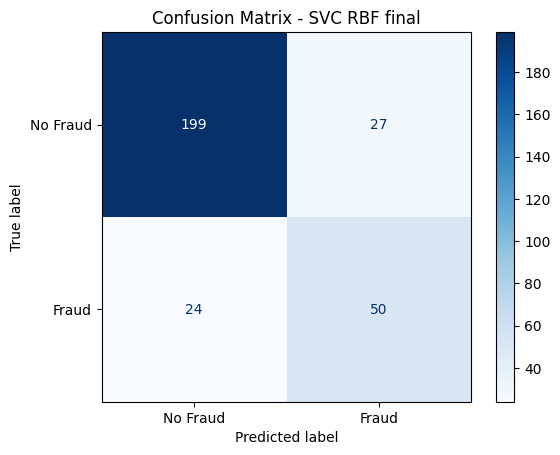

In [79]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_svc = confusion_matrix(y_test, y_pred_svc_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svc,
    display_labels=["No Fraud", "Fraud"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - SVC RBF final")
plt.show()

**Conclusió del model SVC**

L’SVC amb kernel RBF és el model que obté el millor equilibri global entre precision i recall per a la classe de frau. Amb el threshold final de 0.34, aconsegueix una accuracy d’aproximadament 0.830, una precision de 0.649, un recall de 0.676 i un F1-score de 0.662.

Aquest resultat indica que l’SVC és capaç de detectar una proporció important dels casos fraudulents sense generar un volum excessiu de falsos positius. En concret, detecta 50 dels 74 fraus del conjunt de test i redueix de manera clara els falsos negatius respecte al threshold estàndard.

A més, l’SVC presenta l’Average Precision més alta entre els models analitzats fins ara, fet especialment rellevant en un problema amb classe positiva minoritària. Aquest comportament confirma que el model és especialment competitiu per ordenar els casos segons el risc estimat de frau.

Tot i aquest bon rendiment, l’SVC amb kernel RBF és poc interpretable de manera directa. La seva frontera de decisió depèn del kernel i dels vectors de suport, cosa que dificulta entendre quines variables concretes expliquen cada predicció. Per aquest motiu, és un candidat especialment interessant per a l’aplicació posterior de tècniques XAI com SHAP i Anchors.

Finalment, cal tenir en compte que les probabilitats de l’SVC provenen d’una calibració interna del model. Per això, el threshold final s’ha d’interpretar com un punt de tall empíric ajustat al comportament observat del model.


## 6. Comparació de models

En aquest apartat es comparen tots els models entrenats, tant els baseline com els models black-box, utilitzant diverses mètriques de classificació sobre el conjunt de test. L’objectiu és identificar quin model ofereix el millor equilibri entre capacitat discriminativa global i detecció efectiva dels casos de frau.

Atès que en alguns models s’ha ajustat el llindar de classificació, les mètriques finals es calculen sobre la configuració seleccionada en cada cas. En canvi, el ROC-AUC es manté com una mesura global independent del llindar i permet comparar de manera homogènia la capacitat discriminativa dels models.

**Guardar mètriques finals**

In [80]:
# Recalcular mètriques finals de tots els models

# Logistic Regression baseline
acc_log_base = accuracy_score(y_test, y_pred_class_bal)
prec_log_base = precision_score(y_test, y_pred_class_bal, zero_division=0)
rec_log_base = recall_score(y_test, y_pred_class_bal)
f1_log_base = f1_score(y_test, y_pred_class_bal)
roc_auc_log_base = roc_auc_score(y_test, y_pred_proba_bal)
avg_precision_log_base = average_precision_score(y_test, y_pred_proba_bal)

# Decision Tree
acc_dt = accuracy_score(y_test, y_pred_dt_class)
prec_dt = precision_score(y_test, y_pred_dt_class, zero_division=0)
rec_dt = recall_score(y_test, y_pred_dt_class)
f1_dt = f1_score(y_test, y_pred_dt_class)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
avg_precision_dt = average_precision_score(y_test, y_pred_proba_dt)

# Random Forest final
acc_rf_final = accuracy_score(y_test, y_pred_rf_final)
prec_rf_final = precision_score(y_test, y_pred_rf_final, zero_division=0)
rec_rf_final = recall_score(y_test, y_pred_rf_final)
f1_rf_final = f1_score(y_test, y_pred_rf_final)
roc_auc_rf_final = roc_auc_score(y_test, y_pred_proba_rf)
avg_precision_rf_final = average_precision_score(y_test, y_pred_proba_rf)

# XGBoost final
acc_xgb_final = accuracy_score(y_test, y_pred_xgb_final)
prec_xgb_final = precision_score(y_test, y_pred_xgb_final, zero_division=0)
rec_xgb_final = recall_score(y_test, y_pred_xgb_final)
f1_xgb_final = f1_score(y_test, y_pred_xgb_final)
roc_auc_xgb_final = roc_auc_score(y_test, y_pred_proba_xgb)
avg_precision_xgb_final = average_precision_score(y_test, y_pred_proba_xgb)

# MLP final
acc_mlp_final = accuracy_score(y_test, y_pred_mlp_final)
prec_mlp_final = precision_score(y_test, y_pred_mlp_final, zero_division=0)
rec_mlp_final = recall_score(y_test, y_pred_mlp_final)
f1_mlp_final = f1_score(y_test, y_pred_mlp_final)
roc_auc_mlp_final = roc_auc_score(y_test, y_pred_mlp)
avg_precision_mlp_final = average_precision_score(y_test, y_pred_mlp)

# SVC final
acc_svc_final = accuracy_score(y_test, y_pred_svc_final)
prec_svc_final = precision_score(y_test, y_pred_svc_final, zero_division=0)
rec_svc_final = recall_score(y_test, y_pred_svc_final)
f1_svc_final = f1_score(y_test, y_pred_svc_final)
roc_auc_svc_final = roc_auc_score(y_test, y_pred_proba_svc)
avg_precision_svc_final = average_precision_score(y_test, y_pred_proba_svc)


**Taula comparativa de mètriques**

Per facilitar la comparació, es resumeixen en una mateixa taula les principals mètriques obtingudes per cada model: ROC-AUC, accuracy, precision, recall i F1-score.

In [81]:
from sklearn.metrics import average_precision_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "MLP",
        "SVC (RBF)"
    ],
    "Type": [
        "Baseline",
        "Baseline",
        "Black-box",
        "Black-box",
        "Black-box",
        "Black-box"
    ],
    "Threshold": [
        0.50,
        0.50,
        best_threshold_rf,
        best_threshold_xgb,
        best_threshold_mlp,
        best_threshold_svc
    ],
    "ROC-AUC": [
        roc_auc_log_base,
        roc_auc_dt,
        roc_auc_rf_final,
        roc_auc_xgb_final,
        roc_auc_mlp_final,
        roc_auc_svc_final
    ],
    "Average Precision": [
        avg_precision_log_base,
        avg_precision_dt,
        avg_precision_rf_final,
        avg_precision_xgb_final,
        avg_precision_mlp_final,
        avg_precision_svc_final
    ],
    "Accuracy": [
        acc_log_base,
        acc_dt,
        acc_rf_final,
        acc_xgb_final,
        acc_mlp_final,
        acc_svc_final
    ],
    "Precision": [
        prec_log_base,
        prec_dt,
        prec_rf_final,
        prec_xgb_final,
        prec_mlp_final,
        prec_svc_final
    ],
    "Recall": [
        rec_log_base,
        rec_dt,
        rec_rf_final,
        rec_xgb_final,
        rec_mlp_final,
        rec_svc_final
    ],
    "F1-score": [
        f1_log_base,
        f1_dt,
        f1_rf_final,
        f1_xgb_final,
        f1_mlp_final,
        f1_svc_final
    ]
})

results = results.sort_values("F1-score", ascending=False).round(3)
results

,Model,Type,Threshold,ROC-AUC,Average Precision,Accuracy,Precision,Recall,F1-score
5,SVC (RBF),Black-box,0.34,0.766,0.582,0.830,0.649,0.676,0.662
3,XGBoost,Black-box,0.50,0.758,0.535,0.813,0.610,0.676,0.641
2,Random Forest,Black-box,0.33,0.772,0.509,0.773,0.534,0.635,0.580
4,MLP,Black-box,0.60,0.735,0.476,0.777,0.541,0.622,0.579
0,Logistic Regression,Baseline,0.50,0.750,0.520,0.760,0.511,0.649,0.571
1,Decision Tree,Baseline,0.50,0.701,0.457,0.750,0.495,0.662,0.566


La taula mostra que el rendiment dels models varia segons la mètrica considerada. Random Forest obté el ROC-AUC més alt, fet que indica una bona capacitat global per ordenar les observacions segons el risc de frau. Tot i això, quan s’analitzen mètriques dependents del threshold, com precision, recall i F1-score, els millors resultats corresponen a SVC amb kernel RBF i XGBoost.

Aquesta diferència és rellevant perquè, en detecció de frau, el ROC-AUC no és suficient per seleccionar el model final. Aquesta mètrica avalua la capacitat discriminativa global, però no reflecteix directament quants fraus es detecten ni quin volum de falsos positius es genera amb un threshold concret. Per aquest motiu, en aquest treball es dona més pes al F1-score, al recall i a l’Average Precision de la classe fraudulenta.

### 6.1. Anàlisi precision-recall de la classe minoritària

Com que la classe d’interès és el frau, l’avaluació no es pot basar només en ROC-AUC. El ROC-AUC mesura la capacitat global del model per ordenar les observacions segons el risc, però no indica directament quants fraus es detecten ni quantes alertes generades són realment fraudulentes.

Per aquest motiu, s’analitzen específicament precision, recall i F1-score de la classe minoritària. El recall indica la proporció de fraus reals detectats pel model. La precision indica quina proporció de les alertes de frau són correctes. El F1-score resumeix l’equilibri entre totes dues.

En un context assegurador, prioritzar recall pot tenir sentit econòmic: deixar escapar un frau pot implicar assumir un cost indegut per part de la companyia. En canvi, un fals positiu normalment implica una revisió addicional per part d’un analista. Tot i que aquesta revisió té un cost operatiu, acostuma a ser preferible revisar alguns casos legítims abans que deixar passar reclamacions fraudulentes. Per aquest motiu, en aquest treball es dona especial importància al recall, mantenint alhora una precision raonable per no generar un volum excessiu de falses alarmes.

In [82]:
minority_results = results[[
    "Model",
    "Type",
    "Threshold",
    "Precision",
    "Recall",
    "F1-score",
    "Average Precision"
]].copy()

minority_results = minority_results.sort_values(
    "F1-score",
    ascending=False
).round(3)

minority_results

,Model,Type,Threshold,Precision,Recall,F1-score,Average Precision
5,SVC (RBF),Black-box,0.34,0.649,0.676,0.662,0.582
3,XGBoost,Black-box,0.50,0.610,0.676,0.641,0.535
2,Random Forest,Black-box,0.33,0.534,0.635,0.580,0.509
4,MLP,Black-box,0.60,0.541,0.622,0.579,0.476
0,Logistic Regression,Baseline,0.50,0.511,0.649,0.571,0.520
1,Decision Tree,Baseline,0.50,0.495,0.662,0.566,0.457


**Gràfic Precision-Recall**

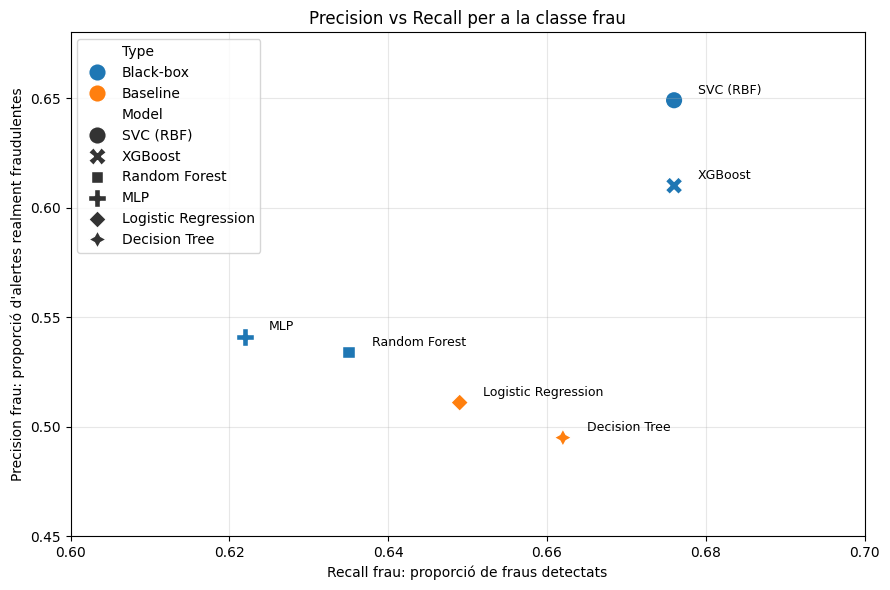

In [83]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=minority_results,
    x="Recall",
    y="Precision",
    hue="Type",
    style="Model",
    s=160
)

for _, row in minority_results.iterrows():
    plt.text(
        row["Recall"] + 0.003,
        row["Precision"] + 0.003,
        row["Model"],
        fontsize=9
    )

plt.title("Precision vs Recall per a la classe frau")
plt.xlabel("Recall frau: proporció de fraus detectats")
plt.ylabel("Precision frau: proporció d'alertes realment fraudulentes")

# Zoom perquè els models no quedin solapats visualment
plt.xlim(0.60, 0.70)
plt.ylim(0.45, 0.68)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El gràfic precision-recall confirma que SVC i XGBoost ofereixen el millor compromís sobre la classe de frau. Tots dos models mantenen un recall elevat, és a dir, detecten una proporció important dels casos fraudulents, però amb una precision superior a la dels models baseline. Això implica que generen alertes de frau més fiables i redueixen el nombre de falsos positius respecte als models més simples.

La regressió logística i l’arbre de decisió també aconsegueixen detectar una part rellevant dels fraus, però ho fan amb una precision més baixa. Per tant, tot i ser models més interpretables, el seu ús pràctic implicaria revisar més casos legítims marcats erròniament com a fraudulents.

### 6.2 Trade-Off Operatiu Segons Threshold

In [84]:
# Alternatives de threshold per XGBoost segons objectiu operatiu

xgb_threshold_tradeoff = threshold_results_xgb.copy()

# Opció A: maximitzar recall mantenint precision >= 0.55
xgb_high_recall = (
    xgb_threshold_tradeoff[xgb_threshold_tradeoff["precision"] >= 0.55]
    .sort_values(["recall", "f1"], ascending=[False, False])
    .head(10)
    .round(3)
)

xgb_high_recall

,threshold,accuracy,precision,recall,f1
40,0.50,0.813,0.610,0.676,0.641
41,0.51,0.813,0.610,0.676,0.641
39,0.49,0.807,0.595,0.676,0.633
38,0.48,0.803,0.588,0.676,0.629
36,0.46,0.800,0.581,0.676,0.625
37,0.47,0.800,0.581,0.676,0.625
49,0.59,0.820,0.632,0.649,0.640
50,0.60,0.820,0.632,0.649,0.640
45,0.55,0.813,0.615,0.649,0.632
46,0.56,0.813,0.615,0.649,0.632


In [85]:
# Opció B: maximitzar precision mantenint recall >= 0.60
xgb_high_precision = (
    xgb_threshold_tradeoff[xgb_threshold_tradeoff["recall"] >= 0.60]
    .sort_values(["precision", "f1"], ascending=[False, False])
    .head(10)
    .round(3)
)

xgb_high_precision

,threshold,accuracy,precision,recall,f1
49,0.59,0.820,0.632,0.649,0.640
50,0.60,0.820,0.632,0.649,0.640
51,0.61,0.817,0.627,0.635,0.631
45,0.55,0.813,0.615,0.649,0.632
46,0.56,0.813,0.615,0.649,0.632
47,0.57,0.813,0.615,0.649,0.632
48,0.58,0.813,0.615,0.649,0.632
40,0.50,0.813,0.610,0.676,0.641
41,0.51,0.813,0.610,0.676,0.641
43,0.53,0.810,0.608,0.649,0.627


In [86]:
# Alternatives de threshold per SVC segons objectiu operatiu

svc_threshold_tradeoff = threshold_results_svc.copy()

# Opció A: maximitzar recall mantenint precision >= 0.55
svc_high_recall = (
    svc_threshold_tradeoff[svc_threshold_tradeoff["precision"] >= 0.55]
    .sort_values(["recall", "f1"], ascending=[False, False])
    .head(10)
    .round(3)
)

svc_high_recall

,threshold,accuracy,precision,recall,f1
14,0.24,0.800,0.578,0.703,0.634
13,0.23,0.787,0.553,0.703,0.619
15,0.25,0.803,0.586,0.689,0.634
24,0.34,0.830,0.649,0.676,0.662
25,0.35,0.830,0.649,0.676,0.662
23,0.33,0.827,0.641,0.676,0.658
22,0.32,0.823,0.633,0.676,0.654
21,0.31,0.820,0.625,0.676,0.649
20,0.30,0.817,0.617,0.676,0.645
17,0.27,0.813,0.610,0.676,0.641


In [87]:
# Opció B: maximitzar precision mantenint recall >= 0.60
svc_high_precision = (
    svc_threshold_tradeoff[svc_threshold_tradeoff["recall"] >= 0.60]
    .sort_values(["precision", "f1"], ascending=[False, False])
    .head(10)
    .round(3)
)

svc_high_precision

,threshold,accuracy,precision,recall,f1
26,0.36,0.833,0.662,0.662,0.662
24,0.34,0.830,0.649,0.676,0.662
25,0.35,0.830,0.649,0.676,0.662
27,0.37,0.820,0.643,0.608,0.625
23,0.33,0.827,0.641,0.676,0.658
22,0.32,0.823,0.633,0.676,0.654
21,0.31,0.820,0.625,0.676,0.649
20,0.30,0.817,0.617,0.676,0.645
17,0.27,0.813,0.610,0.676,0.641
18,0.28,0.813,0.610,0.676,0.641


In [88]:
# Comparació de thresholds alternatius per als dos millors black-box
threshold_scenarios = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Scenario": "Balanced",
        "Threshold": 0.50,
        "Precision": 0.610,
        "Recall": 0.676,
        "F1-score": 0.641
    },
    {
        "Model": "XGBoost",
        "Scenario": "Higher precision",
        "Threshold": 0.59,
        "Precision": 0.632,
        "Recall": 0.649,
        "F1-score": 0.640
    },
    {
        "Model": "SVC",
        "Scenario": "Higher recall",
        "Threshold": 0.24,
        "Precision": 0.578,
        "Recall": 0.703,
        "F1-score": 0.634
    },
    {
        "Model": "SVC",
        "Scenario": "Balanced",
        "Threshold": 0.34,
        "Precision": 0.649,
        "Recall": 0.676,
        "F1-score": 0.662
    },
    {
        "Model": "SVC",
        "Scenario": "Higher precision",
        "Threshold": 0.36,
        "Precision": 0.662,
        "Recall": 0.662,
        "F1-score": 0.662
    }
]).round(3)

threshold_scenarios

,Model,Scenario,Threshold,Precision,Recall,F1-score
0,XGBoost,Balanced,0.50,0.610,0.676,0.641
1,XGBoost,Higher precision,0.59,0.632,0.649,0.640
2,SVC,Higher recall,0.24,0.578,0.703,0.634
3,SVC,Balanced,0.34,0.649,0.676,0.662
4,SVC,Higher precision,0.36,0.662,0.662,0.662


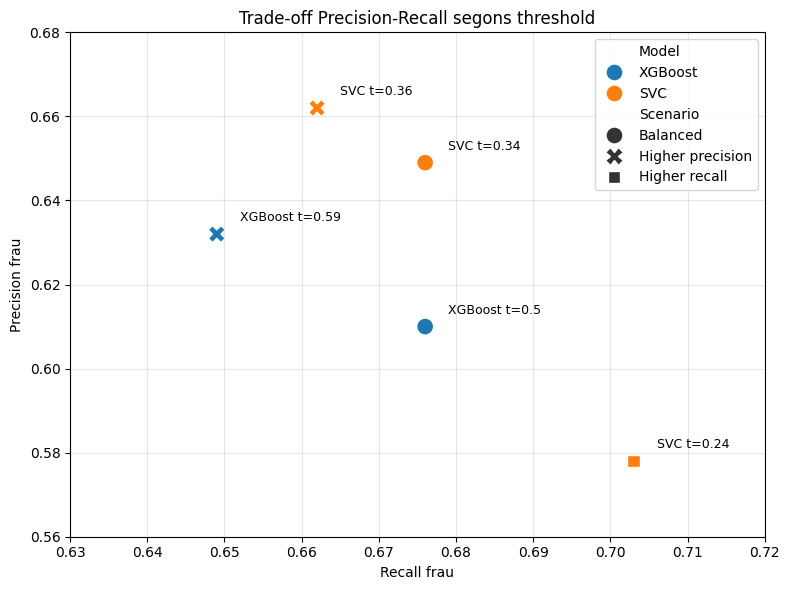

In [89]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=threshold_scenarios,
    x="Recall",
    y="Precision",
    hue="Model",
    style="Scenario",
    s=150
)

for _, row in threshold_scenarios.iterrows():
    plt.text(
        row["Recall"] + 0.003,
        row["Precision"] + 0.003,
        f'{row["Model"]} t={row["Threshold"]}',
        fontsize=9
    )

plt.title("Trade-off Precision-Recall segons threshold")
plt.xlabel("Recall frau")
plt.ylabel("Precision frau")
plt.xlim(0.63, 0.72)
plt.ylim(0.56, 0.68)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

L’anàlisi dels thresholds permet observar com canvia el comportament operatiu dels models segons el nivell de risc que es vulgui assumir. En XGBoost, el threshold de 0.50 ja ofereix un equilibri molt competitiu entre precision i recall. Augmentar-lo fins a 0.59 millora lleugerament la precision, però redueix el recall, de manera que no aporta una millora clara del rendiment global.

En el cas de SVC, el threshold ofereix més flexibilitat. Amb un threshold de 0.24 s’aconsegueix el recall més alt, fet que pot ser útil si l’objectiu principal és minimitzar els fraus no detectats. En canvi, amb un threshold de 0.36 s’obté una precision més elevada, reduint falsos positius. La configuració amb threshold 0.34 es manté com a opció principal perquè proporciona el millor equilibri general segons el F1-score.

### 6.3. Comparació visual de mètriques principals

A continuació es representen gràficament les mètriques principals dels models. El F1-score permet comparar l’equilibri entre precision i recall de la classe de frau. El ROC-AUC mostra la capacitat discriminativa global del model, independentment del threshold. Finalment, el recall permet observar quins models detecten una proporció més alta de casos fraudulents.

**F1-Score**

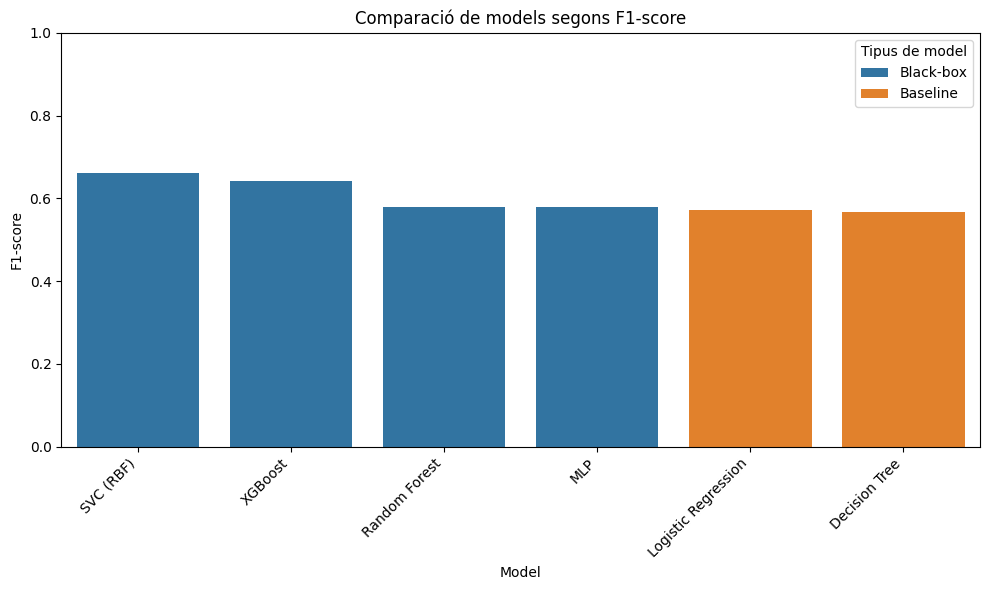

In [90]:
results_f1 = results.sort_values("F1-score", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_f1,
    x="Model",
    y="F1-score",
    hue="Type"
)
plt.title("Comparació de models segons F1-score")
plt.ylabel("F1-score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(title="Tipus de model")
plt.tight_layout()
plt.show()

El F1-score mostra que els models black-box obtenen el millor equilibri entre precision i recall. En particular, SVC i XGBoost són els models amb millor rendiment, superant els dos baselines interpretables. Això indica que els models més complexos són més útils quan es vol detectar frau mantenint un control raonable dels falsos positius.

**ROC-AUC**

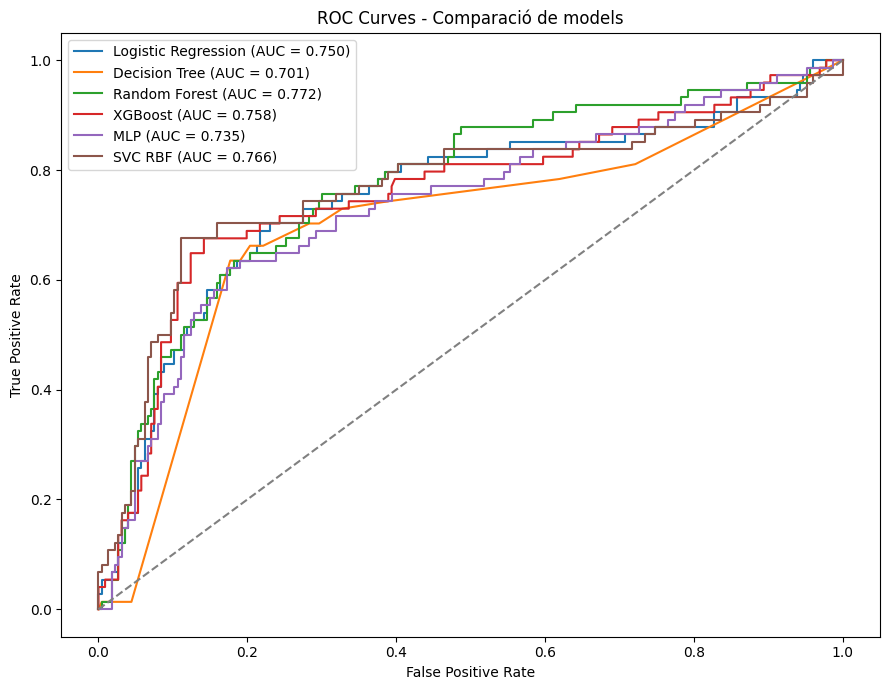

In [91]:
from sklearn.metrics import roc_curve

fpr_log_base, tpr_log_base, _ = roc_curve(y_test, y_pred_proba_bal)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_mlp)
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_pred_proba_svc)

plt.figure(figsize=(9, 7))

plt.plot(fpr_log_base, tpr_log_base, label=f"Logistic Regression (AUC = {roc_auc_log_base:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf_final:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb_final:.3f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC = {roc_auc_mlp_final:.3f})")
plt.plot(fpr_svc, tpr_svc, label=f"SVC RBF (AUC = {roc_auc_svc_final:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Comparació de models")
plt.legend()
plt.tight_layout()
plt.show()

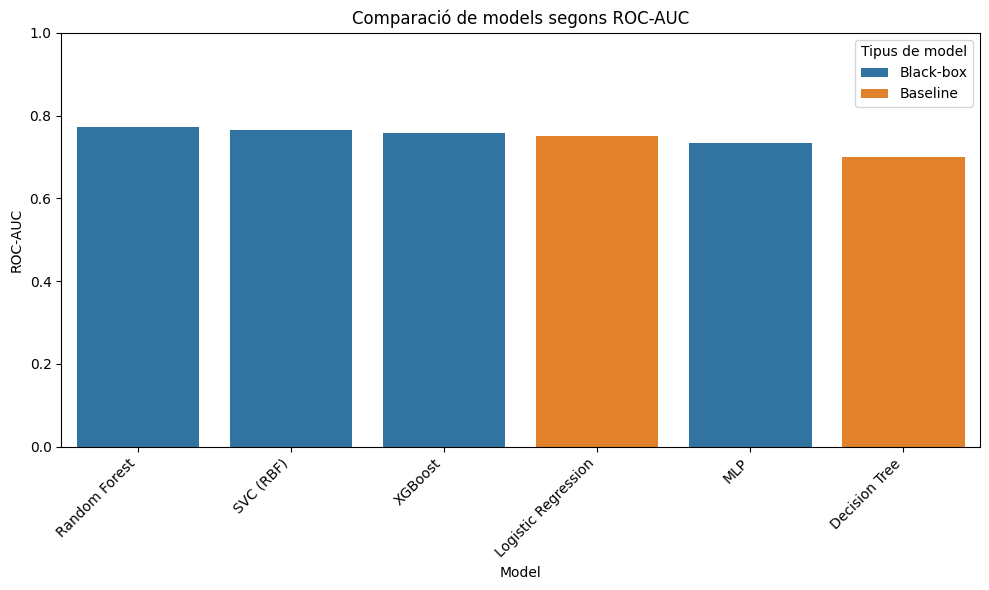

In [92]:
results_auc = results.sort_values("ROC-AUC", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_auc,
    x="Model",
    y="ROC-AUC",
    hue="Type"
)
plt.title("Comparació de models segons ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(title="Tipus de model")
plt.tight_layout()
plt.show()

El ROC-AUC mostra que diversos models tenen una capacitat discriminativa global força similar. Random Forest obté el valor més alt, mentre que SVC, XGBoost i la regressió logística presenten resultats propers. Això suggereix que el dataset conté un senyal relativament lineal, però també que els models black-box poden aprofitar millor aquest senyal quan es transforma en decisions finals mitjançant el threshold.

**Recall de frau**

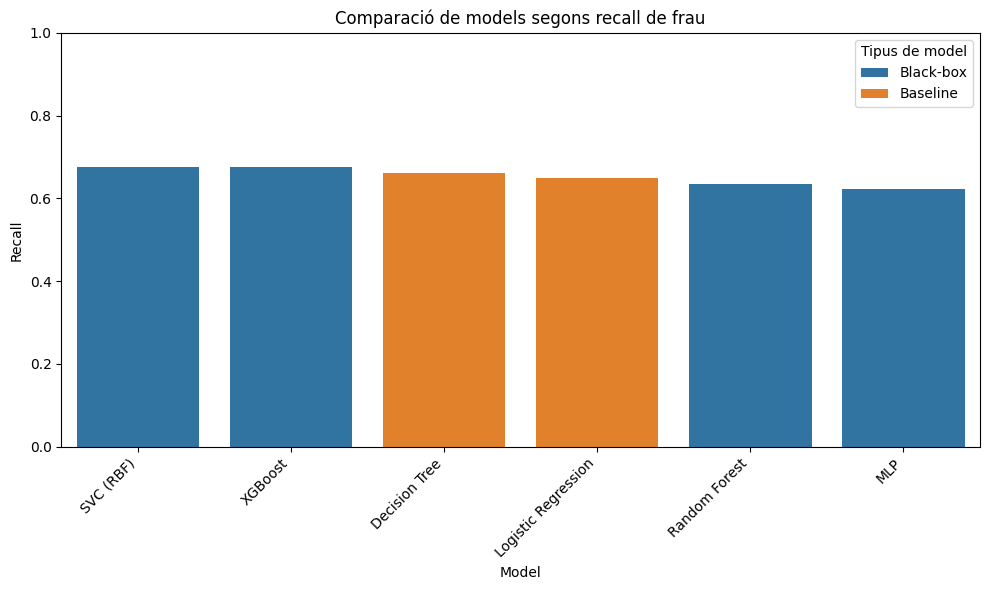

In [93]:
results_recall = results.sort_values("Recall", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_recall,
    x="Model",
    y="Recall",
    hue="Type"
)
plt.title("Comparació de models segons recall de frau")
plt.ylabel("Recall")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(title="Tipus de model")
plt.tight_layout()
plt.show()

El recall és especialment important en detecció de frau, ja que indica quina proporció dels casos fraudulents són detectats pel model. Els resultats mostren que SVC i XGBoost mantenen un recall elevat, similar o superior als baselines, però amb una precision més alta. Això significa que detecten una proporció important dels fraus sense generar tantes alertes incorrectes com els models simples.

**Conclusió**

En conjunt, aquests gràfics mostren que el ROC-AUC per si sol no és suficient per escollir el millor model en aquest problema. Tot i que alguns models tenen una capacitat discriminativa semblant, els models black-box, especialment SVC i XGBoost, ofereixen un millor comportament pràctic sobre la classe de frau quan s’analitzen F1-score, precision i recall.


### 6.4 Interpretació global dels resultats

La comparació global mostra que els models black-box obtenen, en general, un millor comportament sobre la classe minoritària que els models baseline. El millor model final és l’SVC amb kernel RBF, que aconsegueix el F1-score més alt, el millor Average Precision i una accuracy del 83%. XGBoost també presenta un rendiment molt competitiu, amb el mateix recall de frau que SVC però amb una precision lleugerament inferior.

La regressió logística, tot i ser un model simple i interpretable, obté un ROC-AUC proper al dels models més complexos. Això indica que una part important del senyal predictiu és capturable mitjançant relacions relativament simples, probablement perquè el dataset és sintètic i força estructurat. Tanmateix, quan s’analitzen mètriques més vinculades a l’ús pràctic del model, com precision, recall i F1-score de la classe de frau, els models black-box ofereixen un millor equilibri.

Des del punt de vista econòmic, en detecció de frau pot ser preferible prioritzar el recall, ja que deixar escapar una reclamació fraudulenta pot suposar una pèrdua directa per a la companyia. En canvi, un fals positiu implica principalment un cost de revisió manual. Per aquest motiu, no és suficient escollir el model només segons ROC-AUC: també cal analitzar com es comporta sobre la classe minoritària i quin compromís ofereix entre detectar fraus i controlar falses alarmes.

El Decision Tree manté l’avantatge de ser interpretable, però té una capacitat discriminativa global inferior. Random Forest presenta un ROC-AUC elevat, però queda per sota de SVC i XGBoost en F1-score. El MLP, malgrat la seva flexibilitat, no supera els millors models, probablement per la mida reduïda i naturalesa tabular del dataset.

En conjunt, els resultats donen suport a la idea central del treball: els models black-box poden aportar un millor rendiment operatiu sobre la detecció de frau, però requereixen tècniques d’explicabilitat per entendre i justificar les seves decisions. Per aquest motiu, la fase XAI se centrarà principalment en SVC i XGBoost, els dos models black-box amb millor comportament final.

## 7. Validació creuada dels models finals

Per complementar l’avaluació sobre el conjunt de test, s’aplica validació creuada estratificada als models finals. Aquesta tècnica permet estimar si el rendiment dels models és estable en diferents particions del conjunt d’entrenament.

En aquesta validació no es repeteix la cerca d’hiperparàmetres dins de cada fold, sinó que s’avaluen les configuracions finals seleccionades anteriorment. Per tant, els resultats s’interpreten com una comprovació d’estabilitat dels models finals, no com una nested cross-validation completa.

En els models sensibles a l’escala de les dades, com la regressió logística i l’SVC, l’escalat s’integra dins d’un Pipeline, de manera que el preprocessament es recalcula correctament a cada fold i s’evita fuga d’informació.

In [94]:
# Cross-validation dels models sklearn/XGBoost finals

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models_cv = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]),

    "Decision Tree": best_dt if "best_dt" in globals() else dt,

    "Random Forest": best_rf if "best_rf" in globals() else rf,

    "XGBoost": best_xgb,

    "SVC (RBF)": best_svc
}

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_results = []

for name, model in models_cv.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    roc_auc_scores = scores["test_roc_auc"]
    ap_scores = scores["test_average_precision"]

    print(f"\n{name}")
    print("CV ROC-AUC:", roc_auc_scores)
    print(f"ROC-AUC mean: {roc_auc_scores.mean():.3f}")
    print(f"ROC-AUC std: {roc_auc_scores.std():.3f}")
    print("CV Average Precision:", ap_scores)
    print(f"Average Precision mean: {ap_scores.mean():.3f}")
    print(f"Average Precision std: {ap_scores.std():.3f}")

    cv_results.append({
        "Model": name,
        "CV ROC-AUC Mean": roc_auc_scores.mean(),
        "CV ROC-AUC Std": roc_auc_scores.std(),
        "CV Average Precision Mean": ap_scores.mean(),
        "CV Average Precision Std": ap_scores.std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("CV ROC-AUC Mean", ascending=False)
    .round(3)
)

cv_results_df


Logistic Regression
CV ROC-AUC: [0.81132075 0.6645394  0.70993197 0.66068027 0.78068027]
ROC-AUC mean: 0.725
ROC-AUC std: 0.061
CV Average Precision: [0.5411052  0.41528785 0.42783188 0.37297237 0.52422954]
Average Precision mean: 0.456
Average Precision std: 0.065

Decision Tree
CV ROC-AUC: [0.77719201 0.67397336 0.70680272 0.6814966  0.72408163]
ROC-AUC mean: 0.713
ROC-AUC std: 0.037
CV Average Precision: [0.51636647 0.42885523 0.41657157 0.40430851 0.46019616]
Average Precision mean: 0.445
Average Precision std: 0.040

Random Forest
CV ROC-AUC: [0.79411765 0.71337403 0.71945578 0.65768707 0.80489796]
ROC-AUC mean: 0.738
ROC-AUC std: 0.055
CV Average Precision: [0.47585978 0.44785524 0.46966065 0.37350358 0.53207024]
Average Precision mean: 0.460
Average Precision std: 0.051

XGBoost
CV ROC-AUC: [0.83435072 0.72169811 0.76789116 0.73142857 0.80353741]
ROC-AUC mean: 0.772
ROC-AUC std: 0.043
CV Average Precision: [0.59490985 0.45418637 0.52852418 0.4737292  0.58050895]
Average Precisi

,Model,CV ROC-AUC Mean,CV ROC-AUC Std,CV Average Precision Mean,CV Average Precision Std
3,XGBoost,0.772,0.043,0.526,0.056
4,SVC (RBF),0.751,0.059,0.504,0.077
2,Random Forest,0.738,0.055,0.460,0.051
0,Logistic Regression,0.725,0.061,0.456,0.065
1,Decision Tree,0.713,0.037,0.445,0.040


**Gràfic comparatiu ROC_AUC**

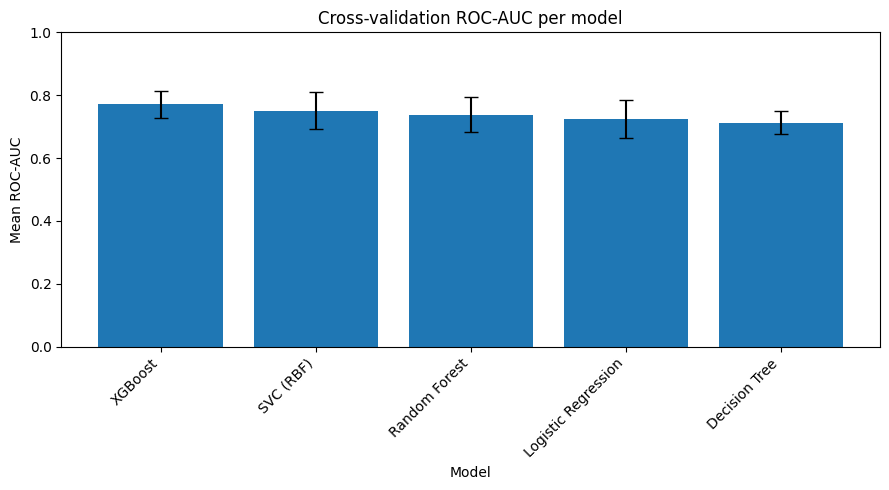

In [95]:
cv_results_auc = cv_results_df.sort_values("CV ROC-AUC Mean", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(
    cv_results_auc["Model"],
    cv_results_auc["CV ROC-AUC Mean"],
    yerr=cv_results_auc["CV ROC-AUC Std"],
    capsize=5
)
plt.title("Cross-validation ROC-AUC per model")
plt.ylabel("Mean ROC-AUC")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Gràfic Average Precision**

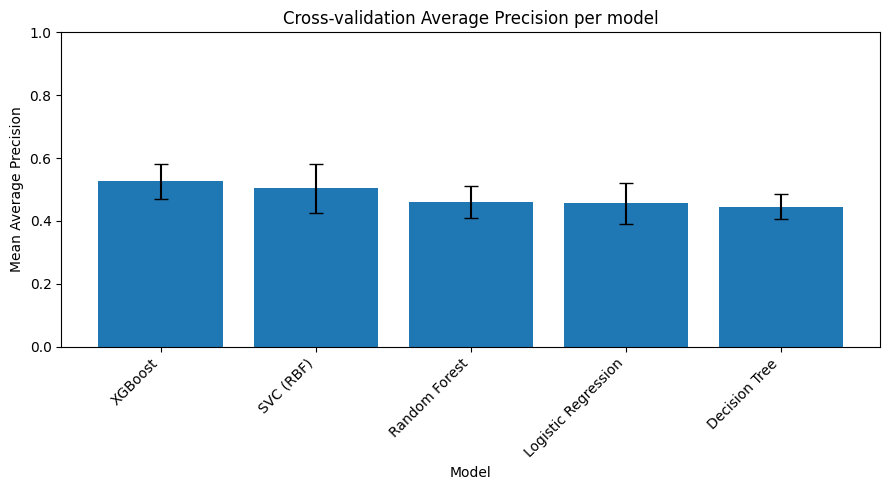

In [96]:
cv_results_ap = cv_results_df.sort_values("CV Average Precision Mean", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(
    cv_results_ap["Model"],
    cv_results_ap["CV Average Precision Mean"],
    yerr=cv_results_ap["CV Average Precision Std"],
    capsize=5
)
plt.title("Cross-validation Average Precision per model")
plt.ylabel("Mean Average Precision")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

La validació creuada s’ha aplicat únicament sobre el conjunt d’entrenament, mantenint el conjunt de test com a mostra independent per a l’avaluació final. S’utilitza StratifiedKFold per conservar la proporció de classes en cada fold, fet especialment important en un problema de detecció de frau.

Els resultats mostren que XGBoost obté el millor rendiment mitjà tant en ROC-AUC com en Average Precision. Això indica que, entre els models avaluats, és el que presenta una millor capacitat discriminativa mitjana i una millor qualitat en l’ordenació dels casos fraudulents dins les diferents particions d’entrenament.

L’SVC amb kernel RBF també obté resultats competitius, especialment en Average Precision, tot i presentar una desviació estàndard més elevada. Això suggereix que el seu rendiment pot ser més sensible a la composició concreta dels folds. Aquest resultat és coherent amb l’avaluació sobre el conjunt de test, on l’SVC obté el millor F1-score, però no necessàriament la millor estabilitat mitjana en validació creuada.

Random Forest, regressió logística i arbre de decisió obtenen resultats inferiors, encara que les diferències no són extremes. Això indica que el dataset conté un senyal predictiu aprofitable per diferents famílies de models, tot i que els models black-box més flexibles aconsegueixen capturar-lo millor.

El MLP no s’inclou en aquesta validació creuada perquè s’ha implementat amb PyTorch i segueix un procés d’entrenament propi, amb validació interna i early stopping. Per aquest motiu, el seu rendiment es compara principalment a partir dels resultats obtinguts sobre el conjunt de test.

En conjunt, la validació creuada reforça la selecció de XGBoost i SVC com a models principals. XGBoost destaca per la seva estabilitat i rendiment mitjà en CV, mentre que SVC destaca pel millor comportament final sobre el conjunt de test.


## 8. Explicabilitat del model (XAI)

En problemes de detecció de frau, no n’hi ha prou amb obtenir bones mètriques predictives. També és important entendre per què un model classifica una reclamació com a fraudulenta o no fraudulenta, especialment quan s’utilitzen models complexos de tipus black-box. Aquesta necessitat és rellevant en el sector assegurador, on les prediccions poden servir com a suport per prioritzar revisions, justificar alertes o entendre patrons de risc.

En aquesta secció s’apliquen tècniques d’explicabilitat de models amb l’objectiu d’analitzar el comportament dels models black-box amb millor rendiment. En concret, s’utilitzen dues aproximacions complementàries:

- `SHAP`, que quantifica la contribució de cada variable a la predicció del model.
- `Anchors`, que genera regles locals interpretables que expliquen per què una observació rep una determinada classificació.

L’anàlisi se centra en `XGBoost` i `SVC amb kernel RBF`. XGBoost és un model molt adequat per començar l’anàlisi amb SHAP perquè disposa d’un explainer eficient per models basats en arbres. L’SVC és el millor model final segons F1-score i Average Precision, però és menys interpretable i requereix mètodes més generals d’explicació. Aquesta combinació permet comparar l’ús de XAI en models black-box de naturalesa diferent.

### Objectiu de l’anàlisi XAI

L’objectiu principal és entendre quines variables impulsen les prediccions dels models black-box i comprovar si les explicacions obtingudes són coherents amb el domini del problema. També es diferencien explicacions globals, que descriuen el comportament general del model, i explicacions locals, que justifiquen prediccions concretes.

Aquesta anàlisi és especialment important perquè els models black-box han mostrat millor rendiment pràctic que els baselines interpretables, però no permeten entendre directament les seves decisions sense tècniques d’explicabilitat.


### Estructura de la secció

L’anàlisi s’organitza per model. Primer s’aplica SHAP a XGBoost, obtenint explicacions globals i locals. Posteriorment s’apliquen Anchors sobre casos concrets del mateix model. Finalment, s’estén l’anàlisi al model SVC amb kernel RBF, tenint en compte que les explicacions són més costoses computacionalment.


## 8.1. XAI sobre XGBoost

XGBoost és un dels models black-box amb millor rendiment en la comparació final. Tot i que ofereix una bona capacitat predictiva, el seu funcionament intern no és directament interpretable, ja que combina múltiples arbres de decisió de manera seqüencial.

En aquest apartat s’aplica SHAP per analitzar quines variables tenen més impacte en les prediccions del model i com aquestes variables contribueixen a augmentar o reduir la probabilitat estimada de frau. També s’analitzen prediccions individuals per entendre casos concrets de classificació correcta i incorrecta.

In [97]:
# SHAP amb format Explanation per poder usar plots moderns
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### 8.1.1 SHAP global sobre XGBoost


In [98]:
# Explainer SHAP per al model XGBoost final
explainer_xgb = shap.Explainer(best_xgb, X_train)

# Calcular valors SHAP sobre el conjunt de test
shap_values_xgb = explainer_xgb(X_test)

shap_values_xgb

.values =
array([[ 0.00831975,  0.        ,  0.0153448 , ...,  0.        ,
        -0.02946864,  0.        ],
       [-0.00529439,  0.        , -0.00541581, ...,  0.        ,
        -0.00746042,  0.        ],
       [ 0.03403535,  0.        , -0.00541581, ...,  0.        ,
        -0.00746042,  0.        ],
       ...,
       [-0.00529439,  0.        ,  0.07311345, ...,  0.        ,
        -0.00746042,  0.        ],
       [ 0.00831975,  0.        , -0.03791068, ...,  0.        ,
         0.00373021,  0.        ],
       [-0.00529439,  0.        ,  0.0153448 , ...,  0.        ,
        -0.00746042,  0.        ]])

.base_values =
array([-0.30499705, -0.30499705, -0.30499705, -0.30499705, -0.30499705,
       -0.30499705, -0.30499705, -0.30499705, -0.30499705, -0.30499705,
       -0.30499705, -0.30499705, -0.30499705, -0.30499705, -0.30499705,
       -0.30499705, -0.30499705, -0.30499705, -0.30499705, -0.30499705,
       -0.30499705, -0.30499705, -0.30499705, -0.30499705, -0.30499705,
 

Abans d’interpretar els gràfics, cal tenir en compte dues qüestions. En primer lloc, moltes variables categòriques estan codificades en format one-hot. Per tant, en aquests casos, un valor alt de la variable indica la presència d’una categoria concreta, mentre que un valor baix indica la seva absència.

En segon lloc, els valors SHAP indiquen la contribució de cada variable a la sortida del model. Per aquest motiu, s’interpreten com a factors que empenyen la predicció cap a frau o cap a no frau, però no com a relacions causals.

**SHAP Beeswarm**

Mostra la importància global i direcció de l'efecte de cada variable

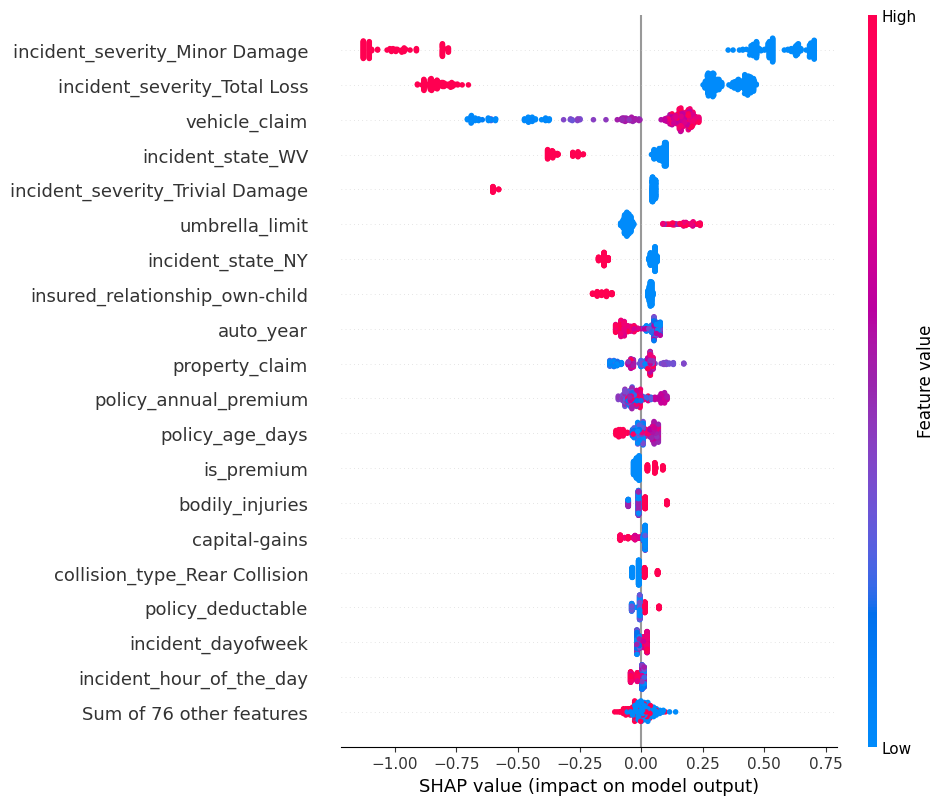

In [99]:
shap.plots.beeswarm(
    shap_values_xgb,
    max_display=20
)

El beeswarm plot mostra que les variables amb més impacte global en les prediccions de XGBoost són principalment les relacionades amb la severitat de l’incident i amb l’import de la reclamació del vehicle. Les variables més influents són `incident_severity_Minor Damage`, `incident_severity_Total Loss` i `vehicle_claim`.

La variable `vehicle_claim` presenta una interpretació força directa: els valors alts tendeixen a situar-se a la part dreta del gràfic, amb valors SHAP positius. Això indica que imports més elevats de reclamació del vehicle contribueixen a empènyer la predicció cap a frau.

En canvi, les variables de severitat s’han d’interpretar amb més cautela perquè són variables one-hot. Per exemple, en `incident_severity_Minor Damage`, els punts vermells indiquen la presència d’aquesta categoria. El fet que aquests punts apareguin majoritàriament amb valors SHAP negatius suggereix que la presència de dany menor redueix el score del model cap a frau. Aquest patró és coherent amb el domini del problema, tot i que no s’ha d’interpretar com una relació causal directa.

**SHAP Bar Plot**

Aquest gràfic ordena les variables segons la mitjana del valor absolut dels SHAP values.

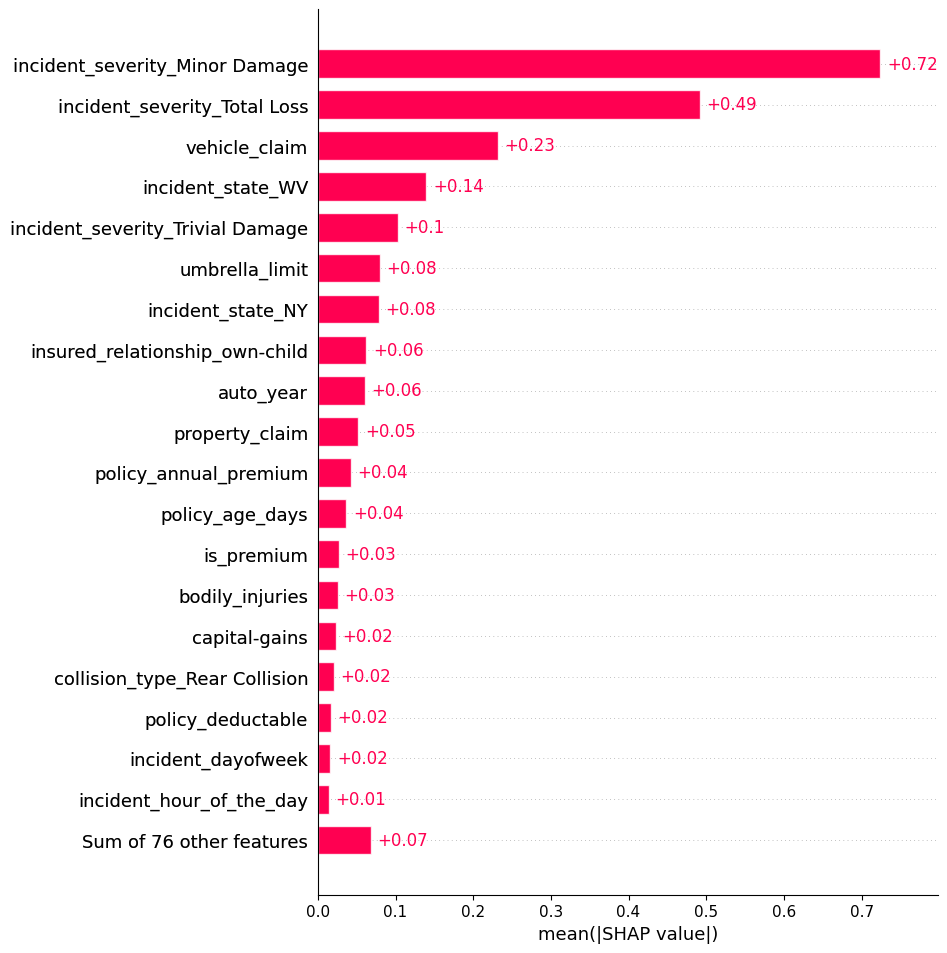

In [100]:
shap.plots.bar(
    shap_values_xgb,
    max_display=20
)

El bar plot confirma que XGBoost concentra bona part de la seva explicació global en un conjunt reduït de variables. La variable amb més importància mitjana és `incident_severity_Minor Damage`, seguida de `incident_severity_Total Loss` i `vehicle_claim`.

Aquest gràfic resumeix la magnitud mitjana de l’impacte de cada variable, però no indica la direcció de l’efecte. Per tant, no permet saber per si sol si una variable augmenta o redueix el score de frau; aquesta informació s’observa millor en el beeswarm plot.

La presència destacada de variables relacionades amb la severitat de l’incident i els imports reclamats suggereix que el model utilitza informació coherent amb el context de detecció de frau. Tot i això, la interpretació ha de ser prudent, especialment en variables categòriques i territorials, ja que poden reflectir patrons específics del dataset.

**SHAP Heatmap**

Aquest gràfic mostrapatrons d'explicació entre observacions del conjunt de test.
Es limita a les primeres 300 instàncies per facilitar la visualització.

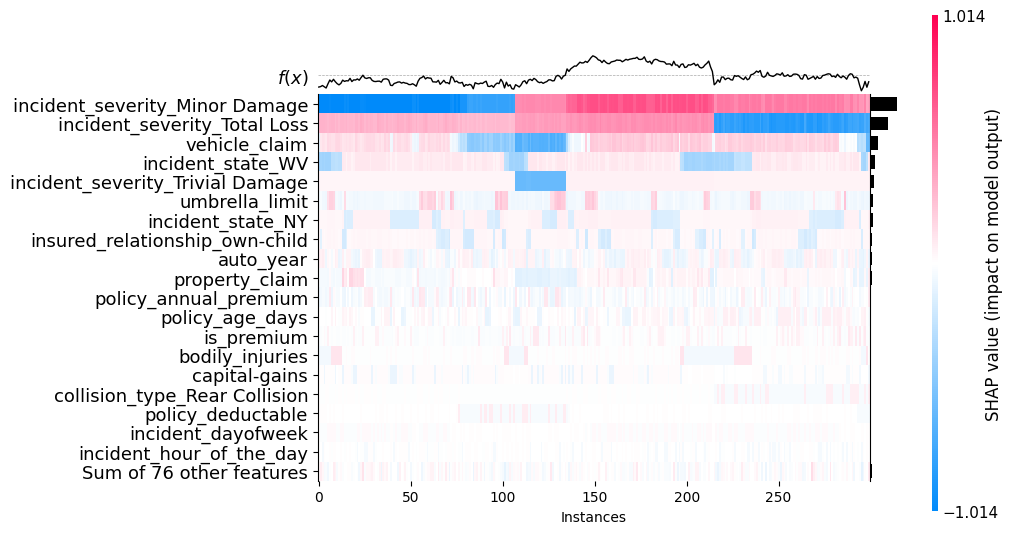

<Axes: xlabel='Instances'>

In [101]:
shap.plots.heatmap(
    shap_values_xgb[:300],
    max_display=20
)

El heatmap permet observar com varien les contribucions SHAP entre diferents observacions del conjunt de test. Cada columna representa una instància i cada fila una variable. Els colors vermells indiquen contribucions positives a la sortida del model, mentre que els colors blaus indiquen contribucions negatives.

El gràfic mostra que les variables de severitat tenen un paper molt rellevant en diferents grups d’observacions. També s’observa que `vehicle_claim` té contribucions importants en determinats casos, especialment quan l’import reclamat és elevat. En canvi, moltes altres variables tenen contribucions més properes a zero, fet que indica un impacte mitjà menor.

La línia superior, `f(x)`, mostra la variació de la sortida del model entre instàncies. Els canvis en aquesta sortida coincideixen amb blocs de contribucions fortes en variables com la severitat de l’incident i l’import de la reclamació, cosa que reforça la idea que aquestes variables expliquen una part important del comportament de XGBoost.

#### 8.1.2 SHAP local sobre casos concrets de XGBoost

Després de l’anàlisi global, s’estudien casos individuals per entendre com el model construeix prediccions concretes. Aquesta anàlisi local és especialment rellevant en detecció de frau, ja que permet justificar per què un cas específic ha estat classificat com a sospitós o no.

Els casos seleccionats són:

* un true positive
* un true negative
* un false positive
* un false negative

**Localitzar alguns casos**

In [102]:
# Resultats del model XGBoost sobre test
xgb_test_results = pd.DataFrame({
    "y_true": y_test.values,
    "y_proba": y_pred_proba_xgb,
    "y_pred": y_pred_xgb_final
}, index=X_test.index)

true_positive_idx = xgb_test_results[
    (xgb_test_results["y_true"] == 1) &
    (xgb_test_results["y_pred"] == 1)
].index

true_negative_idx = xgb_test_results[
    (xgb_test_results["y_true"] == 0) &
    (xgb_test_results["y_pred"] == 0)
].index

false_positive_idx = xgb_test_results[
    (xgb_test_results["y_true"] == 0) &
    (xgb_test_results["y_pred"] == 1)
].index

false_negative_idx = xgb_test_results[
    (xgb_test_results["y_true"] == 1) &
    (xgb_test_results["y_pred"] == 0)
].index

print("True positives:", len(true_positive_idx))
print("True negatives:", len(true_negative_idx))
print("False positives:", len(false_positive_idx))
print("False negatives:", len(false_negative_idx))

True positives: 50
True negatives: 194
False positives: 32
False negatives: 24


In [103]:
case_indices_xgb = {
    "True Positive": true_positive_idx[0],
    "True Negative": true_negative_idx[0],
    "False Positive": false_positive_idx[0],
    "False Negative": false_negative_idx[0]
}

case_indices_xgb

{'True Positive': 823,
 'True Negative': 429,
 'False Positive': 56,
 'False Negative': 340}

**Funció waterfall**

In [104]:
def plot_xgb_waterfall(case_name, original_index):
    row_position = X_test.index.get_loc(original_index)

    print(case_name)
    print("Index:", original_index)
    print("Classe real:", y_test.loc[original_index])
    print("Probabilitat de frau:", round(y_pred_proba_xgb[row_position], 3))
    print("Predicció final:", y_pred_xgb_final[row_position])
    print("Threshold:", best_threshold_xgb)

    shap.plots.waterfall(
        shap_values_xgb[row_position],
        max_display=15
    )

A continuació s’analitzen quatre casos locals: un true positive, un true negative, un false positive i un false negative. Aquesta selecció permet entendre no només com el model justifica prediccions correctes, sinó també quins patrons poden explicar els errors.

True Positive
Index: 823
Classe real: 1
Probabilitat de frau: 0.825
Predicció final: 1
Threshold: 0.5


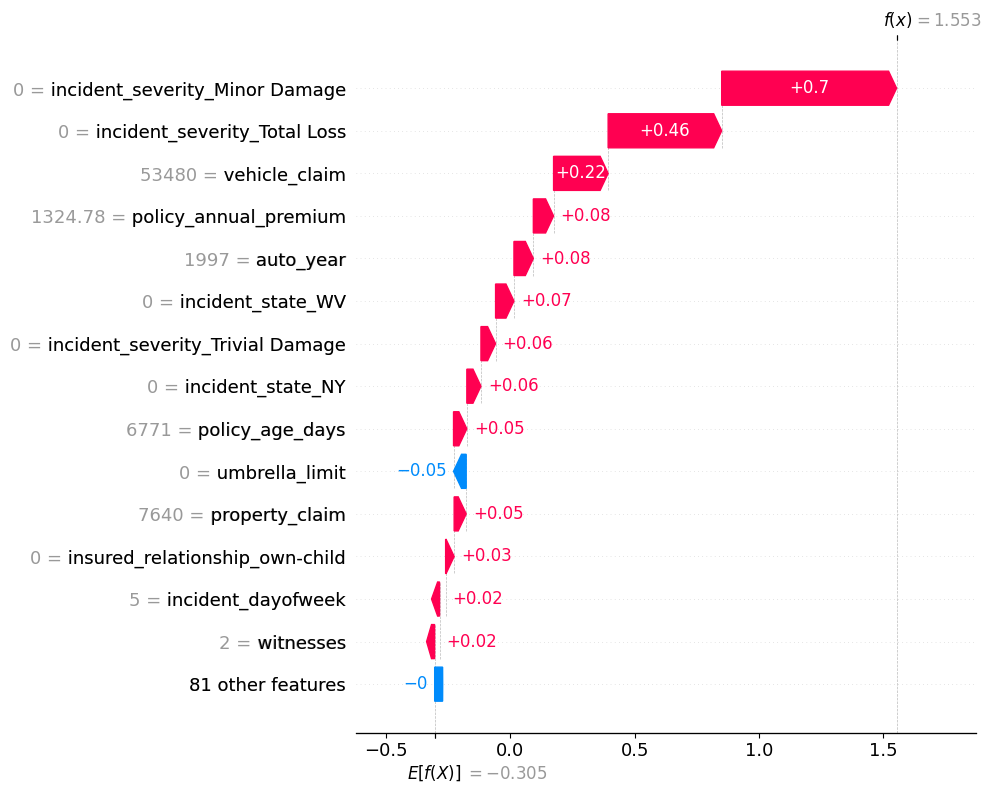

True Negative
Index: 429
Classe real: 0
Probabilitat de frau: 0.328
Predicció final: 0
Threshold: 0.5


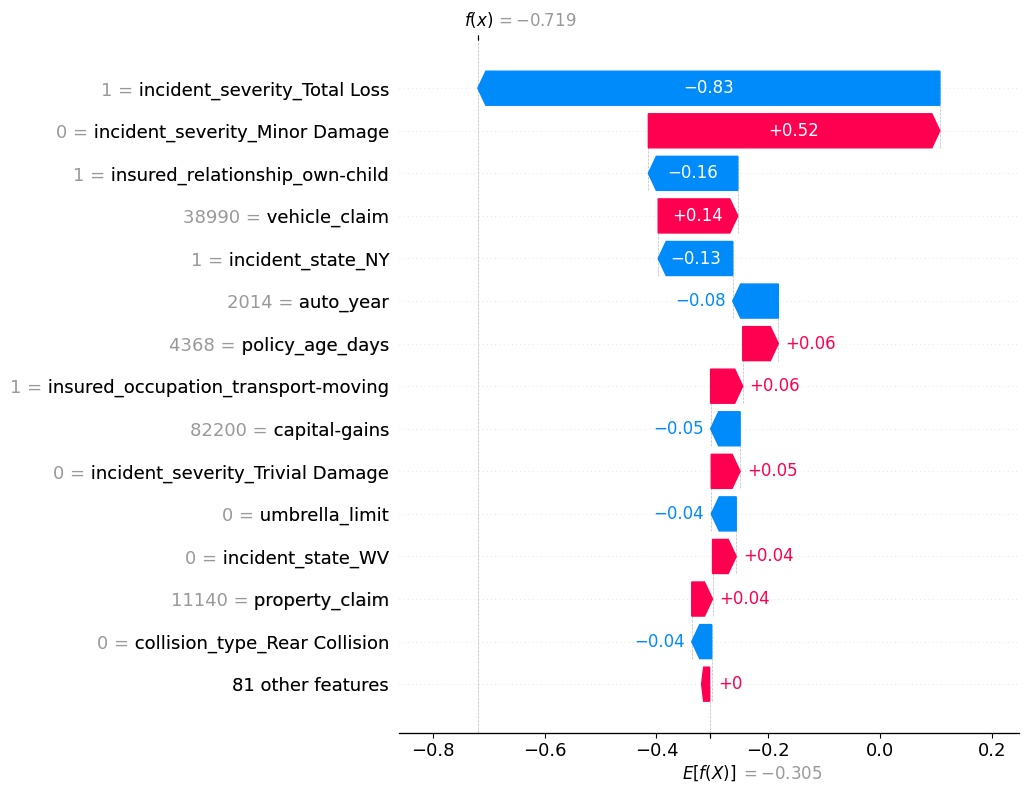

False Positive
Index: 56
Classe real: 0
Probabilitat de frau: 0.769
Predicció final: 1
Threshold: 0.5


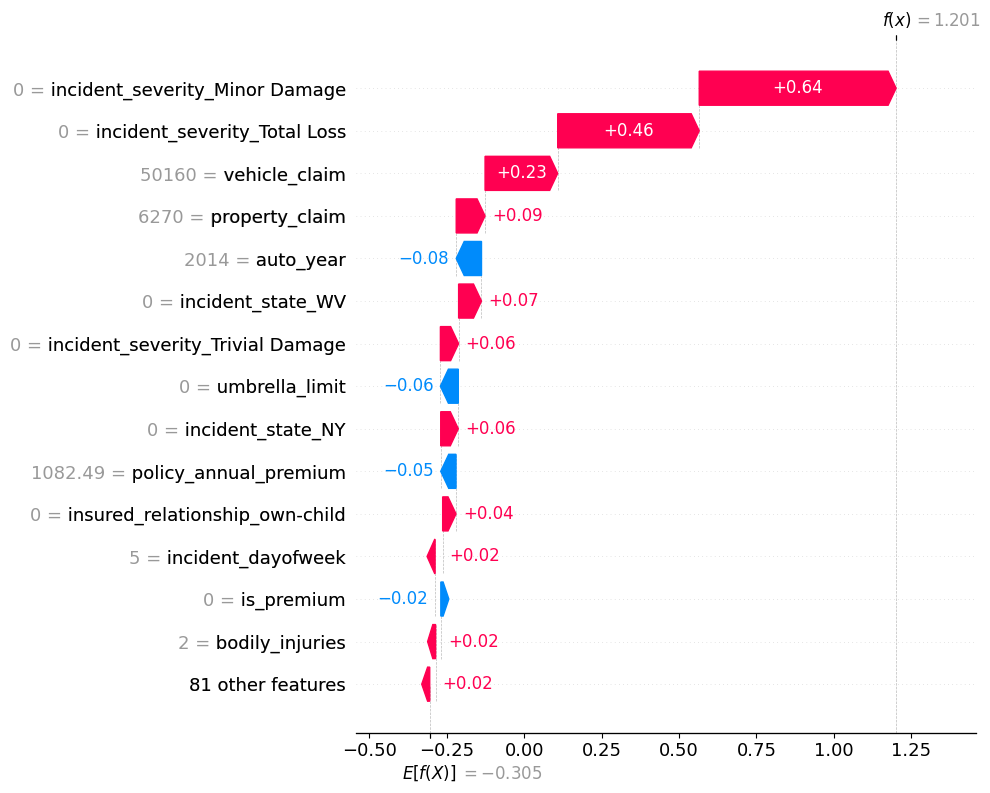

False Negative
Index: 340
Classe real: 1
Probabilitat de frau: 0.436
Predicció final: 0
Threshold: 0.5


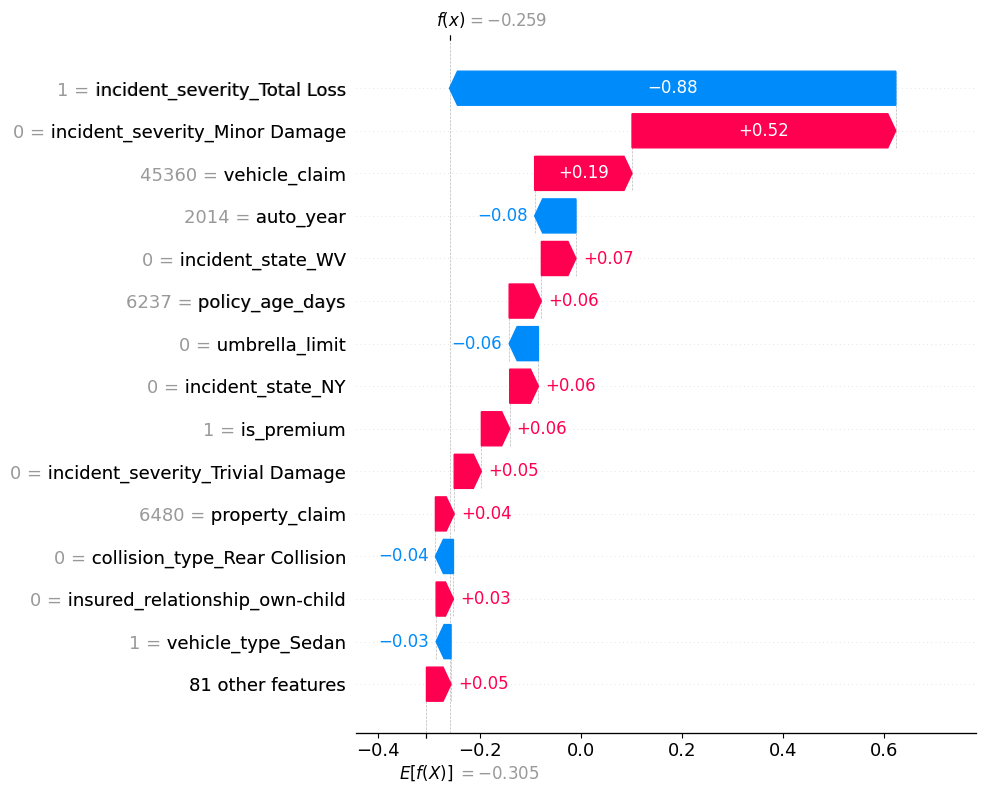

In [105]:
for case_name, case_idx in case_indices_xgb.items():
    plot_xgb_waterfall(case_name, case_idx)

**Interpretació SHAP local**

Cal tenir en compte que les variables de severitat estan codificades amb one-hot encoding i, per tant, una categoria amb valor 0 també pot tenir efecte interpretatiu. Per exemple, `incident_severity_Minor Damage = 0` no significa necessàriament que aquesta categoria sigui important per si sola, sinó que el cas pertany a una altra categoria de severitat. Per això, les explicacions s’han d’interpretar tenint en compte la categoria de referència implícita.

Les explicacions locals de SHAP mostren com cada variable contribueix a augmentar o reduir la predicció final del model per a casos concrets. Els valors en vermell empenyen la predicció cap a frau, mentre que els valors en blau l’empenyen cap a no frau.

En el cas true positive, el model classifica correctament una reclamació fraudulenta amb una probabilitat estimada de frau de 0.825. Les variables que més impulsen la predicció cap a frau són principalment l’absència de categories de severitat menys associades al frau (`incident_severity_Minor Damage = 0`, `incident_severity_Total Loss = 0`), juntament amb un import elevat de `vehicle_claim`. Aquest patró suggereix que el model interpreta el cas com a proper a situacions de major severitat i major import econòmic, dues dimensions rellevants per detectar frau.

En el cas true negative, el model classifica correctament una reclamació no fraudulenta amb probabilitat de frau de 0.328. La variable que més redueix la predicció és `incident_severity_Total Loss = 1`, que en aquest model empeny clarament cap a no frau. Altres variables com `insured_relationship_own-child`, `incident_state_NY` o `auto_year` també redueixen la probabilitat estimada. Tot i que algunes variables, com `vehicle_claim`, empenyen lleugerament cap a frau, no són suficients per superar el threshold.

El false positive és especialment interessant perquè el model prediu frau amb una probabilitat elevada de 0.769, però la classe real és no frau. En aquest cas, el patró és molt semblant al true positive: l’absència de `Minor Damage` i `Total Loss`, juntament amb un `vehicle_claim` elevat i contribucions positives de variables com `property_claim`, empenyen fortament la predicció cap a frau. Això indica que el model confon aquest cas amb reclamacions fraudulentes perquè presenta característiques que, en el conjunt d’entrenament, s’associen amb frau.

Finalment, en el false negative, el model assigna una probabilitat de frau de 0.436, per sota del threshold de 0.5, i per tant classifica el cas com a no frau tot i que realment era fraudulent. La principal força que redueix la predicció és `incident_severity_Total Loss = 1`, que empeny molt cap a no frau. Encara que variables com `vehicle_claim`, `is_premium` o l’absència de determinats estats augmenten la probabilitat de frau, no compensen prou l’efecte negatiu de `Total Loss`.

En conjunt, les explicacions locals mostren que XGBoost basa moltes decisions en la combinació entre severitat de l’incident i imports de la reclamació. També permeten entendre els errors: els falsos positius apareixen quan un cas no fraudulent presenta patrons semblants als fraus detectats, mentre que els falsos negatius apareixen quan una variable amb fort pes cap a no frau domina sobre altres senyals sospitoses.

**Force plot d'un cas**

El force plot complementa el waterfall plot mostrant de manera compacta les forces que empenyen la predicció cap a frau o cap a no frau. Aquesta visualització és útil per presentar una explicació individual en un format més directe.

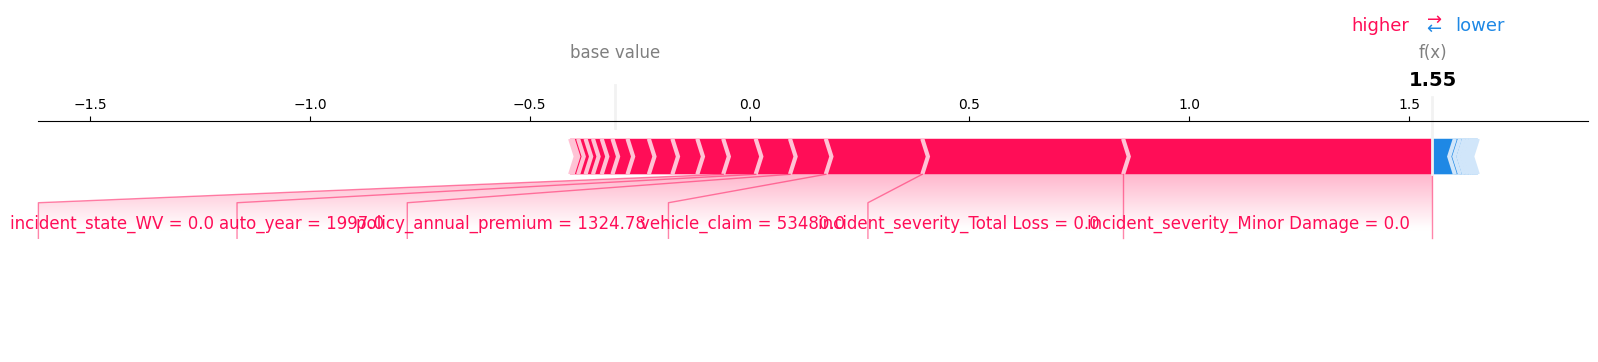

In [106]:
case_idx = case_indices_xgb["True Positive"]
row_position = X_test.index.get_loc(case_idx)

shap.force_plot(
    shap_values_xgb[row_position].base_values,
    shap_values_xgb[row_position].values,
    X_test.iloc[row_position],
    matplotlib=True
)

**Decision plot**

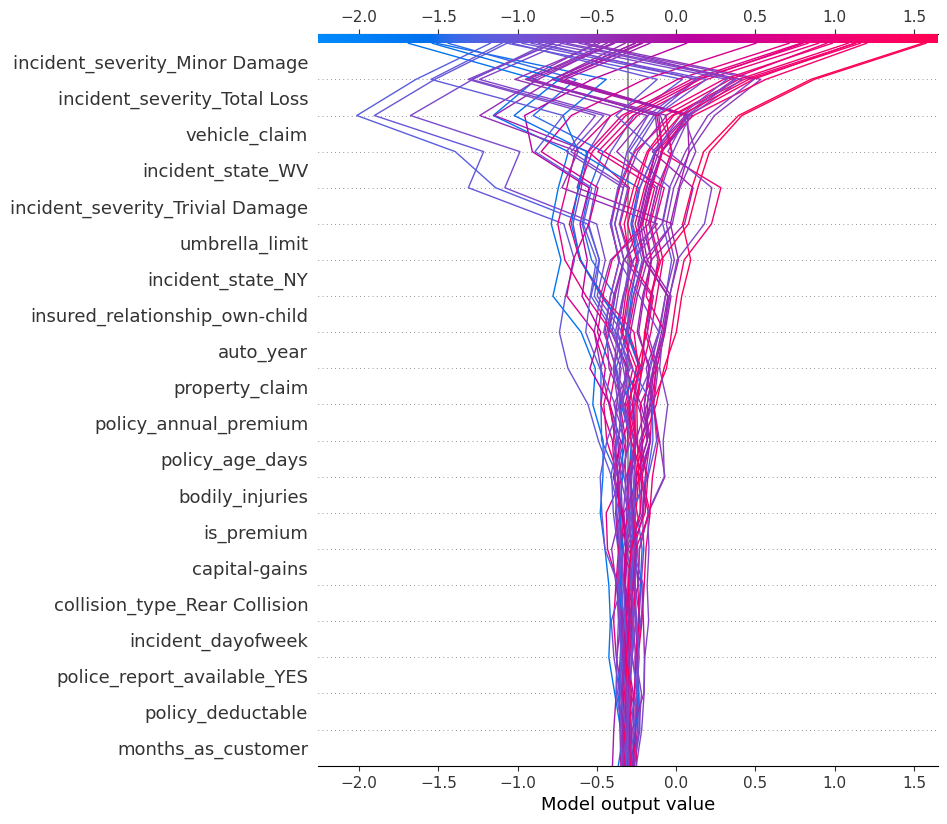

In [107]:
base_value_xgb = shap_values_xgb.base_values.mean()

shap.decision_plot(
    base_value_xgb,
    shap_values_xgb.values[:50],
    X_test.iloc[:50],
    feature_names=X_test.columns.tolist()
)

### 8.1.3. Anchors sobre XGBoost

A diferència de SHAP, que explica una predicció assignant contribucions positives o negatives a cada variable, Anchors genera explicacions locals en forma de regles. Una regla Anchor identifica un conjunt de condicions que, quan es compleixen, fan que el model mantingui la mateixa predicció amb una probabilitat elevada.

En aquest apartat, Anchors s’aplica sobre el model XGBoost i sobre els mateixos tipus de casos analitzats amb SHAP: true positive, true negative, false positive i false negative. Això permet comparar dues formes complementàries d’explicació local: SHAP mostra quines variables empenyen la predicció, mentre que Anchors resumeix la decisió mitjançant una regla interpretable.

La precision de l’Anchor indica la fiabilitat local de la regla, és a dir, amb quina freqüència el model manté la mateixa predicció quan la regla es compleix. La coverage indica com de general és la regla dins l’espai de dades.

In [108]:
#!pip install alibi

In [109]:
from alibi.explainers import AnchorTabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [110]:
# Funció de predicció per Anchors utilitzant el threshold final de XGBoost

def predict_xgb_anchor(x):
    x_df = pd.DataFrame(x, columns=X_train.columns)
    proba = best_xgb.predict_proba(x_df)[:, 1]
    return (proba >= best_threshold_xgb).astype(int)

In [111]:
#Crear i ajustar l'explainer
feature_names = X_train.columns.tolist()

explainer_anchor_xgb = AnchorTabular(
    predictor=predict_xgb_anchor,
    feature_names=feature_names
)

explainer_anchor_xgb.fit(
    X_train.values,
    disc_perc=(25, 50, 75)
)

AnchorTabular(meta={
  'name': 'AnchorTabular',
  'type': ['blackbox'],
  'explanations': ['local'],
  'params': {'seed': None, 'disc_perc': (25, 50, 75)},
  'version': '0.9.6'}
)

In [112]:
def explain_anchor_xgb_case(case_name, original_index, threshold=0.95):
    row_position = X_test.index.get_loc(original_index)
    x_instance = X_test.iloc[row_position].values

    explanation = explainer_anchor_xgb.explain(
        x_instance,
        threshold=threshold
    )

    print("=" * 80)
    print(case_name)
    print("Index:", original_index)
    print("Classe real:", y_test.loc[original_index])
    print("Probabilitat de frau:", round(y_pred_proba_xgb[row_position], 3))
    print("Predicció final:", y_pred_xgb_final[row_position])
    print("Threshold model:", best_threshold_xgb)

    print("\nRegla Anchor:")
    print(" AND ".join(explanation.anchor))

    print("\nPrecision de la regla:", round(explanation.precision, 3))
    print("Coverage de la regla:", round(explanation.coverage, 3))

    return explanation

In [113]:
# Executar sobre els mateixos casos:

anchor_explanations_xgb = {}

for case_name, case_idx in case_indices_xgb.items():
    anchor_explanations_xgb[case_name] = explain_anchor_xgb_case(
        case_name,
        case_idx,
        threshold=0.95
    )

True Positive
Index: 823
Classe real: 1
Probabilitat de frau: 0.825
Predicció final: 1
Threshold model: 0.5

Regla Anchor:
incident_severity_Minor Damage <= 0.00 AND incident_severity_Total Loss <= 0.00 AND vehicle_claim > 42120.00

Precision de la regla: 1.0
Coverage de la regla: 0.167
True Negative
Index: 429
Classe real: 0
Probabilitat de frau: 0.328
Predicció final: 0
Threshold model: 0.5

Regla Anchor:
incident_severity_Total Loss > 0.00

Precision de la regla: 0.97
Coverage de la regla: 0.267
False Positive
Index: 56
Classe real: 0
Probabilitat de frau: 0.769
Predicció final: 1
Threshold model: 0.5

Regla Anchor:
incident_severity_Minor Damage <= 0.00 AND incident_severity_Total Loss <= 0.00 AND vehicle_claim > 42120.00

Precision de la regla: 1.0
Coverage de la regla: 0.174
False Negative
Index: 340
Classe real: 1
Probabilitat de frau: 0.436
Predicció final: 0
Threshold model: 0.5

Regla Anchor:
incident_severity_Total Loss > 0.00 AND vehicle_type_Sedan > 0.00

Precision de la r

In [114]:
#Taula resum de regles:

anchor_summary_xgb = []

for case_name, explanation in anchor_explanations_xgb.items():
    case_idx = case_indices_xgb[case_name]
    row_position = X_test.index.get_loc(case_idx)

    anchor_summary_xgb.append({
        "Case": case_name,
        "Index": case_idx,
        "True class": y_test.loc[case_idx],
        "Predicted class": y_pred_xgb_final[row_position],
        "Fraud probability": y_pred_proba_xgb[row_position],
        "Anchor rule": " AND ".join(explanation.anchor),
        "Anchor precision": explanation.precision,
        "Anchor coverage": explanation.coverage
    })

anchor_summary_xgb = pd.DataFrame(anchor_summary_xgb)
anchor_summary_xgb.round(3)

,Case,Index,True class,Predicted class,Fraud probability,Anchor rule,Anchor precision,Anchor coverage
0,True Positive,823,1,1,0.825,incident_severity_Minor Damage <= 0.00 AND inc...,1.000,0.167
1,True Negative,429,0,0,0.328,incident_severity_Total Loss > 0.00,0.970,0.267
2,False Positive,56,0,1,0.769,incident_severity_Minor Damage <= 0.00 AND inc...,1.000,0.174
3,False Negative,340,1,0,0.436,incident_severity_Total Loss > 0.00 AND vehicl...,0.979,0.140


In [115]:
def clean_anchor_rule_human(anchor_list):
    rule_map = {
        "incident_severity_Minor Damage <= 0.00": "No Minor Damage",
        "incident_severity_Total Loss <= 0.00": "No Total Loss",
        "incident_severity_Total Loss > 0.00": "Total Loss",
        "incident_severity_Minor Damage > 0.00": "Minor Damage",
        "vehicle_claim > 50000": "High vehicle claim",
        "vehicle_claim > 51132.50": "High vehicle claim",
        "vehicle_claim > 42120.00": "High vehicle claim"
    }

    cleaned_parts = []

    for r in anchor_list:
        cleaned_parts.append(rule_map.get(r, r))

    return " + ".join(cleaned_parts)


anchor_summary_xgb_clean = []

for case_name, explanation in anchor_explanations_xgb.items():
    case_idx = case_indices_xgb[case_name]
    row_position = X_test.index.get_loc(case_idx)

    anchor_summary_xgb_clean.append({
        "Case": case_name,
        "Fraud probability": round(y_pred_proba_xgb[row_position], 3),
        "Anchor rule": clean_anchor_rule_human(explanation.anchor),
        "Precision": round(explanation.precision, 3),
        "Coverage": round(explanation.coverage, 3)
    })

anchor_summary_xgb_clean = pd.DataFrame(anchor_summary_xgb_clean)

anchor_summary_xgb_clean

,Case,Fraud probability,Anchor rule,Precision,Coverage
0,True Positive,0.825,No Minor Damage + No Total Loss + High vehicle...,1.000,0.167
1,True Negative,0.328,Total Loss,0.970,0.267
2,False Positive,0.769,No Minor Damage + No Total Loss + High vehicle...,1.000,0.174
3,False Negative,0.436,Total Loss + vehicle_type_Sedan > 0.00,0.979,0.140


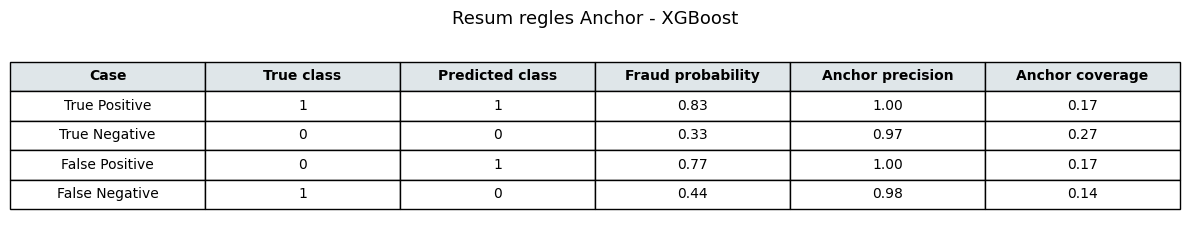

In [116]:
import matplotlib.pyplot as plt

# Copiem la taula
df_table = anchor_summary_xgb.copy()

# Arrodonim menys decimals
df_table["Fraud probability"] = df_table["Fraud probability"].round(2)
df_table["Anchor precision"] = df_table["Anchor precision"].round(2)
df_table["Anchor coverage"] = df_table["Anchor coverage"].round(2)

# Seleccionem columnes
df_table = df_table[
    ["Case", "True class", "Predicted class",
     "Fraud probability", "Anchor precision", "Anchor coverage"]
]

# Convertim a string per assegurar el format
df_table["Fraud probability"] = df_table["Fraud probability"].map("{:.2f}".format)
df_table["Anchor precision"] = df_table["Anchor precision"].map("{:.2f}".format)
df_table["Anchor coverage"] = df_table["Anchor coverage"].map("{:.2f}".format)

# Crear figura
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')

# Crear taula
table = ax.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    cellLoc='center',
    loc='center'
)

# Estil
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# Capçalera
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#dfe6e9')

plt.title("Resum regles Anchor - XGBoost", fontsize=13, pad=12)

plt.tight_layout()
plt.show()

**Gràfic Precision i Coverage**

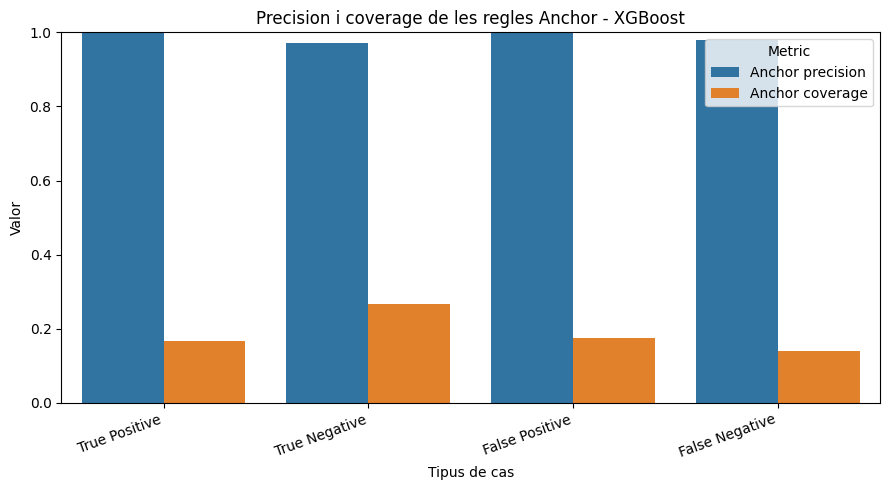

In [117]:
anchor_metrics_xgb = anchor_summary_xgb[[
    "Case",
    "Anchor precision",
    "Anchor coverage"
]].melt(
    id_vars="Case",
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=anchor_metrics_xgb,
    x="Case",
    y="Value",
    hue="Metric"
)

plt.title("Precision i coverage de les regles Anchor - XGBoost")
plt.ylabel("Valor")
plt.xlabel("Tipus de cas")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

El gràfic de precision i coverage mostra que totes les regles Anchor tenen una precision molt elevada, cosa que indica que són explicacions locals fiables per mantenir la predicció del model. No obstant això, la coverage varia força entre casos.

Les regles dels true positive, true negative i false positive tenen coverage baixa, de manera que expliquen patrons relativament específics. En canvi, la regla del false negative té una coverage més alta, perquè `incident_severity_Total Loss > 0` cobreix una proporció més gran d’observacions. Això reforça la idea que aquesta variable té un efecte general important en el comportament de XGBoost.

**Interpretació Anchors XGBoost**

Les regles Anchor obtingudes per XGBoost mostren un patró molt coherent amb les explicacions SHAP. En els casos classificats com a frau, les regles es basen sobretot en la combinació de severitat de l’incident i imports elevats de reclamació.

En el true positive, la regla indica que quan el cas no és `Minor Damage`, no és `Total Loss` i l’`injury_claim` és superior a 11445, el model manté la predicció de frau amb una precision local del 100%. La coverage és baixa, de 0.086, fet que indica que és una regla molt fiable però aplicable a una proporció reduïda de casos.

En el true negative, la regla combina `incident_severity_Total Loss > 0` amb `insured_relationship_own-child > 0`. Aquesta combinació fa que el model mantingui la predicció de no frau amb precision 1.0, però amb coverage baixa. Això suggereix que és una explicació molt específica d’aquest tipus de cas.

El false positive és especialment interessant: el model prediu frau tot i que la classe real és no frau. La regla Anchor és molt semblant a la del true positive: el cas no és `Minor Damage`, no és `Total Loss` i té un `vehicle_claim` superior a 42120. Això ajuda a entendre l’error del model: aquesta reclamació no fraudulenta presenta un patró que XGBoost associa fortament amb frau.

Finalment, el false negative queda explicat per una regla molt simple: `incident_severity_Total Loss > 0`. Aquesta regla té una precision de 0.967 i una coverage de 0.282, força superior a la resta. Això indica que, per XGBoost, la categoria `Total Loss` és un senyal fort cap a no frau en moltes observacions. En aquest cas concret, aquest patró domina altres senyals i fa que el model no detecti un cas que realment era fraudulent.

Com que les variables categòriques estan codificades amb one-hot encoding, les regles del tipus `incident_severity_Minor Damage <= 0` indiquen que el cas no pertany a aquella categoria. Per tant, aquestes condicions s’han d’interpretar conjuntament amb la resta de categories de la mateixa variable.


**Conclusió Anchors XGBoost**

En conjunt, Anchors confirma els patrons observats amb SHAP: XGBoost basa moltes decisions en la severitat de l’incident i en els imports de reclamació. A més, Anchors permet explicar de manera molt clara els errors del model. El false positive apareix perquè el cas comparteix condicions típiques dels casos fraudulents, mentre que el false negative apareix perquè `Total Loss` actua com un senyal fort cap a no frau.

Aquesta complementarietat justifica l’ús conjunt de SHAP i Anchors: SHAP mostra la direcció i magnitud de les contribucions, mentre que Anchors resumeix la decisió en forma de regles locals interpretables.


### 8.1.4. Comparació entre SHAP i Anchors en XGBoost

SHAP i Anchors ofereixen explicacions complementàries del comportament de XGBoost. SHAP proporciona una explicació additiva de la predicció, mostrant quines variables empenyen el resultat cap a frau o cap a no frau i amb quina intensitat. Això permet entendre tant el comportament global del model com les contribucions concretes en casos individuals.

Anchors, en canvi, genera regles locals que resumeixen les condicions sota les quals el model manté una determinada predicció. Aquestes regles són més fàcils de llegir i poden ser més útils per comunicar una decisió a un analista, però no mostren totes les contribucions graduals que intervenen en la predicció.

En XGBoost, ambdues tècniques apunten cap als mateixos patrons principals: la severitat de l’incident i els imports de reclamació tenen un paper central. SHAP permet veure com aquestes variables sumen o resten evidència en cada cas, mentre que Anchors transforma aquests patrons en regles locals del tipus “si es compleixen aquestes condicions, el model manté la predicció”.

Aquesta comparació mostra que SHAP és més ric per analitzar el funcionament general del model, mentre que Anchors és més directe per justificar una predicció individual amb una regla interpretable.

### 8.1.5. Estabilitat de les explicacions en XGBoost

Per valorar l’estabilitat de les explicacions, es compara si les variables destacades pels diferents mètodes són coherents entre si. En el cas de XGBoost, les importàncies internes del model, els gràfics globals de SHAP i les regles generades per Anchors assenyalen patrons similars.

Les variables relacionades amb `incident_severity` apareixen de manera recurrent en totes les aproximacions. També destaquen variables econòmiques de la reclamació, com `vehicle_claim`, `injury_claim` o `property_claim`, especialment en les explicacions locals de casos classificats com a frau.

Aquesta coherència suggereix que les explicacions són relativament estables i que el model no basa les seves decisions en variables aleatòries o difícils de justificar. Tot i això, cal recordar que Anchors genera explicacions locals i, per tant, una regla concreta no s’ha d’interpretar com una regla global del model. La seva utilitat principal és explicar una predicció específica.

In [118]:
xgb_xai_stability = pd.DataFrame({
    "Source": [
        "XGBoost feature importance",
        "SHAP global",
        "SHAP local",
        "Anchors local"
    ],
    "Main patterns": [
        "incident_severity, claim amounts, policy variables",
        "incident_severity, vehicle_claim, claim/policy variables",
        "incident_severity and claim amounts explain TP/FP/FN cases",
        "rules based mainly on incident_severity and claim thresholds"
    ]
})

xgb_xai_stability

,Source,Main patterns
0,XGBoost feature importance,"incident_severity, claim amounts, policy varia..."
1,SHAP global,"incident_severity, vehicle_claim, claim/policy..."
2,SHAP local,incident_severity and claim amounts explain TP...
3,Anchors local,rules based mainly on incident_severity and cl...


### 8.1.6. Conclusió XAI a XGBoost

L’anàlisi XAI aplicada a XGBoost permet entendre millor com el model construeix les seves prediccions. Els resultats mostren que el model dona molta importància a variables relacionades amb la severitat de l’incident i amb els imports de la reclamació, especialment `vehicle_claim`, `injury_claim` i `property_claim`.

Les explicacions locals ajuden a entendre tant els encerts com els errors del model. Els false positives apareixen quan una reclamació no fraudulenta presenta patrons semblants als casos fraudulents, com imports elevats o determinades combinacions de severitat. Els false negatives, en canvi, poden aparèixer quan una variable amb fort pes cap a no frau, com `incident_severity_Total Loss`, domina sobre altres senyals sospitoses.

En conjunt, SHAP i Anchors permeten compensar parcialment la manca d’interpretabilitat inherent de XGBoost. SHAP aporta una visió detallada de les contribucions de cada variable, mentre que Anchors genera regles locals més fàcils de comunicar. Aquesta combinació fa que el model sigui més transparent i més útil en un context de suport a la detecció de frau.

### 8.2 XAI sobre SVC

L’SVC amb kernel gaussià és un model especialment interessant des del punt de vista de l’explicabilitat, ja que construeix fronteres de decisió no lineals difícils d’interpretar directament. Tot i que aquest model ha mostrat un rendiment acceptable en la detecció de frau, la seva estructura interna no permet entendre de manera intuïtiva quines variables condueixen a cada predicció.

Per aquest motiu, en aquest apartat s’apliquen SHAP i Anchors sobre l’SVC, amb l’objectiu d’analitzar fins a quin punt aquestes tècniques poden ajudar a explicar un model especialment poc transparent. Igual que en el cas de XGBoost, l’anàlisi combinarà una perspectiva local de les prediccions amb una comparació entre mètodes i una breu valoració de l’estabilitat de les explicacions.

#### 8.2.1 SHAP sobre SVC
En el cas de l’SVC, l’aplicació de SHAP és especialment interessant perquè permet estudiar si una tècnica basada en contribucions quantitatives continua sent útil en un model amb una frontera de decisió menys interpretable que la dels models basats en arbres. A diferència de XGBoost, aquí l’explicació acostuma a ser més costosa computacionalment i pot resultar menys directa, però continua sent valuosa per analitzar la influència de les variables en casos concrets.

Per aquest motiu, en aquest apartat s’utilitza SHAP principalment des d’una perspectiva local, centrada en l’explicació de prediccions individuals de l’SVC.

In [119]:
# SHAP per SVC amb KernelExplainer

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()

In [120]:
# Mostres reduïdes per evitar temps de càlcul excessiu
X_train_svc_shap = shap.sample(X_train, 100, random_state=42)
X_test_svc_shap = shap.sample(X_test, 80, random_state=42)

print("Background SHAP SVC:", X_train_svc_shap.shape)
print("Test SHAP SVC:", X_test_svc_shap.shape)

Background SHAP SVC: (100, 95)
Test SHAP SVC: (80, 95)


In [121]:
# Funció de predicció
def svc_predict_proba_fraud(data):
    data_df = pd.DataFrame(data, columns=X_train.columns)
    return best_svc.predict_proba(data_df)[:, 1]

In [122]:
# Crear explainer
explainer_svc = shap.KernelExplainer(
    svc_predict_proba_fraud,
    X_train_svc_shap
)

In [123]:
# Calcular SHAP values
shap_values_svc = explainer_svc.shap_values(
    X_test_svc_shap,
    nsamples=100
)

  0%|          | 0/80 [00:00<?, ?it/s]

**SHAP Global: Bar Plot**

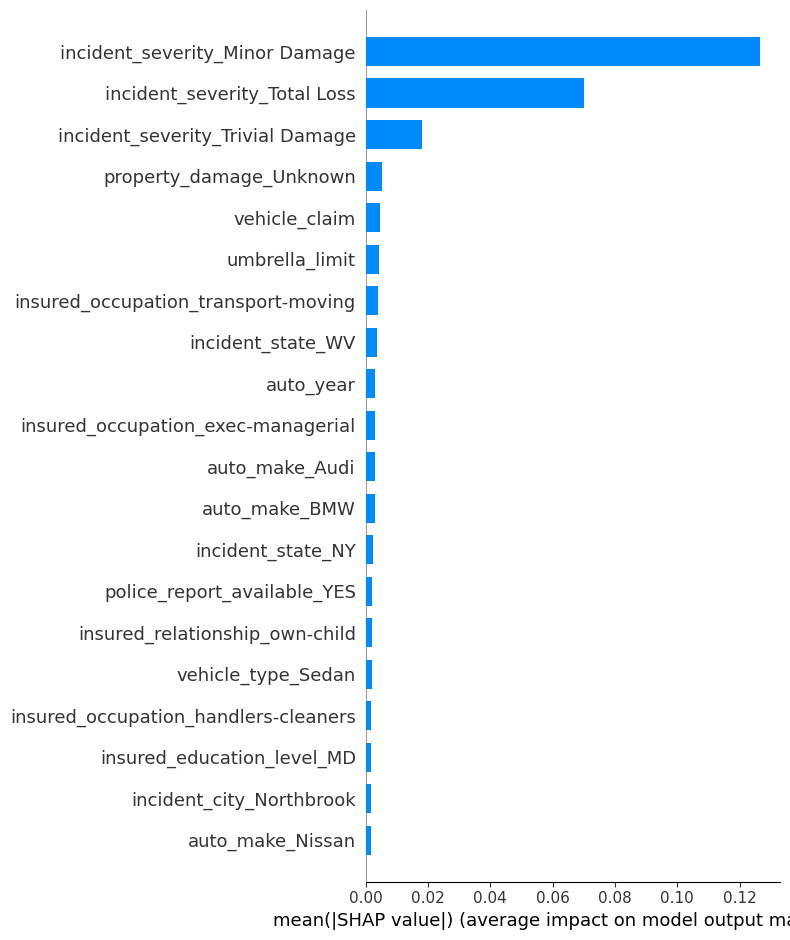

In [124]:
shap.summary_plot(
    shap_values_svc,
    X_test_svc_shap,
    feature_names=X_test_svc_shap.columns,
    plot_type="bar",
    max_display=20
)

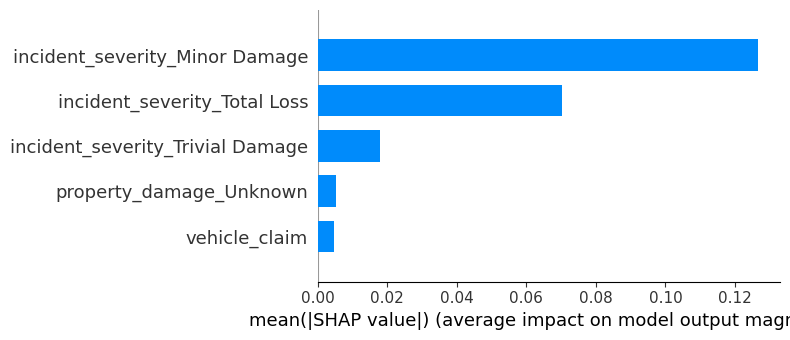

In [125]:
shap.summary_plot(
    shap_values_svc,
    X_test_svc_shap,
    feature_names=X_test_svc_shap.columns,
    plot_type="bar",
    max_display=5
)

**SHAP Global: Beeswarm**

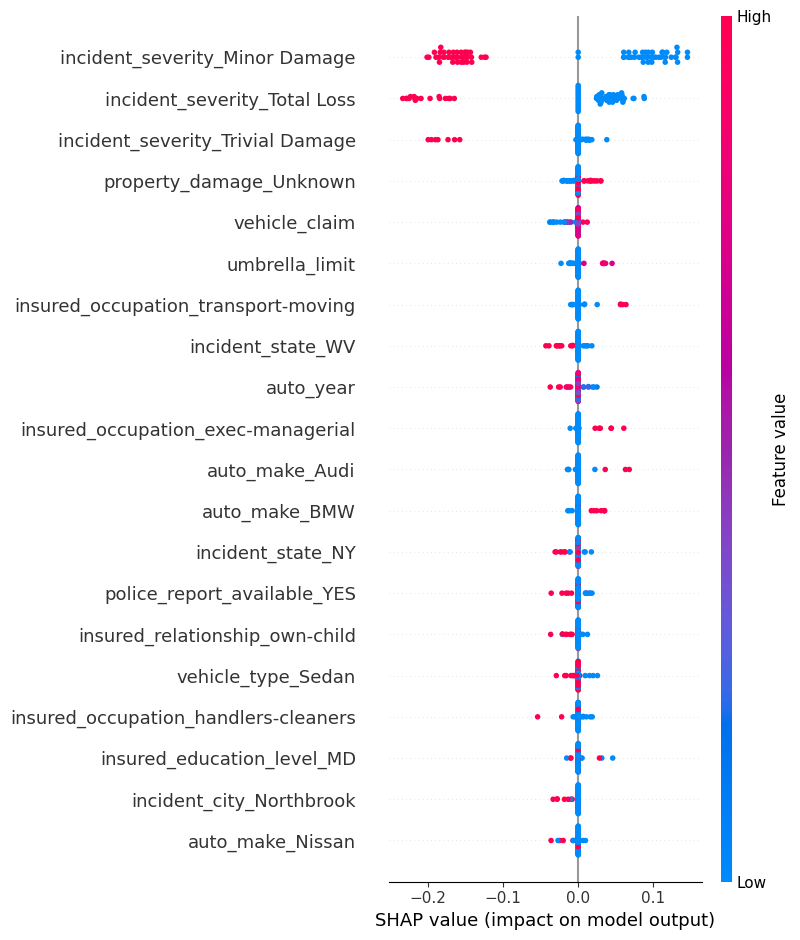

In [126]:
shap.summary_plot(
    shap_values_svc,
    X_test_svc_shap,
    feature_names=X_test_svc_shap.columns,
    max_display=20
)

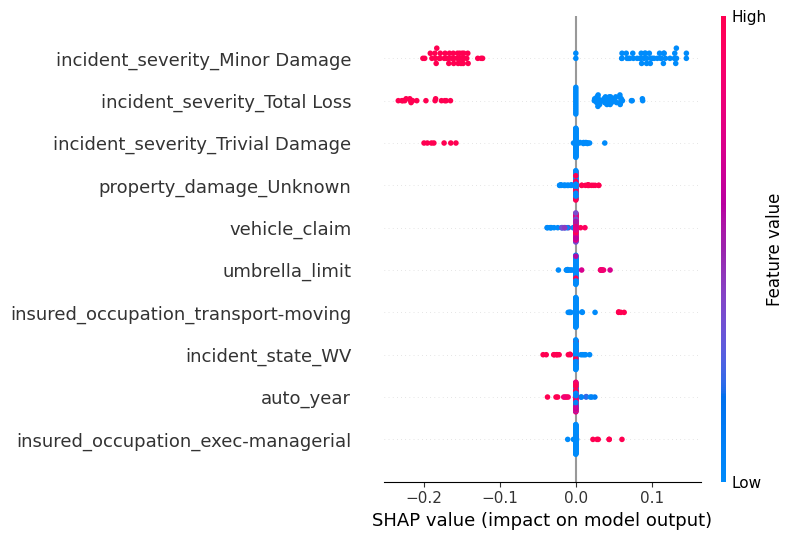

In [127]:
shap.summary_plot(
    shap_values_svc,
    X_test_svc_shap,
    feature_names=X_test_svc_shap.columns,
    max_display=10
)

**Interpretació SHAP Global SVC**

Els gràfics globals de SHAP per a l’SVC mostren que les variables més influents són principalment les relacionades amb la severitat de l’incident. En particular, `incident_severity_Minor Damage`, `incident_severity_Total Loss` i `incident_severity_Trivial Damage` apareixen com les variables amb més impacte mitjà sobre la predicció.

El bar plot mostra que `incident_severity_Minor Damage` és la variable amb més importància global, seguida de `incident_severity_Total Loss`. La diferència respecte a la resta de variables és notable, cosa que indica que l’SVC basa una part important de la seva frontera de decisió en la severitat del sinistre.

El beeswarm plot permet veure també la direcció dels efectes. En general, valors alts de `incident_severity_Minor Damage` tendeixen a reduir la probabilitat de frau, mentre que valors baixos d’aquesta variable poden empènyer la predicció cap a frau. Això s’ha d’interpretar amb cura perquè les variables categòriques estan codificades amb one-hot encoding: un valor 0 en una categoria implica que el cas pertany a una altra categoria de severitat.

També apareixen variables com `vehicle_claim`, `incident_state_WV`, algunes marques de vehicle i ocupacions de l’assegurat, però amb una importància molt inferior. Això suggereix que, en comparació amb XGBoost, l’SVC concentra més la seva explicació global en poques variables de severitat.

Cal tenir en compte que aquestes explicacions s’han calculat amb `KernelExplainer` sobre una mostra reduïda del test per motius computacionals. Per tant, els resultats s’han d’interpretar com una aproximació del comportament del model, no com una explicació exacta sobre tot el conjunt de test.


**SHAP local**

Per analitzar el comportament local de l’SVC, s’han seleccionat quatre casos: un true positive, un true negative, un false positive i un false negative. Aquesta selecció permet entendre tant prediccions correctes com errors del model.

In [128]:
# Prediccions SVC sobre la mostra explicada
svc_sample_proba = best_svc.predict_proba(X_test_svc_shap)[:, 1]
svc_sample_pred = (svc_sample_proba >= best_threshold_svc).astype(int)
svc_sample_true = y_test.loc[X_test_svc_shap.index]

svc_sample_results = pd.DataFrame({
    "y_true": svc_sample_true.values,
    "y_proba": svc_sample_proba,
    "y_pred": svc_sample_pred
}, index=X_test_svc_shap.index)

svc_sample_results.head()

,y_true,y_proba,y_pred
799,0,0.174171,0
614,0,0.112030,0
821,0,0.098872,0
742,1,0.369081,1
997,0,0.201537,0


In [129]:
#Localitzar TP/TN/FP/FN
svc_tp_idx = svc_sample_results[
    (svc_sample_results["y_true"] == 1) &
    (svc_sample_results["y_pred"] == 1)
].index

svc_tn_idx = svc_sample_results[
    (svc_sample_results["y_true"] == 0) &
    (svc_sample_results["y_pred"] == 0)
].index

svc_fp_idx = svc_sample_results[
    (svc_sample_results["y_true"] == 0) &
    (svc_sample_results["y_pred"] == 1)
].index

svc_fn_idx = svc_sample_results[
    (svc_sample_results["y_true"] == 1) &
    (svc_sample_results["y_pred"] == 0)
].index

print("TP:", len(svc_tp_idx))
print("TN:", len(svc_tn_idx))
print("FP:", len(svc_fp_idx))
print("FN:", len(svc_fn_idx))

TP: 14
TN: 60
FP: 2
FN: 4


In [130]:
# Triar casos
case_indices_svc = {}

if len(svc_tp_idx) > 0:
    case_indices_svc["True Positive"] = svc_tp_idx[0]

if len(svc_tn_idx) > 0:
    case_indices_svc["True Negative"] = svc_tn_idx[0]

if len(svc_fp_idx) > 0:
    case_indices_svc["False Positive"] = svc_fp_idx[0]

if len(svc_fn_idx) > 0:
    case_indices_svc["False Negative"] = svc_fn_idx[0]

case_indices_svc

{'True Positive': 742,
 'True Negative': 799,
 'False Positive': 914,
 'False Negative': 558}

In [131]:
#Waterfall local per SVC
def plot_svc_waterfall(case_name, original_index):
    row_position = X_test_svc_shap.index.get_loc(original_index)

    explanation = shap.Explanation(
        values=shap_values_svc[row_position],
        base_values=explainer_svc.expected_value,
        data=X_test_svc_shap.loc[original_index].values,
        feature_names=X_test_svc_shap.columns
    )

    print(case_name)
    print("Index:", original_index)
    print("Classe real:", y_test.loc[original_index])
    print("Probabilitat de frau:", round(svc_sample_results.loc[original_index, "y_proba"], 3))
    print("Predicció final:", svc_sample_results.loc[original_index, "y_pred"])
    print("Threshold:", best_threshold_svc)

    shap.plots.waterfall(
        explanation,
        max_display=15
    )

True Positive
Index: 742
Classe real: 1
Probabilitat de frau: 0.369
Predicció final: 1
Threshold: 0.34


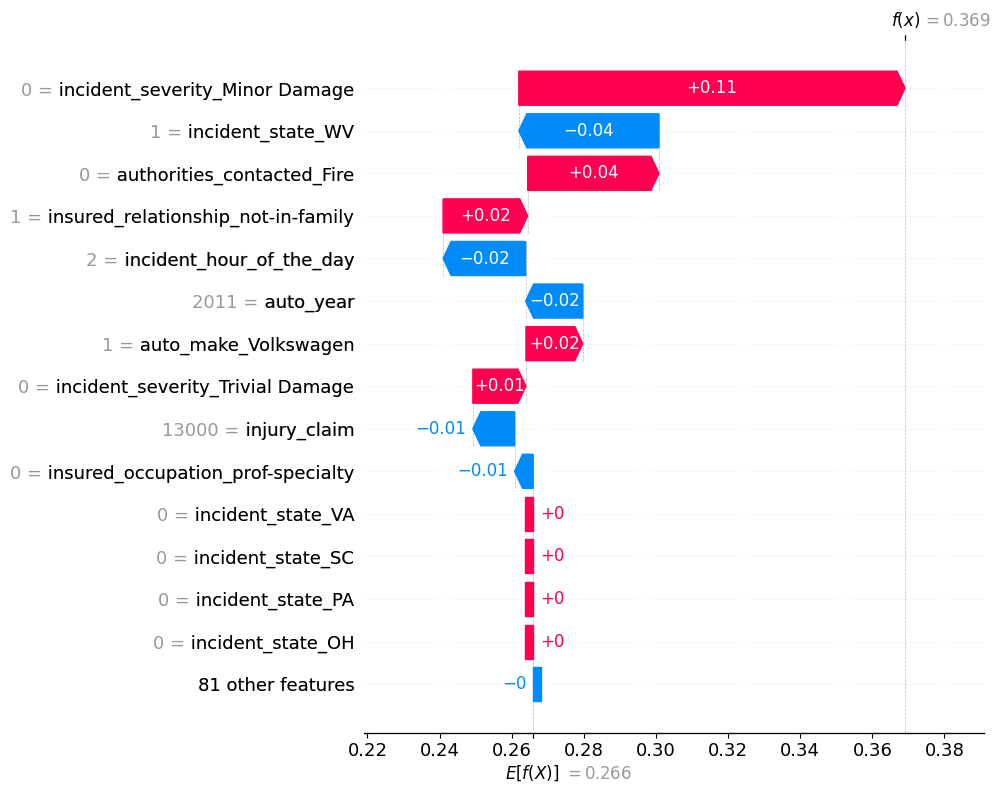

True Negative
Index: 799
Classe real: 0
Probabilitat de frau: 0.174
Predicció final: 0
Threshold: 0.34


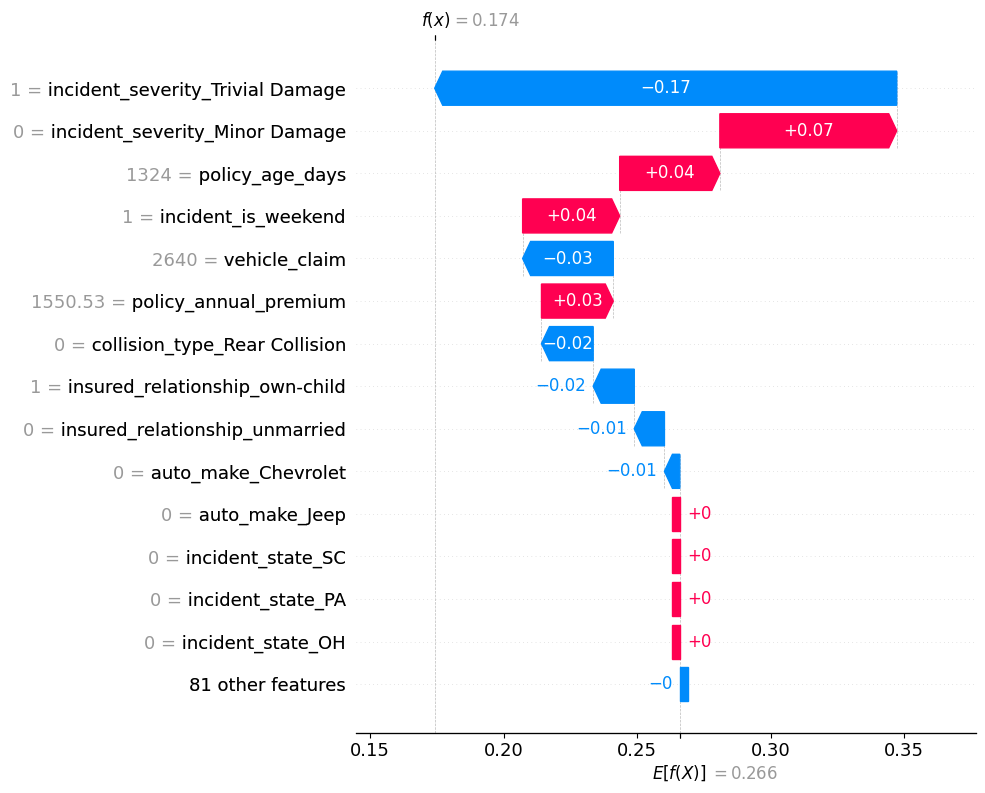

False Positive
Index: 914
Classe real: 0
Probabilitat de frau: 0.559
Predicció final: 1
Threshold: 0.34


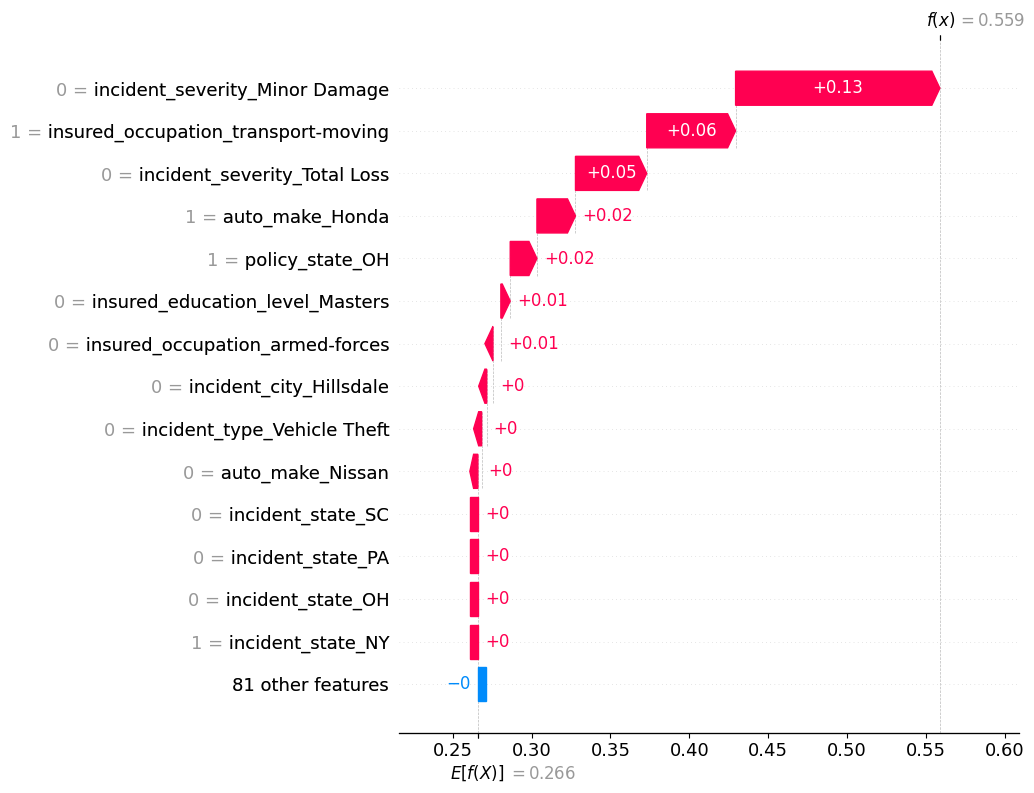

False Negative
Index: 558
Classe real: 1
Probabilitat de frau: 0.086
Predicció final: 0
Threshold: 0.34


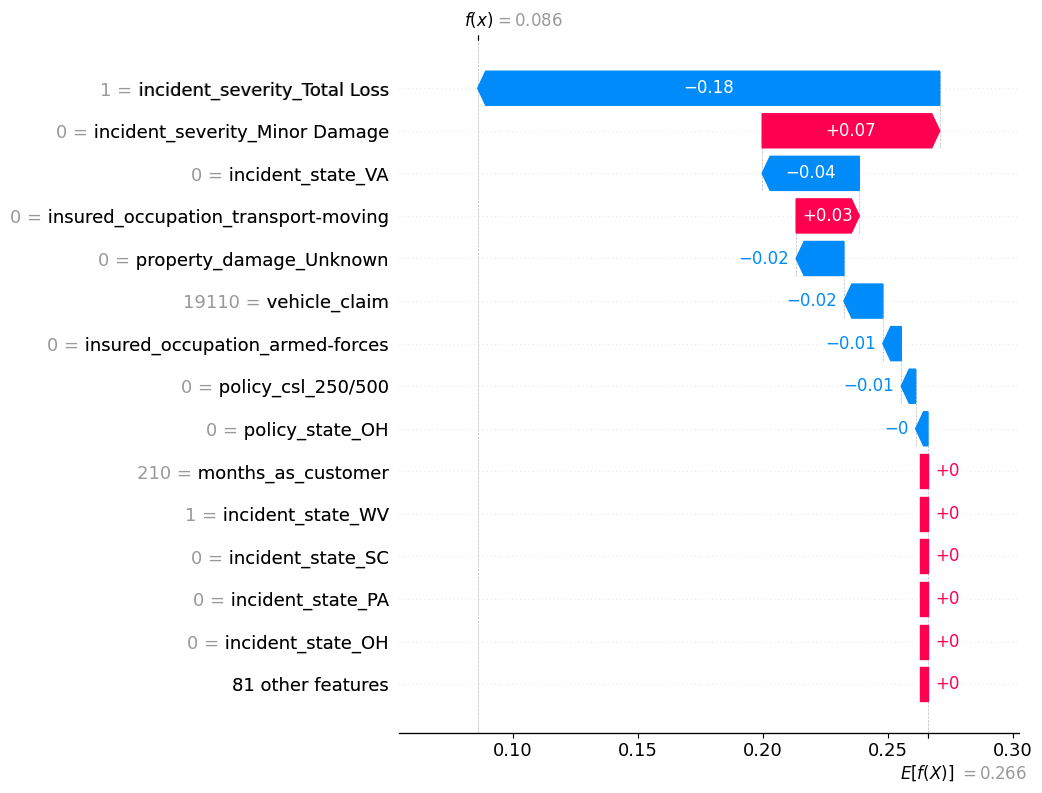

In [132]:
for case_name, case_idx in case_indices_svc.items():
    plot_svc_waterfall(case_name, case_idx)

**True Positive**

En el cas true positive, el model classifica correctament una reclamació fraudulenta amb una probabilitat de frau de 0.369, lleugerament per sobre del threshold final de 0.34. Les variables que més empenyen la predicció cap a frau són `incident_severity_Minor Damage = 0` i `incident_severity_Total Loss = 0`. Això indica que el cas no pertany a aquestes categories de severitat i que, segons el patró après pel model, aquesta combinació augmenta el risc estimat de frau.

També hi ha una contribució positiva de `vehicle_claim`, tot i que més petita. En canvi, variables com `incident_state_WV` i `police_report_available_YES` redueixen parcialment la probabilitat de frau. Tot i aquestes contribucions negatives, el model acaba superant el threshold i detecta correctament el cas fraudulent.

**True Negative**

En el true negative, el model classifica correctament una reclamació no fraudulenta amb una probabilitat de frau de 0.174. La variable que més redueix la predicció és `incident_severity_Trivial Damage = 1`, que empeny clarament el model cap a no frau. També contribueix negativament un valor baix de `vehicle_claim`, coherent amb una reclamació econòmicament menys sospitosa.

Algunes variables, com `incident_severity_Minor Damage = 0`, `auto_make_Audi = 1` o `incident_severity_Total Loss = 0`, empenyen lleugerament cap a frau, però no amb prou força per superar el threshold. Aquest cas mostra com l’SVC combina senyals oposats i acaba assignant una probabilitat baixa de frau.


**False Positive**

En el false positive, el model prediu frau amb una probabilitat de 0.559, però la classe real és no frau. Les principals variables que impulsen aquesta predicció incorrecta són `incident_severity_Minor Damage = 0`, `insured_occupation_transport-moving = 1`, `incident_severity_Total Loss = 0`, `auto_make_Honda = 1` i `property_damage_YES = 1`.

Aquest patró suggereix que el cas comparteix característiques que l’SVC associa amb reclamacions fraudulentes. Tot i que realment no era frau, la combinació de severitat, ocupació, danys materials i altres característiques fa que el model el consideri sospitós. Aquest tipus d’error és rellevant en un context assegurador perquè generaria una revisió manual innecessària.

**False Negative**

En el false negative, el model assigna una probabilitat de frau molt baixa, 0.086, tot i que la classe real és frau. La variable que més redueix la predicció és `incident_severity_Total Loss = 1`, amb una contribució negativa molt marcada. També redueixen la probabilitat variables com `insured_occupation_priv-house-serv = 0`, `insured_occupation_other-service = 0`, `vehicle_claim` i algunes variables relacionades amb el tipus d’incident.

Aquest cas mostra un error especialment important: el model interpreta el patró de `Total Loss` com a fortament associat amb no frau i això domina la decisió final. Encara que el cas era fraudulent, el model no detecta prou senyal positiu per superar el threshold. Aquesta explicació és coherent amb el que també s’havia observat en XGBoost, on `Total Loss` podia actuar com un senyal fort cap a no frau.

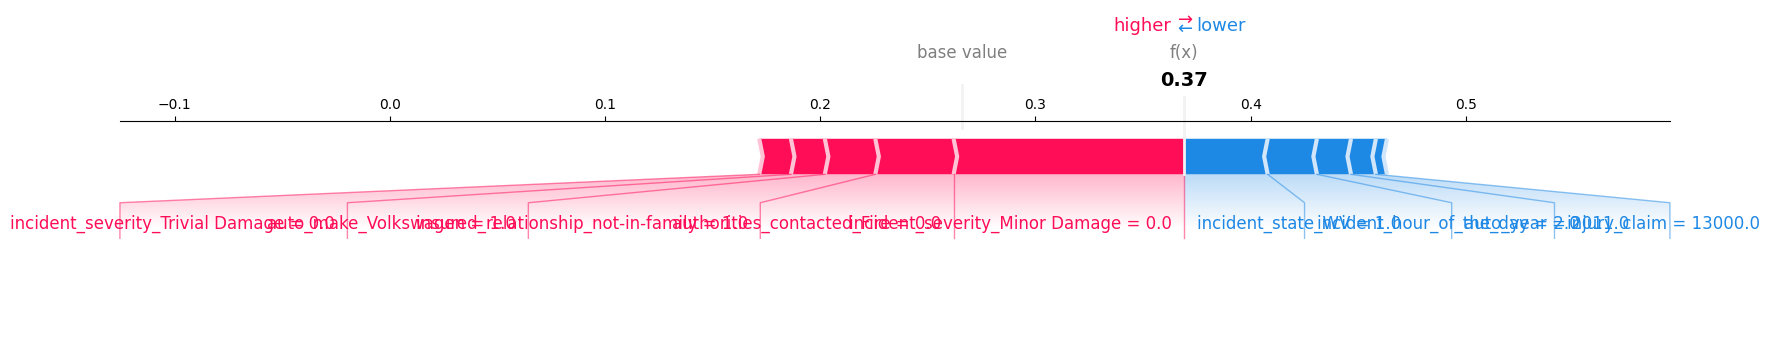

In [133]:
case_idx = case_indices_svc["True Positive"]
row_position = X_test_svc_shap.index.get_loc(case_idx)

explanation_svc = shap.Explanation(
    values=shap_values_svc[row_position],
    base_values=explainer_svc.expected_value,
    data=X_test_svc_shap.loc[case_idx].values,
    feature_names=X_test_svc_shap.columns
)

shap.force_plot(
    explanation_svc.base_values,
    explanation_svc.values,
    X_test_svc_shap.loc[case_idx],
    matplotlib=True
)

**Conclusió SHAP A SVC**

En conjunt, SHAP permet interpretar el comportament de l’SVC tot i tractar-se d’un model black-box amb kernel RBF. Les explicacions globals mostren que el model basa gran part de les seves decisions en variables relacionades amb la severitat de l’incident, especialment `incident_severity_Minor Damage`, `incident_severity_Total Loss` i `incident_severity_Trivial Damage`.

Les explicacions locals permeten entendre tant les prediccions correctes com els errors. En particular, els falsos negatius mostren que `incident_severity_Total Loss` pot actuar com un senyal fort cap a no frau, fent que alguns casos fraudulents no superin el threshold. En canvi, els falsos positius apareixen quan una reclamació no fraudulenta presenta una combinació de variables que el model associa amb risc de frau.

Així, SHAP aporta una interpretació útil del model SVC, però cal recordar que s’ha utilitzat `KernelExplainer` sobre una mostra reduïda per motius computacionals. Per tant, les conclusions s’han d’entendre com una aproximació local i global del comportament del model.

### 8.2.2. Anchors sobre SVC

Després d’aplicar SHAP, s’utilitza Anchors per obtenir explicacions locals en forma de regles interpretables. En el cas de l’SVC, aquesta tècnica és especialment útil perquè el model no ofereix una estructura directa d’interpretació, com sí passa amb un arbre de decisió.

Anchors permet identificar condicions que, quan es compleixen, fan que l’SVC mantingui la mateixa predicció amb una alta probabilitat. Igual que en l’anàlisi anterior, s’expliquen casos true positive, true negative, false positive i false negative per comparar encerts i errors del model.

Les explicacions generades amb Anchors adopten la forma de regles locals que descriuen condicions suficients perquè el model mantingui la seva predicció. A més de la regla en si mateixa, el mètode proporciona dues mesures especialment útils:

- `Precision`: probabilitat que la predicció del model es mantingui si es compleix l’anchor.
- `Coverage`: proporció d’observacions del conjunt de dades per a les quals aquesta regla és aplicable.

Aquesta informació permet valorar no només el contingut de l’explicació, sinó també la seva fiabilitat local i el seu abast dins del dataset.

In [134]:
from alibi.explainers import AnchorTabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [135]:
# Funció de predicció per Anchors utilitzant el threshold final de SVC

def predict_svc_anchor(x):
    x_df = pd.DataFrame(x, columns=X_train.columns)
    proba = best_svc.predict_proba(x_df)[:, 1]
    return (proba >= best_threshold_svc).astype(int)

In [136]:
# Crear explainer
feature_names = X_train.columns.tolist()

explainer_anchor_svc = AnchorTabular(
    predictor=predict_svc_anchor,
    feature_names=feature_names
)

explainer_anchor_svc.fit(
    X_train.values,
    disc_perc=(25, 50, 75)
)

AnchorTabular(meta={
  'name': 'AnchorTabular',
  'type': ['blackbox'],
  'explanations': ['local'],
  'params': {'seed': None, 'disc_perc': (25, 50, 75)},
  'version': '0.9.6'}
)

In [137]:
# Funció per eplicar casos SVC
def explain_anchor_svc_case(case_name, original_index, threshold=0.95):
    row_position = X_test.index.get_loc(original_index)
    x_instance = X_test.loc[original_index].values

    explanation = explainer_anchor_svc.explain(
        x_instance,
        threshold=threshold
    )

    proba_case = best_svc.predict_proba(X_test.loc[[original_index]])[:, 1][0]
    pred_case = int(proba_case >= best_threshold_svc)

    print("=" * 80)
    print(case_name)
    print("Index:", original_index)
    print("Classe real:", y_test.loc[original_index])
    print("Probabilitat de frau:", round(proba_case, 3))
    print("Predicció final:", pred_case)
    print("Threshold model:", best_threshold_svc)

    print("\nRegla Anchor:")
    print(" AND ".join(explanation.anchor))

    print("\nPrecision de la regla:", round(explanation.precision, 3))
    print("Coverage de la regla:", round(explanation.coverage, 3))

    return explanation

In [138]:
anchor_explanations_svc = {}

for case_name, case_idx in case_indices_svc.items():
    anchor_explanations_svc[case_name] = explain_anchor_svc_case(
        case_name,
        case_idx,
        threshold=0.95
    )

True Positive
Index: 742
Classe real: 1
Probabilitat de frau: 0.369
Predicció final: 1
Threshold model: 0.34

Regla Anchor:
incident_severity_Minor Damage <= 0.00 AND incident_severity_Total Loss <= 0.00 AND injury_claim > 11445.00

Precision de la regla: 1.0
Coverage de la regla: 0.088
True Negative
Index: 799
Classe real: 0
Probabilitat de frau: 0.174
Predicció final: 0
Threshold model: 0.34

Regla Anchor:
incident_severity_Trivial Damage > 0.00

Precision de la regla: 1.0
Coverage de la regla: 0.088
False Positive
Index: 914
Classe real: 0
Probabilitat de frau: 0.559
Predicció final: 1
Threshold model: 0.34

Regla Anchor:
incident_severity_Minor Damage <= 0.00 AND incident_severity_Total Loss <= 0.00 AND injury_claim > 11445.00

Precision de la regla: 1.0
Coverage de la regla: 0.084
False Negative
Index: 558
Classe real: 1
Probabilitat de frau: 0.086
Predicció final: 0
Threshold model: 0.34

Regla Anchor:
incident_severity_Total Loss > 0.00

Precision de la regla: 1.0
Coverage de la

**Taula resum**

In [139]:
anchor_summary_svc = []

for case_name, explanation in anchor_explanations_svc.items():
    case_idx = case_indices_svc[case_name]

    proba_case = best_svc.predict_proba(X_test.loc[[case_idx]])[:, 1][0]
    pred_case = int(proba_case >= best_threshold_svc)

    anchor_summary_svc.append({
        "Case": case_name,
        "Index": case_idx,
        "True class": y_test.loc[case_idx],
        "Predicted class": pred_case,
        "Fraud probability": proba_case,
        "Anchor rule": " AND ".join(explanation.anchor),
        "Anchor precision": explanation.precision,
        "Anchor coverage": explanation.coverage
    })

anchor_summary_svc = pd.DataFrame(anchor_summary_svc)

anchor_summary_svc.round(3)

,Case,Index,True class,Predicted class,Fraud probability,Anchor rule,Anchor precision,Anchor coverage
0,True Positive,742,1,1,0.369,incident_severity_Minor Damage <= 0.00 AND inc...,1.0,0.088
1,True Negative,799,0,0,0.174,incident_severity_Trivial Damage > 0.00,1.0,0.088
2,False Positive,914,0,1,0.559,incident_severity_Minor Damage <= 0.00 AND inc...,1.0,0.084
3,False Negative,558,1,0,0.086,incident_severity_Total Loss > 0.00,1.0,0.283


Les regles Anchor obtingudes per l’SVC mostren un patró molt coherent amb els resultats observats amb SHAP. Les variables relacionades amb `incident_severity` tornen a aparèixer com a elements centrals en les decisions del model, especialment `Minor Damage`, `Total Loss` i `Trivial Damage`.

En el true positive, el model classifica correctament un cas fraudulent amb una probabilitat de frau de 0.369, lleugerament superior al threshold de 0.34. La regla Anchor indica que, quan el cas no és `Minor Damage`, no és `Total Loss` i `injury_claim` és superior a 11445, l’SVC manté la predicció de frau amb precision 1.0. La coverage és baixa, de 0.086, fet que indica que es tracta d’una regla molt fiable però aplicable a una part reduïda del dataset.

En el true negative, la regla és molt simple: `incident_severity_Trivial Damage > 0`. Aquesta condició és suficient perquè el model mantingui la predicció de no frau amb precision 0.995. Això indica que, per l’SVC, els casos amb dany trivial són fortament associats amb absència de frau.

El false positive és especialment informatiu perquè rep exactament la mateixa regla que el true positive: no és `Minor Damage`, no és `Total Loss` i `injury_claim` és superior a 11445. Això explica per què el model s’equivoca: el cas no fraudulent comparteix una combinació de condicions que l’SVC associa de manera molt consistent amb frau.

Finalment, el false negative queda explicat per una regla molt simple: `incident_severity_Total Loss > 0`. Aquesta regla té precision 1.0 i coverage 0.280, la cobertura més alta dels quatre casos. Això mostra que `Total Loss` és un patró ampli i molt fort cap a no frau per l’SVC. En aquest cas, aquest senyal domina la decisió i fa que el model no detecti una reclamació que realment era fraudulenta.

**Gràfic Precision i Coverage**

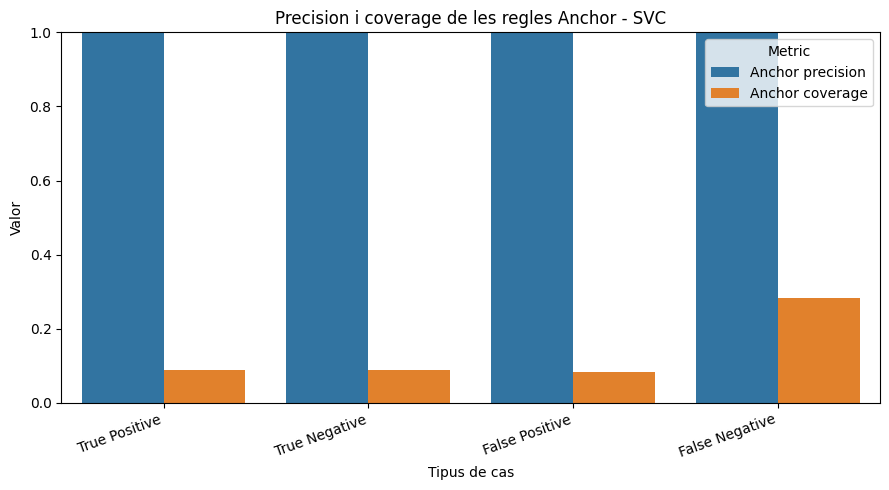

In [140]:
anchor_metrics_svc = anchor_summary_svc[[
    "Case",
    "Anchor precision",
    "Anchor coverage"
]].melt(
    id_vars="Case",
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=anchor_metrics_svc,
    x="Case",
    y="Value",
    hue="Metric"
)

plt.title("Precision i coverage de les regles Anchor - SVC")
plt.ylabel("Valor")
plt.xlabel("Tipus de cas")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

El gràfic de precision i coverage mostra que totes les regles Anchor tenen una precision molt elevada, propera o igual a 1. Això indica que les regles són molt fiables per explicar localment les decisions de l’SVC. No obstant això, la coverage varia entre casos.

Les regles del true positive, true negative i false positive tenen coverage baixa, al voltant de 0.086-0.088, fet que indica que són explicacions força específiques. En canvi, la regla del false negative té una coverage de 0.280, molt més elevada. Això reforça la idea que `incident_severity_Total Loss` és una condició més general dins del comportament del model i que pot portar l’SVC a predir no frau en un conjunt més ampli d’observacions.

**Regles en format visual**

In [141]:
def print_anchor_rule_tree_svc(case_name, explanation):
    print(case_name)
    print("Prediccio mantinguda si:")

    for i, condition in enumerate(explanation.anchor, 1):
        prefix = "+--" if i < len(explanation.anchor) else "`--"
        print(f"{prefix} {condition}")

    print(f"Precisio: {explanation.precision:.3f}")
    print(f"Cobertura: {explanation.coverage:.3f}")

In [142]:
for case_name, explanation in anchor_explanations_svc.items():
    print_anchor_rule_tree_svc(case_name, explanation)
    print()

True Positive
Prediccio mantinguda si:
+-- incident_severity_Minor Damage <= 0.00
+-- incident_severity_Total Loss <= 0.00
`-- injury_claim > 11445.00
Precisio: 1.000
Cobertura: 0.088

True Negative
Prediccio mantinguda si:
`-- incident_severity_Trivial Damage > 0.00
Precisio: 1.000
Cobertura: 0.088

False Positive
Prediccio mantinguda si:
+-- incident_severity_Minor Damage <= 0.00
+-- incident_severity_Total Loss <= 0.00
`-- injury_claim > 11445.00
Precisio: 1.000
Cobertura: 0.084

False Negative
Prediccio mantinguda si:
`-- incident_severity_Total Loss > 0.00
Precisio: 1.000
Cobertura: 0.283



In [143]:
import pandas as pd

# Funció per convertir regles a format llegible
def clean_anchor_rule_svc(anchor_list):

    cleaned_parts = []

    for r in anchor_list:

        if r == "incident_severity_Minor Damage <= 0.00":
            cleaned_parts.append("No Minor Damage")

        elif r == "incident_severity_Total Loss <= 0.00":
            cleaned_parts.append("No Total Loss")

        elif r == "incident_severity_Total Loss > 0.00":
            cleaned_parts.append("Total Loss")

        elif r == "incident_severity_Trivial Damage > 0.00":
            cleaned_parts.append("Trivial Damage")

        elif "injury_claim >" in r:
            cleaned_parts.append("High injury claim")

        else:
            cleaned_parts.append(r)

    return " + ".join(cleaned_parts)


# Crear resum net
anchor_summary_svc_clean = []

for case_name, explanation in anchor_explanations_svc.items():

    anchor_summary_svc_clean.append({
        "Case": case_name,
        "Anchor rule": clean_anchor_rule_svc(explanation.anchor),
        "Precision": round(explanation.precision, 3),
        "Coverage": round(explanation.coverage, 3)
    })

anchor_summary_svc_clean = pd.DataFrame(anchor_summary_svc_clean)

anchor_summary_svc_clean

,Case,Anchor rule,Precision,Coverage
0,True Positive,No Minor Damage + No Total Loss + High injury ...,1.0,0.088
1,True Negative,Trivial Damage,1.0,0.088
2,False Positive,No Minor Damage + No Total Loss + High injury ...,1.0,0.084
3,False Negative,Total Loss,1.0,0.283


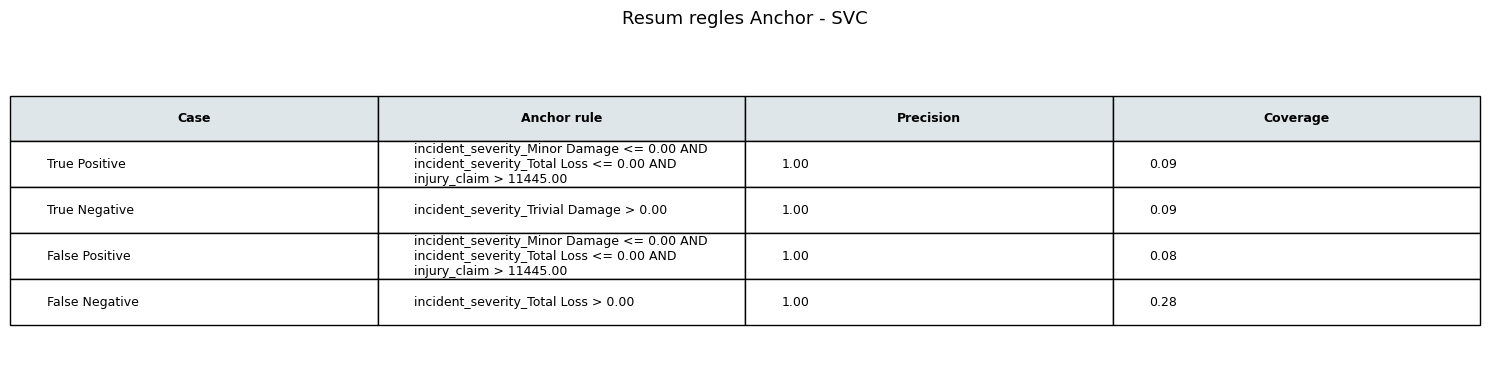

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# Crear resum
anchor_summary_svc = []

for case_name, explanation in anchor_explanations_svc.items():

    # Salt de línia automàtic perquè càpiga millor
    wrapped_rule = "\n".join(
        textwrap.wrap(" AND ".join(explanation.anchor), width=45)
    )

    anchor_summary_svc.append({
        "Case": case_name,
        "Anchor rule": wrapped_rule,
        "Precision": f"{explanation.precision:.2f}",
        "Coverage": f"{explanation.coverage:.2f}"
    })

anchor_summary_svc = pd.DataFrame(anchor_summary_svc)

# Crear figura més gran
fig, ax = plt.subplots(figsize=(15, 4))
ax.axis('off')

# Crear taula
table = ax.table(
    cellText=anchor_summary_svc.values,
    colLabels=anchor_summary_svc.columns,
    cellLoc='left',
    loc='center'
)

# Estil
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

# Capçalera
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#dfe6e9')

plt.title("Resum regles Anchor - SVC", fontsize=13, pad=12)

plt.tight_layout()
plt.show()

**Conclusions Anchors a SVC**

En conjunt, Anchors permet transformar les decisions de l’SVC en regles locals fàcils d’interpretar. Les regles obtingudes confirmen que el model es basa principalment en variables de severitat de l’incident i, en alguns casos, en imports de reclamació com `injury_claim`.

Les explicacions són especialment útils per entendre els errors. El false positive es produeix perquè el cas compleix la mateixa regla que un true positive, és a dir, comparteix condicions que el model associa fortament amb frau. El false negative, en canvi, es produeix perquè `Total Loss` actua com una condició molt forta cap a no frau.

Això mostra que Anchors és una eina útil per explicar decisions locals de l’SVC, especialment quan es vol comunicar la predicció en forma de regla comprensible.

### 8.2.3. Comparació entre SHAP i Anchors en SVC

SHAP i Anchors ofereixen explicacions complementàries del comportament de l’SVC. SHAP permet observar la contribució gradual de cada variable sobre la probabilitat estimada de frau, mentre que Anchors resumeix la predicció mitjançant una regla local.

En el cas de l’SVC, ambdues tècniques coincideixen en assenyalar la severitat de l’incident com el factor més rellevant. SHAP mostra que variables com `incident_severity_Minor Damage`, `incident_severity_Total Loss` i `incident_severity_Trivial Damage` tenen un impacte important sobre la predicció. Anchors confirma aquesta lectura, ja que les regles locals es construeixen principalment a partir d’aquestes mateixes variables.

La diferència principal és el nivell de detall. SHAP és més informatiu per veure com diverses variables contribueixen simultàniament a una predicció. Anchors, en canvi, és més fàcil de comunicar perquè produeix regles concretes. Per exemple, en el false negative, SHAP mostra que `Total Loss` redueix fortament la probabilitat de frau, mentre que Anchors resumeix aquest comportament amb una regla directa: `incident_severity_Total Loss > 0`.

Per tant, SHAP és més útil per analitzar el comportament del model, mentre que Anchors és més útil per justificar una decisió concreta en forma de regla.

### 8.2.4. Estabilitat de les explicacions en SVC

Les explicacions de l’SVC mostren una coherència elevada entre les diferents tècniques XAI. Tant SHAP com Anchors identifiquen les variables de `incident_severity` com els principals factors que influeixen en les prediccions del model. Aquesta coincidència suggereix que les explicacions són estables i que el model no basa les seves decisions en patrons aleatoris o difícils de justificar.

També s’observa estabilitat en l’anàlisi dels errors. Els falsos positius apareixen quan casos no fraudulents compleixen condicions semblants a les dels casos fraudulents, mentre que els falsos negatius apareixen quan `Total Loss` domina la predicció cap a no frau.

Tot i això, cal tenir en compte que SHAP s’ha calculat sobre una mostra reduïda amb `KernelExplainer`, per motius computacionals. Per tant, l’estabilitat observada s’ha d’interpretar com una evidència qualitativa i no com una validació exhaustiva sobre tot l’espai de dades.

### 8.2.5. Conclusió XAI a SVC

L’anàlisi XAI aplicada a l’SVC permet entendre millor el comportament del model amb millor rendiment final. Tot i ser un model black-box basat en un kernel no lineal, les explicacions mostren patrons coherents i interpretables.

SHAP revela que la severitat de l’incident és el conjunt de variables més influent en la probabilitat estimada de frau. Anchors confirma aquest resultat generant regles locals basades sobretot en `incident_severity` i, en alguns casos, en imports de reclamació. Aquesta coherència reforça la confiança en les explicacions obtingudes.

A més, les tècniques XAI permeten entendre els errors del model. Els falsos positius apareixen quan un cas no fraudulent comparteix patrons associats al frau, mentre que els falsos negatius apareixen quan variables com `Total Loss` empenyen fortament la decisió cap a no frau.

En conjunt, SHAP i Anchors fan que l’SVC sigui més transparent i interpretable, compensant parcialment la seva naturalesa black-box. Això és especialment rellevant perquè l’SVC és el model amb millor rendiment pràctic en la comparació final.

## 8.3. Comparació global de les tècniques XAI

Després d’aplicar SHAP i Anchors als dos models black-box principals, XGBoost i SVC, es comparen els resultats obtinguts per valorar quines explicacions són més útils en cada cas. Aquesta comparació permet analitzar no només quines variables apareixen com a més rellevants, sinó també quin tipus d’explicació és més adequada segons l’objectiu: entendre el comportament global del model o justificar una predicció concreta.

### 8.3.1 Taula Comparativa XAI


In [145]:
xai_comparison = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Patrons SHAP globals": "Severitat de l'incident i imports de reclamació",
        "Patrons Anchors": "Regles basades en severitat i llindars d'import",
        "Evidència": "SHAP destaca incident_severity, vehicle_claim i imports; Anchors utilitza regles de severitat + import en casos TP/FP",
        "Conclusió principal": "Els falsos positius apareixen quan casos no fraudulents s'assemblen a patrons de reclamació d'alt risc"
    },
    {
        "Model": "SVC RBF",
        "Patrons SHAP globals": "Principalment variables de severitat",
        "Patrons Anchors": "Regles fortament basades en severitat",
        "Evidència": "Els SHAP globals estan dominats per incident_severity; Anchors utilitza Trivial Damage i Total Loss com a regles compactes",
        "Conclusió principal": "Total Loss empeny sovint la predicció cap a no frau i ajuda a explicar alguns falsos negatius"
    }
])

xai_comparison

,Model,Patrons SHAP globals,Patrons Anchors,Evidència,Conclusió principal
0,XGBoost,Severitat de l'incident i imports de reclamació,Regles basades en severitat i llindars d'import,"SHAP destaca incident_severity, vehicle_claim ...",Els falsos positius apareixen quan casos no fr...
1,SVC RBF,Principalment variables de severitat,Regles fortament basades en severitat,Els SHAP globals estan dominats per incident_s...,Total Loss empeny sovint la predicció cap a no...


In [146]:
from IPython.display import display, HTML

pd.set_option("display.max_colwidth", None)

display(
    xai_comparison.style
    .set_properties(**{
        "white-space": "pre-wrap",
        "text-align": "left",
        "vertical-align": "top"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]}
    ])
)

,Model,Patrons SHAP globals,Patrons Anchors,Evidència,Conclusió principal
0,XGBoost,Severitat de l'incident i imports de reclamació,Regles basades en severitat i llindars d'import,"SHAP destaca incident_severity, vehicle_claim i imports; Anchors utilitza regles de severitat + import en casos TP/FP",Els falsos positius apareixen quan casos no fraudulents s'assemblen a patrons de reclamació d'alt risc
1,SVC RBF,Principalment variables de severitat,Regles fortament basades en severitat,Els SHAP globals estan dominats per incident_severity; Anchors utilitza Trivial Damage i Total Loss com a regles compactes,Total Loss empeny sovint la predicció cap a no frau i ajuda a explicar alguns falsos negatius


La taula mostra que tots dos models utilitzen patrons relacionats amb la severitat de l’incident, però amb matisos diferents. XGBoost reparteix més la seva explicació entre severitat, imports de reclamació i variables contextuals. En canvi, l’SVC concentra més el pes explicatiu en les variables de severitat.

### 8.3.2. Comparació Visual De Tècniques

La taula següent és una valoració qualitativa de les tècniques XAI aplicades. No representa una mètrica calculada automàticament, sinó una rúbrica interpretativa basada en els resultats observats durant l’anàlisi.

Cada criteri es valora de 1 a 5, on 1 indica una utilitat baixa i 5 una utilitat alta:

- `Global explanation`: capacitat del mètode per explicar el comportament general del model.
- `Local explanation`: capacitat per explicar prediccions individuals.
- `Ease of communication`: facilitat per comunicar l’explicació a una persona no tècnica.
- `Computational efficiency`: facilitat i rapidesa de càlcul en aquest cas concret.

In [147]:
xai_scores = pd.DataFrame([
    {
        "Mètode": "SHAP",
        "Model": "XGBoost",
        "Explicació global": 5,
        "Explicació local": 5,
        "Facilitat comunicació": 3,
        "Eficiència computacional": 5
    },
    {
        "Mètode": "Anchors",
        "Model": "XGBoost",
        "Explicació global": 2,
        "Explicació local": 4,
        "Facilitat comunicació": 5,
        "Eficiència computacional": 4
    },
    {
        "Mètode": "SHAP",
        "Model": "SVC RBF",
        "Explicació global": 4,
        "Explicació local": 4,
        "Facilitat comunicació": 3,
        "Eficiència computacional": 2
    },
    {
        "Mètode": "Anchors",
        "Model": "SVC RBF",
        "Explicació global": 2,
        "Explicació local": 4,
        "Facilitat comunicació": 5,
        "Eficiència computacional": 4
    }
])

xai_scores

,Mètode,Model,Explicació global,Explicació local,Facilitat comunicació,Eficiència computacional
0,SHAP,XGBoost,5,5,3,5
1,Anchors,XGBoost,2,4,5,4
2,SHAP,SVC RBF,4,4,3,2
3,Anchors,SVC RBF,2,4,5,4


SHAP rep una puntuació alta en explicació global perquè permet generar gràfics com beeswarm, bar plot i heatmap, que resumeixen el comportament general del model. En XGBoost, SHAP també és molt eficient computacionalment gràcies a l’existència d’explainers específics per models basats en arbres.

En SVC, SHAP continua sent útil, però és menys eficient perquè s’ha d’utilitzar `KernelExplainer`, que és model-agnostic i més costós. Per això la seva eficiència computacional és menor.

Anchors rep una puntuació baixa en explicació global perquè no descriu el comportament general del model, sinó casos concrets. En canvi, obté una puntuació alta en facilitat de comunicació, ja que produeix regles locals simples del tipus “si es compleixen aquestes condicions, el model manté la predicció”.

**Heatmap**

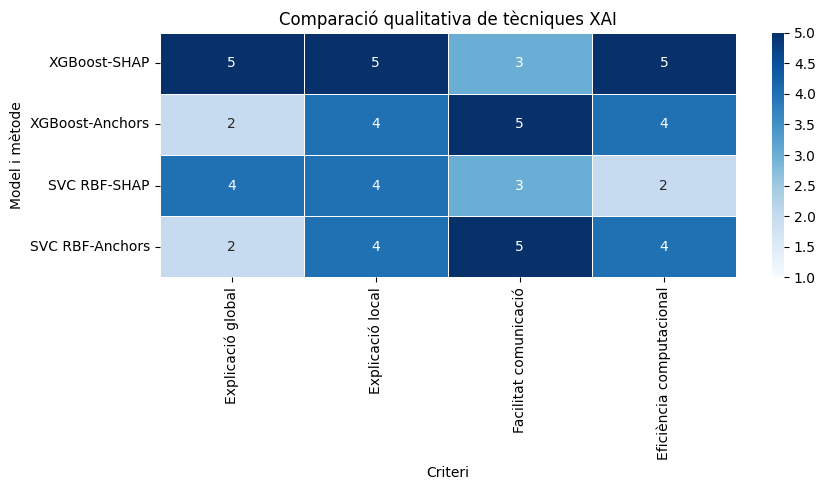

In [148]:
xai_scores_heatmap = xai_scores.set_index(["Model", "Mètode"])

plt.figure(figsize=(9, 5))
sns.heatmap(
    xai_scores_heatmap,
    annot=True,
    cmap="Blues",
    vmin=1,
    vmax=5,
    linewidths=0.5
)

plt.title("Comparació qualitativa de tècniques XAI")
plt.xlabel("Criteri")
plt.ylabel("Model i mètode")
plt.tight_layout()
plt.show()

El heatmap resumeix qualitativament la utilitat de cada tècnica XAI segons diferents criteris. SHAP és especialment fort per obtenir explicacions globals i locals detallades, sobretot en XGBoost, on el càlcul és eficient gràcies a l’estructura basada en arbres. En canvi, en SVC, SHAP requereix `KernelExplainer`, que és més costós computacionalment.

Anchors no proporciona una explicació global completa del model, però destaca per la seva facilitat de comunicació. Les regles locals són simples i poden ser útils per explicar una decisió concreta a un analista o responsable de negoci.

### 8.3.3 Variables Més Estables Entre Models

La següent taula és una valoració qualitativa basada en l’experiència d’aplicació de cada tècnica durant l’anàlisi.

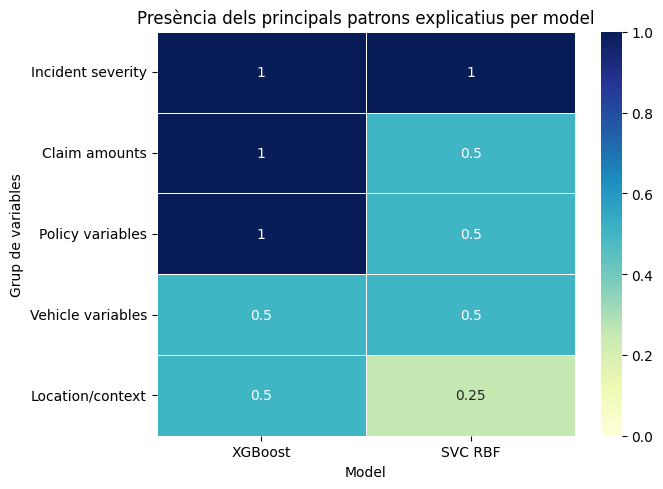

In [149]:
xai_patterns = pd.DataFrame([
    {"Variable group": "Incident severity", "XGBoost": 1, "SVC RBF": 1},
    {"Variable group": "Claim amounts", "XGBoost": 1, "SVC RBF": 0.5},
    {"Variable group": "Policy variables", "XGBoost": 1, "SVC RBF": 0.5},
    {"Variable group": "Vehicle variables", "XGBoost": 0.5, "SVC RBF": 0.5},
    {"Variable group": "Location/context", "XGBoost": 0.5, "SVC RBF": 0.25}
])

xai_patterns_plot = xai_patterns.set_index("Variable group")

plt.figure(figsize=(7, 5))
sns.heatmap(
    xai_patterns_plot,
    annot=True,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Presència dels principals patrons explicatius per model")
plt.xlabel("Model")
plt.ylabel("Grup de variables")
plt.tight_layout()
plt.show()

La comparació dels principals patrons explicatius mostra que `incident_severity` és el grup de variables més estable entre models i tècniques. Aquest resultat és coherent amb l’EDA i amb la importància observada en els models baseline.

Els imports de reclamació apareixen de manera més clara en XGBoost, especialment en les explicacions locals i en les regles Anchor. En l’SVC també poden aparèixer, però amb menys pes global que les variables de severitat. Això suggereix que XGBoost construeix decisions més repartides entre diferents dimensions del sinistre, mentre que l’SVC depèn més fortament de la severitat.

### 8.3.4. Conclusions generals de l’anàlisi XAI

L’anàlisi XAI confirma que els dos models black-box principals, XGBoost i SVC, basen les seves prediccions en patrons coherents amb el problema de detecció de frau. Les variables relacionades amb la severitat de l’incident apareixen de manera recurrent en tots dos models, tant en SHAP com en Anchors. També destaquen els imports de reclamació, especialment en XGBoost.

SHAP resulta més útil per entendre el comportament global dels models i analitzar com cada variable contribueix a les prediccions. En XGBoost, aquesta tècnica és especialment adequada perquè permet obtenir explicacions eficients i detallades. En SVC, SHAP també és útil, però el seu cost computacional és més elevat perquè cal utilitzar un explainer model-agnostic.

Anchors, en canvi, és especialment útil per comunicar decisions concretes. Les regles locals permeten explicar per què el model manté una predicció de frau o no frau sota determinades condicions. Aquesta forma d’explicació és més senzilla d’interpretar per un usuari no tècnic, tot i que té un abast local i no substitueix una explicació global del model.

Els errors dels models també són interpretables amb XAI. Els falsos positius solen aparèixer quan una reclamació no fraudulenta comparteix característiques amb casos d’alt risc, mentre que els falsos negatius poden aparèixer quan variables com `incident_severity_Total Loss` empenyen fortament la predicció cap a no frau.

En conjunt, SHAP i Anchors permeten compensar parcialment la manca d’interpretabilitat dels models black-box. Això reforça la justificació central del treball: els models més complexos poden oferir millor rendiment operatiu en detecció de frau, i les tècniques XAI permeten fer-ne les prediccions més transparents, auditables i útils per a la presa de decisions.